In [1]:
import torch

#Import models
from models.TimesNet import Model as TimesNet
from models.Nonstationary_Transformer import Model as NST
from models.Informer import Model as Informer
from models.Autoformer import Model as Autoformer
from models.FEDformer import Model as FEDformer
from models.TimeMixer import Model as Timemixer

from tqdm import tqdm, trange

from torch.utils.data import DataLoader,TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F

# compute weight-class
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
import time
import traceback
import subprocess
import re

In [2]:
# GPU handling
print(torch.__version__)
print(torch.version.cuda)
torch.cuda.is_available()
# Seeing that the GPU hase enough memory to run
print(torch.cuda.empty_cache())  # Frees unused memory
print(torch.cuda.memory_summary(device=None, abbreviated=False))  # Shows memory usage
print(torch.cuda.ipc_collect())

2.5.1
11.8
None
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B 

In [3]:
def get_least_used_gpu():
    """Find the GPU with the most available memory using nvidia-smi."""
    try:
        # Run nvidia-smi and get memory info
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.free", "--format=csv,nounits,noheader"],
            stdout=subprocess.PIPE,
            text=True,
            check=True
        )
        
        # Parse output into a list of free memory values
        free_memory = [int(x) for x in result.stdout.strip().split("\n")]
        print(free_memory)
        
        # Find GPU with max free memory
        best_gpu = free_memory.index(max(free_memory))
        return best_gpu

    except Exception as e:
        print(f"Error getting GPU memory info: {e}")
        return 0  # Default to GPU 0 if there's an issue

# Get the best GPU with the most free memory
best_gpu = get_least_used_gpu()

# Set it for PyTorch
torch.cuda.set_device(best_gpu)
print(f"Using GPU: {torch.cuda.current_device()} (GPU {best_gpu})")

[787, 15542, 19544]
Using GPU: 2 (GPU 2)


In [4]:
class TimeSeriesConfig:
    def __init__(self,
                 model_type='nst',
                 num_class=5,
                 seq_len=101,
                 num_features=1,
                 classes_names=['Youtube','semrush','discord']
                ):
        # Common configurations for all models
        self.task_name = 'classification'
        self.seq_len = seq_len  # Your sequence length
        self.pred_len = 0   # Not used in classification
        self.label_len = 0  # Not used in classification
        
        # Input/Output dimensions
        self.enc_in = num_features      # Number of input features
        self.dec_in = 1      # Not used in classification
        self.c_out = 1       # Not used in classification
        self.num_class = num_class   # Number of classes
        
        # Training parameters
        self.dropout = 0.1
        self.embed = 'timeF'
        self.freq = 'h'
        self.batch_size = 128 #32#64 #512
        self.learning_rate = 1e-4 #1e-3
        self.num_epochs = 150 #5
        self.criterion_type = 'CrossEntropyLoss' # 'CrossEntropyLoss','FocalLoss'
        self.optimizer_type = 'Adam' #'SGD','AdamW' ,'Adam'
        
        # Other configs
        self.use_gpu = True if torch.cuda.is_available() else False
        self.checkpoint_dir = f'checkpoints/UTMobile' # packets feature'
        self.classes_names = classes_names
        
        self.model_name = f'{model_type.lower()}_classifier'

        # Model specific configurations
        if model_type.lower() == 'nst':
            self._set_nst_config()
        elif model_type.lower() == 'timesnet':
            self._set_timesnet_config()
        elif model_type.lower() == 'informer':
            self._set_informer_config()
        elif model_type.lower() == 'autoformer':
            self._set_autoformer_confing()
        elif model_type.lower() == 'fedformer':
            self._set_fedformer_confing()
        elif model_type.lower() == 'timemixer':
            self._set_timemixer_config()
        else:
            raise ValueError(f"Unknown model type: {model_type}")
            
        
    def _set_autoformer_confing(self):
        """Autoformer specific configurations"""
        # The Autoformer model uses a decomposition module which requires a moving average window.
        self.moving_avg = 25  # kernel size for series decomposition; adjust as needed

        # Model architecture parameters
        self.d_model = 64      # dimension for embedding and model layers
        self.n_heads = 4       # number of attention heads
        self.e_layers = 2      # number of encoder layers
        self.d_layers = 1      # number of decoder layers (if applicable)
        self.d_ff = 256        # feed-forward network dimension
        self.factor = 5        # factor used in AutoCorrelation (autoformer-specific)
        
        # Activation and attention settings
        self.activation = 'gelu'
        self.output_attention = False  # set to False for classification tasks

    def _set_fedformer_confing(self):
        """FEDformer specific configurations"""
        # The FEDformer model also uses series decomposition, so we define the moving average window.
        self.moving_avg = 25  # kernel size for series decomposition; adjust as needed
        
        # Model architecture parameters
        self.d_model = 64      # dimension for embedding and model layers
        self.n_heads = 4       # number of attention heads
        self.e_layers = 2      # number of encoder layers
        self.d_layers = 1      # number of decoder layers
        self.d_ff = 256        # feed-forward network dimension

        # Activation setting
        self.activation = 'gelu'
        
        # FEDformer-specific parameters
        self.version = 'fourier'      # alternatively, set to 'Wavelets' if needed
        self.mode_select = 'random'   # mode selection method: 'random' or 'low'
        self.modes = 32               # number of modes to select
    
    def _set_timemixer_config(self):
        """TimeMixer specific configurations"""
        # Required for series decomposition
        self.moving_avg = 25

        # Down-sampling and decomposition parameters
        self.down_sampling_window = 2        # Window size for down sampling
        self.down_sampling_layers = 2          # Number of down sampling layers
        self.decomp_method = 'moving_avg'      # Options: 'moving_avg' or 'dft_decomp'
        self.top_k = 5                         # Used if decomp_method is "dft_decomp"
        self.down_sampling_method = 'avg'      # Options: 'max', 'avg', or 'conv'
        self.channel_independence = True       # Whether to treat channels independently

        # Model architecture parameters
        self.d_model = 64
        self.e_layers = 2
        self.d_ff = 256                      # Feed-forward network dimension for mixing

        # Normalization configuration used in TimeMixer (for Normalize layers)
        self.use_norm = 1
    
    def _set_nst_config(self):
        """Nonstationary Transformer specific configurations"""
        # Model architecture - Reduced dimensions
        self.d_model = 64      # Reduced from 256 to match TimesNet
        self.n_heads = 4       # Reduced from 8
        self.e_layers = 2
        self.d_layers = 1
        self.d_ff = 256       # Reduced from 2048
        self.factor = 5

        # Projector configs - Adjusted to match model size
        self.p_hidden_dims = [128, 64]  # Reduced from [256, 128]
        self.p_hidden_layers = 2

        # Embedding configs
        self.activation = 'gelu'
        self.output_attention = True
    
    def _set_timesnet_config(self):
        """TimesNet specific configurations"""
        # Model architecture
        self.d_model = 64
        self.e_layers = 2
        self.d_ff = 128
        
        # TimesNet specific
        self.top_k = 3
        self.num_kernels = 6
    
    def _set_informer_config(self):
        """Informer specific configurations"""
        # Model architecture
        self.d_model = 256 #512
        self.n_heads = 4 #8
        self.e_layers = 2 #3
        self.d_layers = 1 #2
        self.d_ff = 1024 #2048
        self.factor = 5  # probsparse factor
        self.distil = True  # whether to use distilling in encoder
        self.activation = 'gelu'
        self.embed = 'fixed'
        self.attn = 'prob'
        self.dropout = 0.05
        self.output_attention = False
        self.mix = True
        
    def print_config(self):
        """Print all configurations"""
        print("\nModel Configuration:")
        print("-" * 50)
        for attr, value in self.__dict__.items():
            print(f"{attr}: {value}")
        print("-" * 50)


In [5]:
import numpy as np
import torch
import copy

class EarlyStopping:
    """
    Early stopping to stop training when validation loss doesn't improve,
    but only after learning rate has reached its minimum value.
    
    Args:
        scheduler (ReduceLROnPlateau): The learning rate scheduler
        patience (int): How many epochs to wait after last improvement
        delta (float): Minimum change to qualify as an improvement
        mode (str): 'min' for loss monitoring, 'max' for accuracy monitoring
        verbose (bool): If True, prints a message for each improvement
        restore_best_weights (bool): If True, restore model to best weights when stopped
    """
    def __init__(self, scheduler, patience=5, delta=0.001, mode='min', verbose=True, restore_best_weights=True):
        self.scheduler = scheduler
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.verbose = verbose
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_weights = None
        
        # Set initial value depending on mode
        if self.mode == 'min':
            self.val_best = np.Inf
        else:
            self.val_best = -np.Inf
    
    def __call__(self, val_metric, model):
        # Check if learning rate has reached minimum
        current_lr = self.scheduler.get_lr()
        min_lr_reached = current_lr <= (self.scheduler.min_lr * 1.1)  # Allow slight margin
        
        if not min_lr_reached:
            if self.verbose:
                print(f'EarlyStopping: Current LR {current_lr:.2e} not yet at minimum {self.scheduler.min_lr:.2e}, not counting')
            return
        
        # If we're here, learning rate is at minimum, proceed with early stopping check
        if self.mode == 'min':
            score = -val_metric  # For minimization (e.g., loss)
        else:
            score = val_metric   # For maximization (e.g., accuracy)
            
        if self.best_score is None:
            # First epoch
            self.best_score = score
            self.save_checkpoint(val_metric, model)
        elif score <= self.best_score + self.delta:
            # No improvement or not enough improvement
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience} '
                      f'(LR at minimum: {current_lr:.2e})')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_weights is not None:
                    if self.verbose:
                        print('Restoring model to best weights')
                    model.load_state_dict(self.best_model_weights)
        else:
            # Improvement
            self.best_score = score
            self.save_checkpoint(val_metric, model)
            self.counter = 0
            
    def save_checkpoint(self, val_metric, model):
        """Save model when validation metric improves."""
        if self.verbose:
            improved = 'decreased' if self.mode == 'min' else 'increased'
            print(f'Validation metric {improved} ({self.val_best:.6f} --> {val_metric:.6f}). Saving model.')
        self.val_best = val_metric
        self.best_model_weights = copy.deepcopy(model.state_dict())


class ReduceLROnPlateau:
    """
    Reduce learning rate when a metric has stopped improving.
    
    Args:
        optimizer (Optimizer): Optimizer whose learning rate will be reduced.
        mode (str): 'min' for loss monitoring, 'max' for accuracy monitoring.
        factor (float): Factor by which to reduce learning rate.
        patience (int): Number of epochs with no improvement after which LR will be reduced.
        min_lr (float): Lower bound on the learning rate.
        verbose (bool): If True, prints a message for each update.
        delta (float): Minimum change to qualify as an improvement.
    """
    def __init__(self, optimizer, mode='min', factor=0.1, patience=2, 
                 min_lr=1e-6, verbose=True, delta=0.001):
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose
        self.delta = delta
        
        self.counter = 0
        self.best_score = None
        self.lr_at_minimum = False
        
        # Set initial value depending on mode
        if self.mode == 'min':
            self.val_best = np.Inf
        else:
            self.val_best = -np.Inf
    
    def step(self, metrics):
        """
        Reduce learning rate if metrics don't improve.
        
        Args:
            metrics (float): Evaluation metric to monitor.
        """
        if self.mode == 'min':
            score = -metrics  # For minimization (e.g., loss)
        else:
            score = metrics   # For maximization (e.g., accuracy)
            
        if self.best_score is None:
            # First epoch
            self.best_score = score
            self.val_best = metrics
        elif score <= self.best_score + self.delta:
            # No improvement or not enough improvement
            self.counter += 1
            if self.verbose:
                print(f'ReduceLROnPlateau counter: {self.counter} out of {self.patience}')
            
            if self.counter >= self.patience:
                # Reduce learning rate
                current_lr = self.get_lr()
                
                # Check if we can reduce further
                if current_lr <= (self.min_lr * 1.01):  # Allow small margin for floating point
                    if not self.lr_at_minimum:
                        if self.verbose:
                            print(f'Learning rate reached minimum: {current_lr:.2e}')
                        self.lr_at_minimum = True
                else:
                    # Reduce learning rate
                    new_lr = max(current_lr * self.factor, self.min_lr)
                    for param_group in self.optimizer.param_groups:
                        param_group['lr'] = new_lr
                        
                    if self.verbose:
                        print(f'Reducing learning rate from {current_lr:.6f} to {new_lr:.6f}')
                    
                    # Reset counter only if we actually reduced the learning rate
                    if new_lr < current_lr:
                        self.counter = 0
                        
                    # Check if we've reached minimum
                    if new_lr <= (self.min_lr * 1.01):
                        self.lr_at_minimum = True
                        if self.verbose:
                            print(f'Learning rate now at minimum: {new_lr:.2e}')
        else:
            # Improvement
            self.best_score = score
            self.val_best = metrics
            self.counter = 0
    
    def get_lr(self):
        """Get current learning rate."""
        return self.optimizer.param_groups[0]['lr']
    
    def is_at_minimum(self):
        """Check if learning rate is at minimum."""
        return self.lr_at_minimum

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt)**self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [7]:
def train_classifier(train_loader, val_loader, config, model=None, start_epoch=0, best_val_acc=0, class_weights=None):
    """
    Train the model for classification with dynamic learning rate and early stopping
    """
    # Start timing
    total_start_time = time.time()
    
    # Initialize model if not provided
    if model is None:
        if config.model_name == 'timesnet_classifier':
            model = TimesNet(config)
        elif config.model_name == 'nst_classifier':
            model = NST(config)
        elif config.model_name == 'informer_classifier':
            model = Informer(config)
        elif config.model_name == 'autoformer_classifier':
            model = Autoformer(config)
        elif config.model_name == 'fedformer_classifier':
            model = FEDformer(config)
        elif config.model_name == 'timemixer_classifier':
            model = Timemixer(config)
        else:
            print("Invalid model type")
            return None
        
    if config.use_gpu:
        model = model.cuda()
    
    # # Define loss and optimizer
    if class_weights is not None:
        if config.criterion_type == 'CrossEntropyLoss':
            print(f"Using weighted CrossEntropyLoss")
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  
        elif config.criterion_type == 'FocalLoss':
            print(f"Using weighted FocalLoss")
            criterion = FocalLoss(weight=class_weights, gamma=2.0)
        else: #Defualt CrossEntropyLoss
            print(f"Using weighted CrossEntropyLoss as DEFUALT")
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  
    else:
        if config.criterion_type == 'CrossEntropyLoss':
            print(f"Using CrossEntropyLoss")
            criterion = torch.nn.CrossEntropyLoss()
        elif config.criterion_type == 'FocalLoss':
            print(f"Using FocalLoss")
            criterion = FocalLoss(gamma=2.0)
        else: #Defualt CrossEntropyLoss
            print(f"Using CrossEntropyLoss as DEFUALT")
            criterion = torch.nn.CrossEntropyLoss()
    
    if config.optimizer_type == 'Adam':
        print(f"Using Adam optimizer")
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    elif config.optimizer_type == 'AdamW':
        print(f"Using AdamW optimizer")
        # Instead of Adam, try:
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=config.learning_rate,
                                      weight_decay=1e-4
                                      )
    elif config.optimizer_type == 'SGD':
        # Or SGD with momentum
        print(f"Using SGD optimizer")
        optimizer = torch.optim.SGD(model.parameters(),
                                    lr=config.learning_rate,
                                    momentum=0.9,
                                    weight_decay=1e-4)
    else:
        print(f"Using Adam optimizer as DEFUALT")
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

     # Initialize learning rate scheduler with enhanced features
    scheduler = ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',
        factor=0.1,        # Reduce LR by half when plateauing
        patience=3,        # Wait 3 epochs before reducing LR
        min_lr=1e-7,       # Don't go below this LR
        verbose=True
    )
    
    # Initialize early stopping with reference to scheduler
    early_stopping = EarlyStopping(
        scheduler=scheduler,    # Pass scheduler so it can check LR
        patience=5,             # Stop after 5 epochs without improvement
        delta=0.001,            # Minimum improvement to reset counter
        mode='min',             # Monitor loss (use 'max' for accuracy)
        verbose=True,
        restore_best_weights=True
    )

    # Initialize metrics storage
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # Set maximum epochs (can stop earlier with early stopping)
    max_epochs = config.num_epochs

    # Training loop with progress bar for epochs
    epoch_pbar = trange(start_epoch, max_epochs, desc='Training')
    for epoch in epoch_pbar:
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        # Progress bar for batches within each epoch
        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
        for batch_x, batch_y in batch_pbar:
            optimizer.zero_grad()
            
            # Prepare data
            if config.use_gpu:
                batch_x = batch_x.float().cuda()
                batch_y = batch_y.long().cuda()
            
            # Forward pass
            outputs = model(
                x_enc=batch_x,
                x_mark_enc=None,
                x_dec=None,
                x_mark_dec=None
            )

            loss = criterion(outputs, batch_y)
            
            if torch.isnan(loss):
                print("NaN detected!")
                print("Batch labels:", batch_y)
                return None,None
            
            # Backward pass
            loss.backward()

            # Gradient clipping to improve stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            total_loss += loss.item()
            
            # Update batch progress bar
            batch_pbar.set_postfix({
               'loss': f'{loss.item():.4f}',
               'acc': f'{(correct/total)*100:.2f}%',
               'lr': f'{scheduler.get_lr():.2e}'
            })
        
        # Calculate training metrics
        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        val_pbar = tqdm(val_loader, desc='Validation', leave=False)
        
        with torch.no_grad():
            for batch_x, batch_y in val_pbar: #val_loader:
                if config.use_gpu:
                    batch_x = batch_x.float().cuda()
                    batch_y = batch_y.long().cuda()
                
                outputs = model(
                    x_enc=batch_x,
                    x_mark_enc=None,
                    x_dec=None,
                    x_mark_dec=None
                )
                
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
                
                # Update validation progress bar
                val_pbar.set_postfix({
                   'loss': f'{loss.item():.4f}',
                   'acc': f'{(correct/total)*100:.2f}%',
                #    'lr': f'{scheduler.get_lr():.2e}'
                })
        
        # Calculate validation metrics
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)
        
        # Update learning rate based on validation loss
        scheduler.step(avg_train_loss)
        
        # Check early stopping condition
        early_stopping(avg_train_loss, model)

        # Save best model based on validation accuracy
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            save_checkpoint(
                model, optimizer, epoch, best_val_acc, config,
                f'{config.model_name}_{config.seq_len}_best.pth'
            )

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        
        # Update epoch progress bar
        epoch_pbar.set_postfix({
           'train_loss': f'{avg_train_loss:.4f}',
           'train_acc': f'{train_accuracy:.2f}%',
           'val_loss': f'{avg_val_loss:.4f}',
           'val_acc': f'{val_accuracy:.2f}%',
           'time': f'{timedelta(seconds=int(epoch_time))}'
        })
        
        print(f'Epoch {epoch+1}/{max_epochs}')
        print(f'Training Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%')
        print(f'Current LR: {scheduler.get_lr():.2e}')
        print(f'Epoch time: {timedelta(seconds=epoch_time)}')
        print('----------------------------------------')

        # Check if early stopping triggered
        if early_stopping.early_stop:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
     # Calculate total training time
    total_time = time.time() - total_start_time
    print("\nTraining Complete!")
    print(f"Total training time: {timedelta(seconds=total_time)}")
    
    # Plot and save metrics
    plot_metrics(train_losses, val_losses, train_accs, val_accs, config)
    val_acc, eval_time = evaluate_model(model, val_loader, config)
    
    return model, best_val_acc, eval_time


In [8]:
def get_class_weights(y_train, method='balanced'):
    """
    Calculate class weights to handle imbalanced datasets.
    
    Args:
        y_train: Training labels
        method: Method to compute weights ('balanced' or 'inverse')
    
    Returns:
        Class weights as a tensor
    """
    # Count samples per class
    class_counts = np.bincount(y_train)
    
    if method == 'balanced':
        # Compute balanced weights: n_samples / (n_classes * np.bincount(y))
        n_samples = len(y_train)
        n_classes = len(np.unique(y_train))
        weights = n_samples / (n_classes * class_counts)
    elif method == 'inverse':
        # Simple inverse weighting: 1 / count
        weights = 1. / class_counts
    else:
        # Compute using sklearn
        weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    
    print(f"Class distribution: {class_counts}")
    print(f"Class weights: {weights}")
    
    # Convert to tensor for use with PyTorch
    weights_tensor = torch.FloatTensor(weights)
    if torch.cuda.is_available():
        weights_tensor = weights_tensor.cuda()
    
    return weights_tensor

In [9]:
        
def prepare_data(X, y, config, val_split=0.2, compute_weights=True):
    batch_size = config.batch_size
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_split, random_state=32, stratify=y
    )
    
    # Compute class weights if requested
    class_weights = None
    if compute_weights:
        class_weights = get_class_weights(y_train)
    
    # Create datasets
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    # Adjust DataLoader settings based on device
    loader_args = {
        'batch_size': batch_size,
        'num_workers': 4 if torch.cuda.is_available() else 2,
        'pin_memory': torch.cuda.is_available(),
    }
    
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)
    
    return train_loader, val_loader, class_weights

In [10]:
def drop_unused_features(df, num_features, pos):
    """
    Drops all columns except those at positions pos and then repeats for every num_features columns
    """
    # Get total number of columns
    total_cols = df.shape[1]
    # Calculate how many groups of 9 features we have
    num_groups = total_cols // num_features
    
    # Create a list of column indices to keep
    cols_to_keep = []
    for i in range(num_groups):
        inx = i * num_features + pos
        cols_to_keep.append(inx)
    
    # Keep only the selected columns
    df = df.iloc[:, cols_to_keep]
    # reshaped_df = df.values.reshape(df.shape[0], 1, df.shape[1])
    reshaped_df = df.values.reshape(df.shape[0], df.shape[1], 1)
    
    return reshaped_df

def prepare_features(feature_path,
                     pos = 1,
                     num_features = 9 
                    ):
    feature_df = pd.read_csv(filepath_or_buffer=feature_path)
    print(feature_df.shape)
    X = drop_unused_features(feature_df, num_features, pos)
    print(X.shape)
    return X

In [11]:

def prepare_labels(label_path):
    label_df = pd.read_csv(filepath_or_buffer=label_path)
    print("in prepare_labels: ", label_df.shape)
    reshaped_labels = label_df.values.reshape(-1)
    print("reshaped_labels: ", reshaped_labels.shape)
    # Extract just the first number from each label string
    # cleaned = np.array([int(label.split()[1]) for label in reshaped_labels])
    y = reshaped_labels.astype(np.int64)
    print("y: ", y.shape)
    if len(y.shape) > 1:
        y = y.ravel()  # Flatten if needed
    return y

In [12]:
import numpy as np

def split_X_y(df, num_features, pos):
    """
    Splits the dataset into X (features) and y (labels).
    
    Parameters:
    - df (pd.DataFrame): Input dataframe.
    - num_features (int): Number of features per group.
    - pos (int): Position of the feature to keep in each group.
    
    Returns:
    - X (np.array): Feature matrix reshaped to (samples, timesteps, features).
    - y (np.array): Labels (first column of the dataframe).
    """
    # Extract labels (y) from the first column
    y = df['APP'].values

    df = df.drop(columns=["APP"])#,axis = 1)

    # Get total number of columns
    total_cols = df.shape[1]
    
    # Calculate number of groups
    num_groups = total_cols // num_features
    
    # Select columns based on num_features and pos
    cols_to_keep = [i * num_features + pos for i in range(num_groups)]
    
    # Extract features (X)
    X = df.iloc[:, cols_to_keep].values

    # Reshape X to match time series format (samples, timesteps, features)
    X = X.reshape(df.shape[0], len(cols_to_keep), 1)
    
    return X, y

from sklearn.preprocessing import LabelEncoder

def prepare_features(feature_path,
                     pos = 1,
                     num_features = 9 
                    ):
    feature_df = pd.read_csv(filepath_or_buffer=feature_path)
    print(feature_df.shape)
    X = drop_unused_features(feature_df, num_features, pos)
    print(X.shape)
    return X

def prepare_features_cesnet(data_path, pos=1, num_features=4):
    df = pd.read_csv(filepath_or_buffer=data_path)
    
    # Debug: Print shape before split
    print(f"DataFrame shape before split: {df.shape}")
    
    X, y = split_X_y(df, num_features, pos)
    
    # Debug: Check label values before encoding
    unique_classes_before = np.unique(y)
    print(f"Unique class values before encoding: {unique_classes_before}")
    print(f"Min class value: {np.min(y)}, Max class value: {np.max(y)}")
    print(f"Number of unique classes: {len(unique_classes_before)}")
    
    # Create and fit the label encoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Check encoded labels
    unique_classes_after = np.unique(y_encoded)
    print(f"Unique class values after encoding: {unique_classes_after}")
    print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
    
    # Also make sure your model expects this many classes
    print(f"Model should have {len(unique_classes_after)} output classes")
    
    return X, y_encoded, le  # Return the encoder for inverse transform later

# def prepare_features(data_path,
#                      pos = 1,
#                      num_features = 4 
#                     ):
#     df = pd.read_csv(filepath_or_buffer=data_path)
#     # print(feature_df.shape)
#     X, y= split_X_y(df, num_features, pos)
#     print(X.shape)
#     return X, y

# def prepare_features(data_path, pos=1, num_features=4):
#     df = pd.read_csv(filepath_or_buffer=data_path)
    
#     # Debug: Print shape before split
#     print(f"DataFrame shape before split: {df.shape}")
    
#     X, y = split_X_y(df, num_features, pos)
    
#     # Debug: Check label values
#     unique_classes = np.unique(y)
#     print(f"Unique class values: {unique_classes}")
#     print(f"Min class value: {np.min(y)}, Max class value: {np.max(y)}")
#     print(f"Number of unique classes: {len(unique_classes)}")
    
#     # Ensure labels are proper integers starting from 0
#     y = y.astype(int)
    
#     # If labels don't start from 0, remap them
#     if np.min(y) != 0:
#         print("Remapping class indices to start from 0")
#         class_map = {old_val: new_val for new_val, old_val in enumerate(sorted(unique_classes))}
#         y = np.array([class_map[val] for val in y])
#         print(f"After remapping - Unique classes: {np.unique(y)}")
    
#     # Also make sure your model expects this many classes
#     print(f"Model should have {len(np.unique(y))} output classes")
    
#     return X, y

In [13]:
def dynamic_figsize(num_classes, base_size=1.0, max_size=20):
    """Dynamically adjust figure size based on the number of classes."""
    size = min(max(base_size * np.log1p(num_classes), 8), max_size)  # Log scaling
    return (size, size)

def plot_metrics(train_losses, val_losses, train_accs, val_accs, config):
    """
    Plot and save training metrics with comprehensive training details
    included in the title and filename
    """
    save_dir = config.checkpoint_dir
    try:
        # Create directory if it doesn't exist
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"Created directory: {save_dir}")
        
        print("\nPlotting Training Metrics...")
        
        # Create a figure with appropriate size
        plt.figure(figsize=(16, 10))
        
        # Create title with model details
        title_parts = [
            f"Model: {config.model_name}",
            f"Optimizer: {config.optimizer_type}",
            f"Loss: {config.criterion_type}",
            f"Epochs: {len(train_losses)}/{config.num_epochs}",
            f"Seq Len: {config.seq_len}",
            f"Initial LR: {config.learning_rate}"
        ]
        main_title = " | ".join(title_parts)
        
        # Add title to the figure
        plt.suptitle(main_title, fontsize=14, fontweight='bold', y=0.98)
        
        # Plot losses
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', linewidth=2)
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        # Plot accuracies
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Training Accuracy', linewidth=2)
        plt.plot(val_accs, label='Validation Accuracy', linewidth=2)
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
        
        # Add config details as text on the figure
        config_text = (
            f"Batch Size: {config.batch_size}\n"
            f"Classes: {config.num_class}\n"
            f"Features: {config.enc_in}\n"
            f"Final Train Acc: {train_accs[-1]:.2f}%\n"
            f"Final Val Acc: {val_accs[-1]:.2f}%\n"
            f"Best Val Acc: {max(val_accs):.2f}%"
        )
        
        # Add text box with config details
        plt.figtext(0.5, 0.01, config_text, ha="center", fontsize=10, 
                   bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})
        
        # Create a detailed filename
        filename = (
            f"{config.model_name}_"
            f"e{len(train_losses)}_"
            f"opt{config.optimizer_type}_"
            f"lr{config.learning_rate}_"
            f"loss{config.criterion_type}_"
            f"seq{config.seq_len}_"
            f"acc{max(val_accs):.1f}.png"
        )
        
        # Save path with full directory
        save_path = os.path.join(save_dir, filename)
        print(f"Saving metrics plot to: {save_path}")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print("Successfully saved metrics plot")
        
        # Also save a simple version with consistent filename for easy tracking
        simple_save_path = os.path.join(save_dir, f'{config.model_name}_{config.seq_len}_training_metrics.png')
        plt.savefig(simple_save_path, bbox_inches='tight', dpi=300)
        
        # Display the plot
        plt.show()
        
        # Close the plot
        plt.close()
        
    except Exception as e:
        print(f"Error in plotting metrics: {str(e)}")
        import traceback
        traceback.print_exc()

# def plot_metrics(train_losses, val_losses, train_accs, val_accs, config):
#     """Plot and save training metrics"""
#     save_dir=config.checkpoint_dir
#     try:
#         # Create directory if it doesn't exist
#         if not os.path.exists(save_dir):
#             os.makedirs(save_dir)
#             print(f"Created directory: {save_dir}")
        
#         print("\nPlotting Training Metrics...")
#         plt.figure(figsize=(10,8))
        
#         # Plot losses
#         plt.subplot(1, 2, 1)
#         plt.plot(train_losses, label='Training Loss')
#         plt.plot(val_losses, label='Validation Loss')
#         plt.title('Training and Validation Loss')
#         plt.xlabel('Epoch')
#         plt.ylabel('Loss')
#         plt.legend()
        
#         # Plot accuracies
#         plt.subplot(1, 2, 2)
#         plt.plot(train_accs, label='Training Accuracy')
#         plt.plot(val_accs, label='Validation Accuracy')
#         plt.title('Training and Validation Accuracy')
#         plt.xlabel('Epoch')
#         plt.ylabel('Accuracy (%)')
#         plt.legend()
        
#         plt.tight_layout()
        
        
#         # Save path with full directory
#         save_path = os.path.join(save_dir, f'{config.model_name}_{config.seq_len}_training_metrics.png')
#         print(f"Saving metrics plot to: {save_path}")
#         plt.savefig(save_path, bbox_inches='tight', dpi=300)
#         print("Successfully saved metrics plot")
        
        
#         # Display the plot
#         plt.show()
        
#         #close
#         plt.close()
        
#     except Exception as e:
#         print(f"Error in plotting metrics: {str(e)}")
#         import traceback
#         traceback.print_exc()


def plot_confusion_matrix(y_true, y_pred, config):
    """Plot and save confusion matrix (both raw and percentage-normalized)."""
    save_dir = config.checkpoint_dir
    classes = config.classes_names

    try:
        # Ensure save directory exists
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"Created directory: {save_dir}")

        print("\nCreating confusion matrices...")

        # Compute confusion matrices
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # Normalize row-wise
        cm_norm_percent = cm_norm * 100  # Convert to percentages

        def plot_and_save(cm, title, filename, normalize=False):
            """Helper function to plot and save a confusion matrix."""
            try:
                # plt.figure(figsize=(15, 12))
                # Adjust figsize dynamically
                figsize = dynamic_figsize(len(classes))
                plt.figure(figsize=figsize)
                plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
                plt.title(title)
                plt.colorbar()

                # Class labels
                tick_marks = np.arange(len(classes))
                plt.xticks(tick_marks, classes, rotation=45, ha='right')
                plt.yticks(tick_marks, classes)

                # Text annotations
                for i, j in np.ndindex(cm.shape):
                    value = cm[i, j]
                    if normalize:
                        plt.text(j, i, f"{value:.1f}%",  # Correct percentage formatting
                                 horizontalalignment="center",
                                 color="white" if value > cm.max() / 2 else "black")
                    else:
                        plt.text(j, i, f"{int(value)}",  # Raw count values
                                 horizontalalignment="center",
                                 color="white" if value > cm.max() / 2 else "black")

                plt.tight_layout()
                plt.ylabel('True label')
                plt.xlabel('Predicted label')

                # Save figure
                save_path = os.path.join(save_dir, filename)
                plt.savefig(save_path, bbox_inches='tight', dpi=300)
                print(f"Successfully saved: {save_path}")

                # Display the plot
                plt.show()
                plt.close()

            except Exception as e:
                print(f"Error in plotting {title}: {str(e)}")
                traceback.print_exc()

        # Plot and save raw confusion matrix
        plot_and_save(cm, "Confusion Matrix (Counts)", f"{config.model_name}_{config.seq_len}_confusion_matrix.png", normalize=False)

        # Plot and save normalized confusion matrix in percentages
        plot_and_save(cm_norm_percent, "Confusion Matrix (Percentage)", f"{config.model_name}_{config.seq_len}_confusion_matrix_percent.png", normalize=True)

    except Exception as e:
        print(f"Error in creating confusion matrices: {str(e)}")
        traceback.print_exc()
        
def save_checkpoint(model, optimizer, epoch, best_val_acc, config, filename):
    """Save model checkpoint"""
    # Create directory if it doesn't exist
    os.makedirs(config.checkpoint_dir, exist_ok=True)
    
    # Print for debugging
    print(f"Saving checkpoint to {os.path.join(config.checkpoint_dir, filename)}")
    
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'best_val_acc': best_val_acc,
        'config': config
    }
    
    try:
        torch.save(checkpoint, os.path.join(config.checkpoint_dir, filename))
        print(f"Successfully saved checkpoint")
    except Exception as e:
        print(f"Error saving checkpoint: {e}")

# def load_checkpoint(checkpoint_path, model=None, optimizer=None):
#     """Load model checkpoint"""
#     checkpoint = torch.load(checkpoint_path)
    
#     if model is None:
#         config = checkpoint['config']
#         model = Model(config)
        
#     if optimizer is None:
#         optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
#     return model, optimizer, checkpoint['epoch'], checkpoint['best_val_acc'], checkpoint['config']

def evaluate_model(model, val_loader, config):
    """
    Evaluate the model on test data
    
    Args:
        model: Trained model
        test_loader: DataLoader for test data
        config: Configuration object
        classes: List of class names (optional)
    """
    
    # Start timing
    start_time = time.time()
    
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            if config.use_gpu:
                batch_x = batch_x.float().cuda()
                batch_y = batch_y.long().cuda()
            
            # Create marking tensor with correct dimensions (batch_size, seq_len, 1)
            # batch_mark = torch.ones((batch_x.shape[0], batch_x.shape[1], batch_x.shape[2]), device=batch_x.device)

            outputs = model(
                x_enc=batch_x,
                x_mark_enc= None,#batch_mark,
                x_dec=None,
                x_mark_dec=None
            )
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Val Accuracy: {accuracy:.2f}%')
    
    end_time = time.time()
    eval_time = end_time - start_time
    
    # Plot confusion matrix
    plot_confusion_matrix(all_labels, all_preds, config)
    
    print(f"\nEvaluation Complete!")
    print(f"Total evaluation time: {timedelta(seconds=eval_time)}")
    
    return accuracy, eval_time

In [14]:
def get_classes_names(num_class):
    """
    Returns list of class names based on number of classes
    """
    class_names_dict = {
        5: ['Google Doc', 'Google Drive', 'Google Music', 'Google Search', 'Youtube'],
        4: ['Google Doc', 'Google Drive', 'Google Search', 'Youtube'],
        3: ['Google Doc', 'Google Drive', 'Youtube'],
    }
    
    # Default case
    if num_class not in class_names_dict:
        return [f'Class_{i}' for i in range(num_class)]
    
    return class_names_dict[num_class]

In [15]:
def get_data_parameters(X,y):
    num_class=len(np.unique(y))
    seq_len=X.shape[1]
    num_features=X.shape[2]
    classes_names=get_classes_names(num_class)
    return num_class, seq_len, num_features, classes_names

In [16]:
def create_model(X,y,config_type='nst'):
    """Create model with specified configuration"""
    num_class, seq_len, num_features, classes_names =get_data_parameters(X,y)
    config = TimeSeriesConfig(model_type=config_type,
                              num_class=num_class,
                              seq_len=seq_len,
                              num_features=num_features,
                              classes_names=classes_names
                             )
    
    if config.model_name == 'timesnet_classifier':
            model = TimesNet(config)
    elif config.model_name == 'nst_classifier':
        model = NST(config)
    elif config.model_name == 'informer_classifier':
        model = Informer(config)
    elif config.model_name == 'autoformer_classifier':
            model = Autoformer(config)
    elif config.model_name == 'fedformer_classifier':
            model = FEDformer(config)
    elif config.model_name == 'timemixer_classifier':
          model = Timemixer(config)
    else:
        print("Invalid model type")
        return None, None
    
    return model, config


In [ ]:
import pandas as pd
import os
from datetime import datetime

def evaluate_models_on_datasets(datasets_dict, model_types=['nst', 'timesnet', 'informer'],use_class_weights=True):
    """
    Pipeline for evaluating multiple models on multiple datasets
    
    Args:
        datasets_dict: Dictionary with format {dataset_name: (X, y)}
        model_types: List of model types to evaluate
    """
    # Initialize results dictionary
    results = {
        'Model': [],
        'Dataset': [],
        #'Train Accuracy': [],
        'Val Accuracy': [],
        'Training Time': [],
        'Inference Time': [] 
#        'Best Epoch': []
    }
    
    num_classes = 0

    # Loop through each model type
    for model_type in model_types:
        print(f"\nEvaluating {model_type.upper()} model across datasets...")
        # Loop through each dataset
        for dataset_name, (X, y) in datasets_dict.items():
            torch.cuda.empty_cache()
            # Create model and get config
            model, config = create_model(X,y, model_type)
            num_classes = config.num_class
            print(f"\nProcessing dataset: {dataset_name}")
            
            try:
                # Prepare data
                train_loader, val_loader, class_weights = prepare_data(X, y, config, compute_weights=use_class_weights)
                
                # Train model and time it
                start_time = time.time()
                
                model, best_val_acc, eval_time = train_classifier(
                    train_loader,
                    val_loader,
                    config,
                    model=model,
                    class_weights=class_weights if use_class_weights else None
                )



                training_time = time.time() - start_time
                
                # Get final training accuracy
                # train_acc, eval_time = evaluate_model(model, val_loader, config)
                
                # Store results
                results['Model'].append(model_type)
                results['Dataset'].append(dataset_name)
                # results['Train Accuracy'].append(f"{train_acc:.2f}%")
                results['Val Accuracy'].append(f"{best_val_acc:.2f}%")
                results['Training Time'].append(str(timedelta(seconds=int(training_time)))) #
                results['Inference Time'].append(str(timedelta(seconds=int(eval_time))))
                #results['Best Epoch'].append(len(train_acc_history))
                
            except Exception as e:
                print(f"Error processing {dataset_name} with {model_type}: {str(e)}")
                # Store error in results
                results['Model'].append(model_type)
                results['Dataset'].append(dataset_name)
                #results['Train Accuracy'].append("Error")
                results['Val Accuracy'].append("Error")
                results['Training Time'].append("Error") 
                results['Inference Time'].append("Error")
#                results['Best Epoch'].append("Error")

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    
    # Pivot table to get models as rows and datasets as columns
    df_pivot = df_results.pivot(index='Model', columns='Dataset', values='Val Accuracy')
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs('../../../data/Chanan/VisQuic/unbalanced', exist_ok=True)
    
    # Save both DataFrames as CSV files
    # summary_path = f'model_comparison_summary_for_{num_classes}_classes_packetamount_{timestamp}.csv'
    # detailed_path = f'results/cesnet/combind_cesnet_model_class_weights_comparison_detailed_for_packetAmount_{timestamp}.csv'
    detailed_path = f'results/UTMobile/UTMobile_model_Adam_optimizer_CrossEntropyLoss_comparison_detailed_for_packet_amount_{timestamp}.csv'
    # detailed_path = f'results/VisQuic/unbalanced/model_Adam_optimizer_CrossEntropyLoss_comparison_detailed_for_classes_packetamount_{timestamp}.csv'
    

    # Save pivot table (summary results)
    # df_pivot.to_csv(summary_path)
    
    # Save detailed results
    df_results.to_csv(detailed_path, index=False)
    
    print(f"\nResults saved to:")
    # print(f"Summary: {summary_path}")
    print(f"Detailed: {detailed_path}")
    
    return df_pivot

In [18]:
# UTMobile dataset
def prepare_datasets():
    # Cesnet
    # data_path_250= "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_250ms.csv"
    # # data_path_50= "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_50ms.csv"
    # # data_path_5 = "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_5ms.csv"
    # X_250,y_250, le1 = prepare_features(data_path_250,pos=3) #3-packetamount
    # # X_50,y_50, le2 = prepare_features(data_path_50,pos=3) #3-packetamount
    # # X_5,y_5, le3 = prepare_features(data_path_5,pos=3) #3-packetamount
    # dataset_key_250 = f"cesnet_250"
    # # dataset_key_50 = f"cesnet_50"
    # # dataset_key_5 = f"cesnet_5"
    # datasets_dict={}
    # datasets_dict[dataset_key_250] = (X_250,y_250)
    # # datasets_dict[dataset_key_50] = (X_50,y_50)
    # # datasets_dict[dataset_key_5] = (X_5,y_5)

    # UTMobile
    datasets_dict = {}
    base_path = "../../../data/Chanan/UTMobileNet/dataset"
    # window_sizes = ["5", "50","250"]
    window_sizes = ["10","20","30", "40","75","100","200"] #new datasets
    segment_sizes = ["5"]
    class_counts = ["14"]


    # # Visquic
    # datasets_dict = {}
    # base_path = "../../../data/Chanan/VisQUIC/datasets/unbalanced"
    # window_sizes = ["1ms","5ms", "50ms","250ms"]
    # segment_sizes = ["1"]
    # class_counts = ["3"]

    
    for class_count in class_counts:
        for segment_size in segment_sizes:
            for window_size in window_sizes:
                try:
                    # Construct the path
                    feature_path = os.path.join(
                        base_path, 
                        window_size,
                        segment_size,
                        "features.csv"
                    )
                    
                    
                    label_path = os.path.join(
                        base_path, 
                        window_size,
                        segment_size,
                        "labels.csv"
                    )
                    # Check if files exist
                    if os.path.exists(feature_path) and os.path.exists(label_path):
                        X = prepare_features(feature_path,pos=2) #pos=1 is total size and pos=2 is packet amount
                        y = prepare_labels(label_path)
                        # Create a descriptive key for the dataset
                        dataset_key = f"{window_size}_{segment_size}_{class_count}classes_{X.shape[1]}"
                        datasets_dict[dataset_key] = (X, y)
                        print(f"Processed dataset: {dataset_key}, Features shape: {X.shape[1]}")
                    
                except Exception as e:
                    print(f"Error processing dataset: {window_size}/{segment_size}/{class_count} classes")
                    print(f"Error details: {str(e)}")
                    continue
    
    return datasets_dict

In [19]:
datasets_dict = prepare_datasets()
print(datasets_dict)

(3377, 4509)
(3377, 501, 1)
in prepare_labels:  (3377, 1)
reshaped_labels:  (3377,)
y:  (3377,)
Processed dataset: 10_5_14classes_501, Features shape: 501
(3377, 2259)
(3377, 251, 1)
in prepare_labels:  (3377, 1)
reshaped_labels:  (3377,)
y:  (3377,)
Processed dataset: 20_5_14classes_251, Features shape: 251
(3376, 1503)
(3376, 167, 1)
in prepare_labels:  (3376, 1)
reshaped_labels:  (3376,)
y:  (3376,)
Processed dataset: 30_5_14classes_167, Features shape: 167
(3377, 1134)
(3377, 126, 1)
in prepare_labels:  (3377, 1)
reshaped_labels:  (3377,)
y:  (3377,)
Processed dataset: 40_5_14classes_126, Features shape: 126
(3376, 603)
(3376, 67, 1)
in prepare_labels:  (3376, 1)
reshaped_labels:  (3376,)
y:  (3376,)
Processed dataset: 75_5_14classes_67, Features shape: 67
(3377, 234)
(3377, 26, 1)
in prepare_labels:  (3377, 1)
reshaped_labels:  (3377,)
y:  (3377,)
Processed dataset: 200_5_14classes_26, Features shape: 26
{'10_5_14classes_501': (array([[[1.],
        [2.],
        [1.],
        ...


Evaluating NST model across datasets...

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:03<08:12,  3.30s/it, train_loss=1.8959, train_acc=41.69%, val_loss=1.2074, val_acc=63.61%, time=0:00:03]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_501_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.8959, Accuracy: 41.69%
Validation Loss: 1.2074, Accuracy: 63.61%
Current LR: 1.00e-04
Epoch time: 0:00:03.302269
----------------------------------------


Training:   1%|▏         | 2/150 [00:05<07:13,  2.93s/it, train_loss=1.0645, train_acc=71.97%, val_loss=0.7875, val_acc=75.15%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_501_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.0645, Accuracy: 71.97%
Validation Loss: 0.7875, Accuracy: 75.15%
Current LR: 1.00e-04
Epoch time: 0:00:02.665645
----------------------------------------


...

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 39/150
Training Loss: 0.0378, Accuracy: 99.26%
Validation Loss: 0.4042, Accuracy: 90.24%
Current LR: 1.00e-07
Epoch time: 0:00:02.611922
----------------------------------------


Training:  27%|██▋       | 40/150 [01:46<04:50,  2.64s/it, train_loss=0.0279, train_acc=99.37%, val_loss=0.4042, val_acc=90.24%, time=0:00:02]

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 40/150
Training Loss: 0.0279, Accuracy: 99.37%
Validation Loss: 0.4042, Accuracy: 90.24%
Current LR: 1.00e-07
Epoch time: 0:00:02.662466
----------------------------------------


Training:  27%|██▋       | 40/150 [01:49<05:00,  2.73s/it, train_loss=0.0324, train_acc=99.37%, val_loss=0.4042, val_acc=90.24%, time=0:00:02]


ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 41/150
Training Loss: 0.0324, Accuracy: 99.37%
Validation Loss: 0.4042, Accuracy: 90.24%
Current LR: 1.00e-07
Epoch time: 0:00:02.594076
----------------------------------------
Early stopping triggered after 41 epochs

Training Complete!
Total training time: 0:01:49.418102

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e41_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc90.5.png
Successfully saved metrics plot


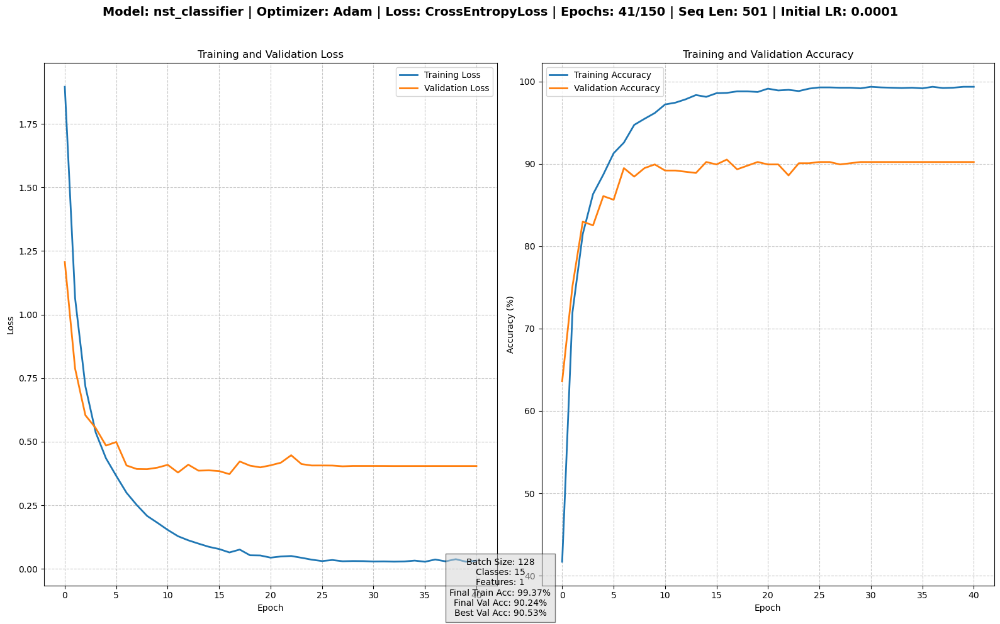

Val Accuracy: 90.24%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_501_confusion_matrix.png


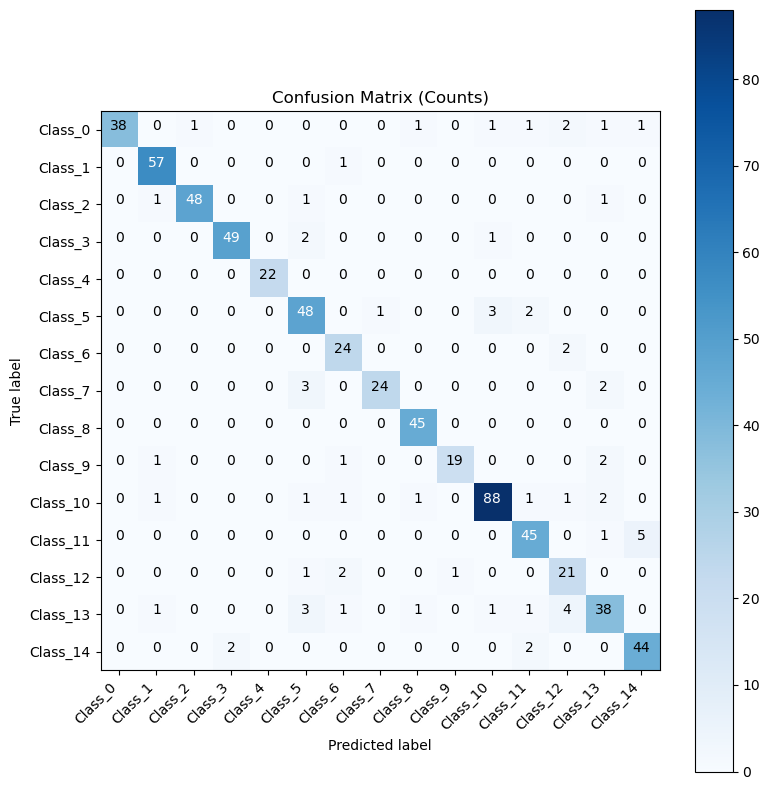

Successfully saved: checkpoints/UTMobile/nst_classifier_501_confusion_matrix_percent.png


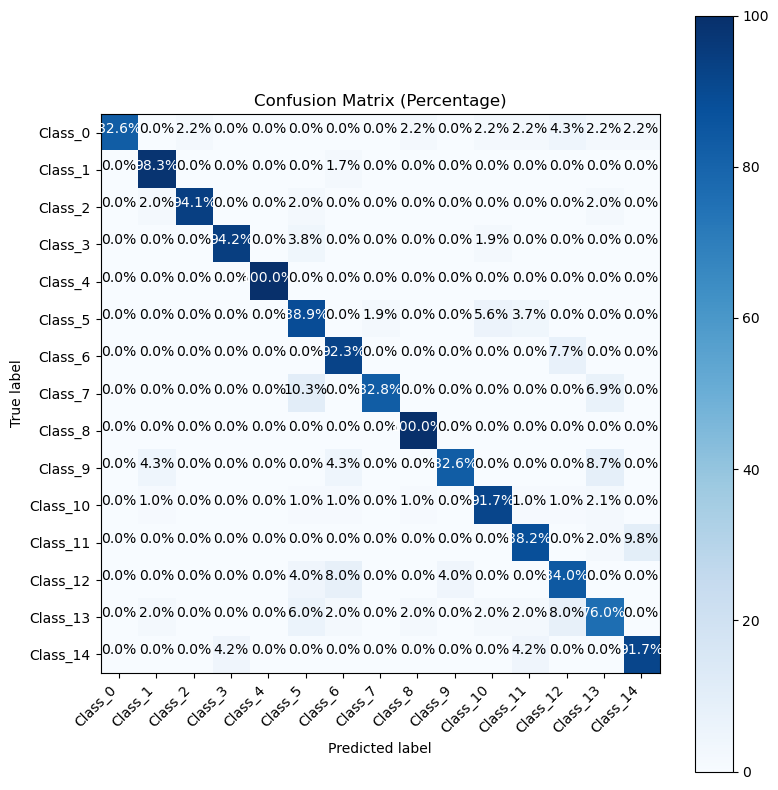


Evaluation Complete!
Total evaluation time: 0:00:00.372560

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:11,  1.29s/it, train_loss=2.0019, train_acc=41.17%, val_loss=1.2376, val_acc=64.79%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_251_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.0019, Accuracy: 41.17%
Validation Loss: 1.2376, Accuracy: 64.79%
Current LR: 1.00e-04
Epoch time: 0:00:01.285822
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:01,  1.22s/it, train_loss=1.1046, train_acc=73.68%, val_loss=0.6715, val_acc=83.28%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_251_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.1046, Accuracy: 73.68%
Validation Loss: 0.6715, Accuracy: 83.28%
Current LR: 1.00e-04
Epoch time: 0:00:01.179608
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 50/150
Training Loss: 0.0262, Accuracy: 99.30%
Validation Loss: 0.3448, Accuracy: 92.46%
Current LR: 1.00e-07
Epoch time: 0:00:01.275874
----------------------------------------


Training:  34%|███▍      | 51/150 [01:05<02:08,  1.30s/it, train_loss=0.0251, train_acc=99.41%, val_loss=0.3448, val_acc=92.46%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 51/150
Training Loss: 0.0251, Accuracy: 99.41%
Validation Loss: 0.3448, Accuracy: 92.46%
Current LR: 1.00e-07
Epoch time: 0:00:01.291704
----------------------------------------


Training:  34%|███▍      | 51/150 [01:07<02:10,  1.32s/it, train_loss=0.0259, train_acc=99.41%, val_loss=0.3448, val_acc=92.46%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 52/150
Training Loss: 0.0259, Accuracy: 99.41%
Validation Loss: 0.3448, Accuracy: 92.46%
Current LR: 1.00e-07
Epoch time: 0:00:01.308705
----------------------------------------
Early stopping triggered after 52 epochs

Training Complete!
Total training time: 0:01:07.248603

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e52_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc92.9.png
Successfully saved metrics plot


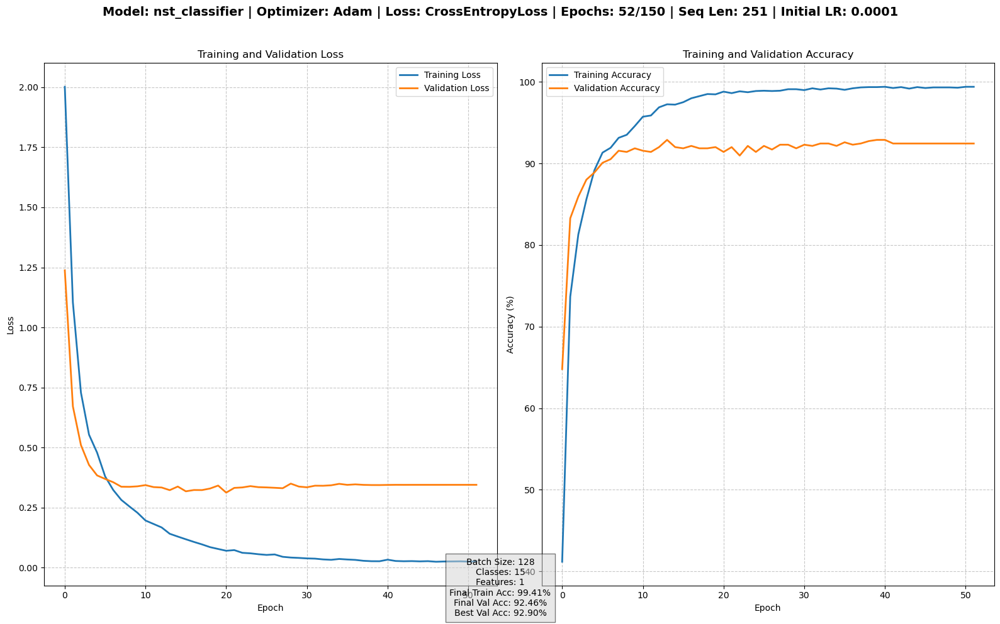

Val Accuracy: 92.46%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_251_confusion_matrix.png


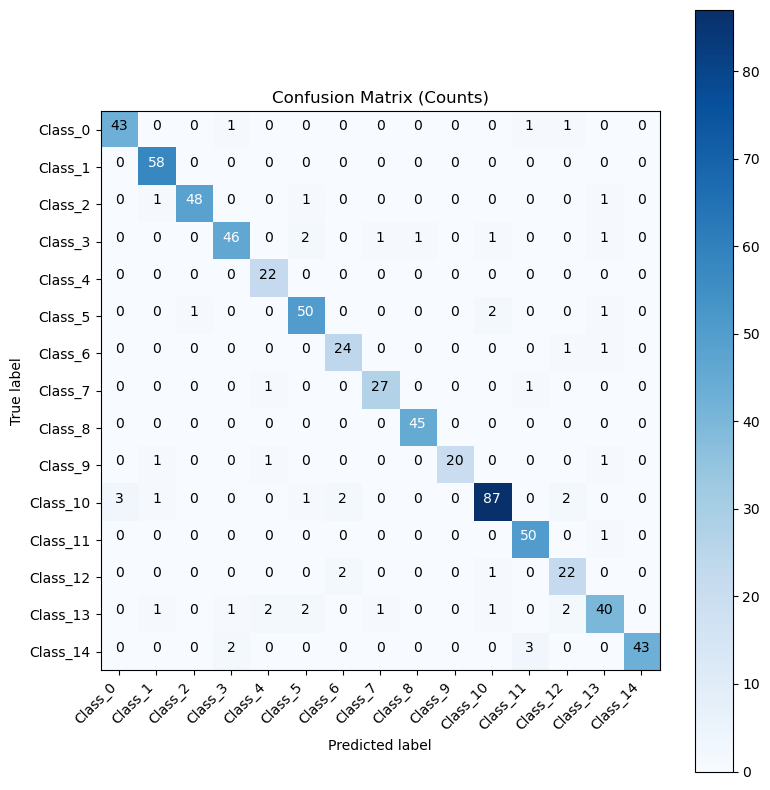

Successfully saved: checkpoints/UTMobile/nst_classifier_251_confusion_matrix_percent.png


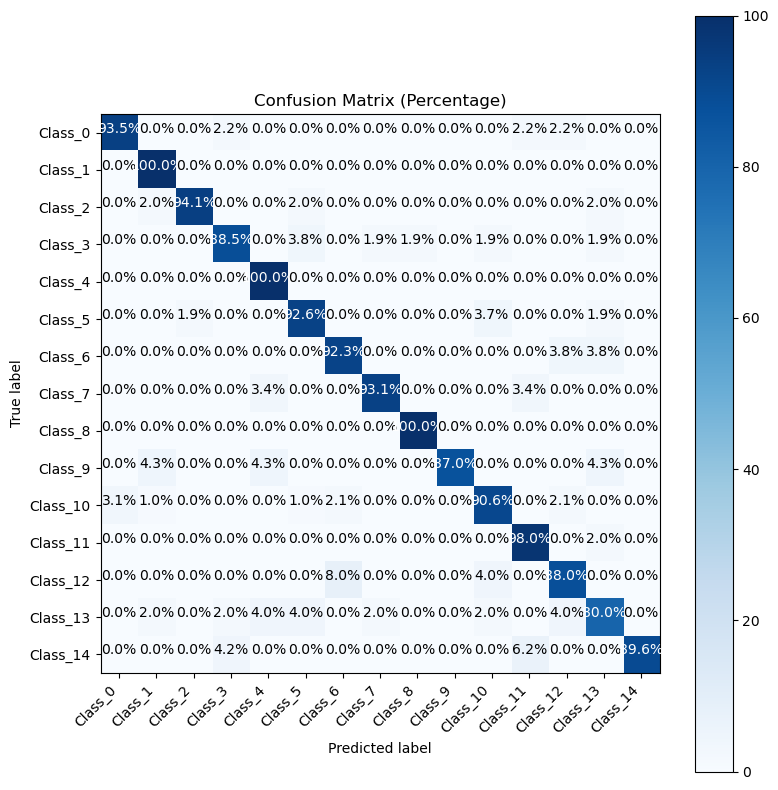


Evaluation Complete!
Total evaluation time: 0:00:00.263377

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<02:53,  1.16s/it, train_loss=2.2394, train_acc=33.89%, val_loss=1.4519, val_acc=61.39%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.2394, Accuracy: 33.89%
Validation Loss: 1.4519, Accuracy: 61.39%
Current LR: 1.00e-04
Epoch time: 0:00:01.163805
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<02:41,  1.09s/it, train_loss=1.2814, train_acc=68.19%, val_loss=0.8031, val_acc=79.59%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_167_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.2814, Accuracy: 68.19%
Validation Loss: 0.8031, Accuracy: 79.59%
Current LR: 1.00e-04
Epoch time: 0:00:01.034070
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 55/150
Training Loss: 0.0277, Accuracy: 99.41%
Validation Loss: 0.3166, Accuracy: 94.67%
Current LR: 1.00e-07
Epoch time: 0:00:01.133747
----------------------------------------


Training:  37%|███▋      | 56/150 [01:01<01:42,  1.10s/it, train_loss=0.0277, train_acc=99.30%, val_loss=0.3166, val_acc=94.67%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 56/150
Training Loss: 0.0277, Accuracy: 99.30%
Validation Loss: 0.3166, Accuracy: 94.67%
Current LR: 1.00e-07
Epoch time: 0:00:01.140485
----------------------------------------


Training:  37%|███▋      | 56/150 [01:02<01:45,  1.12s/it, train_loss=0.0271, train_acc=99.30%, val_loss=0.3166, val_acc=94.67%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 57/150
Training Loss: 0.0271, Accuracy: 99.30%
Validation Loss: 0.3166, Accuracy: 94.67%
Current LR: 1.00e-07
Epoch time: 0:00:01.158085
----------------------------------------
Early stopping triggered after 57 epochs

Training Complete!
Total training time: 0:01:02.725795

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e57_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc94.7.png
Successfully saved metrics plot


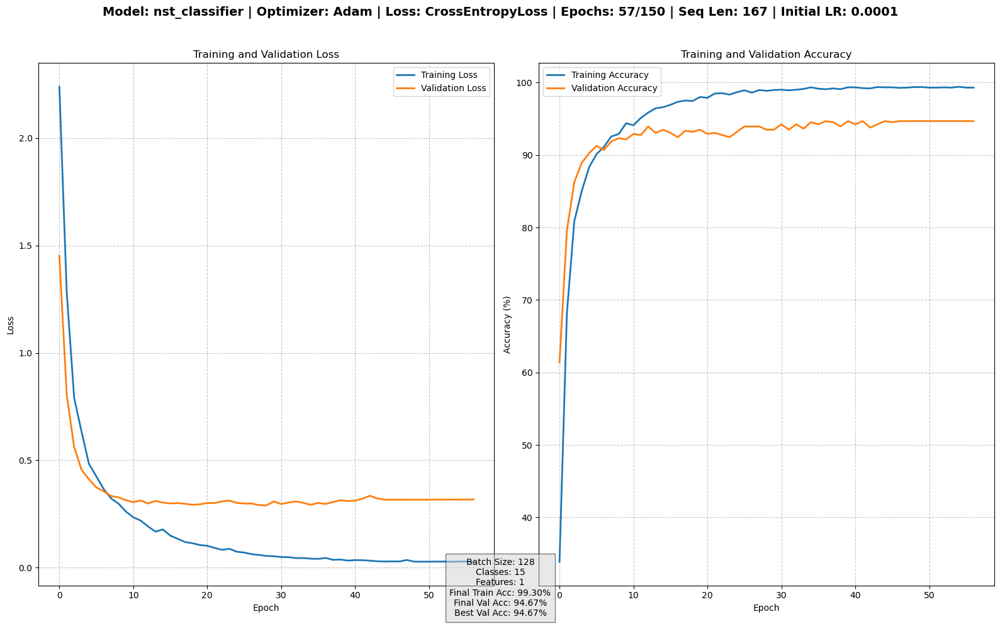

Val Accuracy: 94.67%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_167_confusion_matrix.png


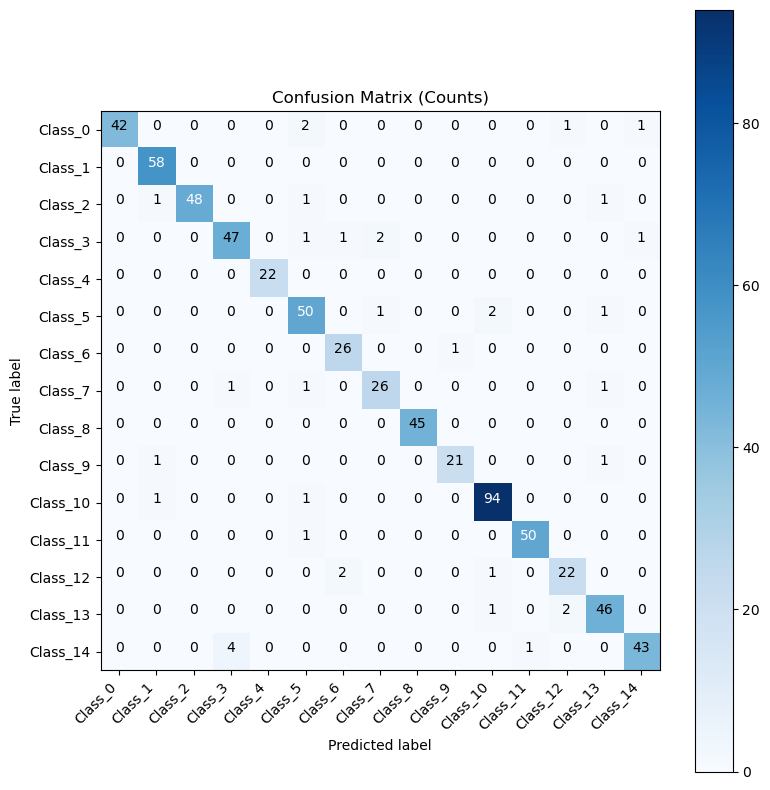

Successfully saved: checkpoints/UTMobile/nst_classifier_167_confusion_matrix_percent.png


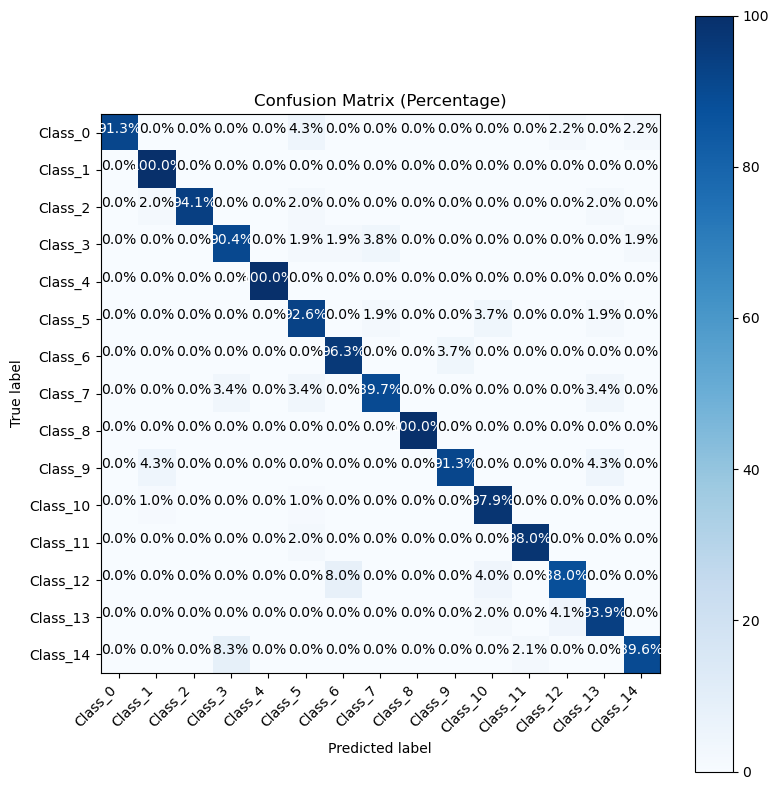


Evaluation Complete!
Total evaluation time: 0:00:00.256355

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<02:42,  1.09s/it, train_loss=2.3540, train_acc=27.92%, val_loss=1.7634, val_acc=61.54%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.3540, Accuracy: 27.92%
Validation Loss: 1.7634, Accuracy: 61.54%
Current LR: 1.00e-04
Epoch time: 0:00:01.089956
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<02:38,  1.07s/it, train_loss=1.6023, train_acc=60.20%, val_loss=1.1308, val_acc=69.23%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_126_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.6023, Accuracy: 60.20%
Validation Loss: 1.1308, Accuracy: 69.23%
Current LR: 1.00e-04
Epoch time: 0:00:01.056211
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 68/150
Training Loss: 0.0313, Accuracy: 99.37%
Validation Loss: 0.3565, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.105590
----------------------------------------


Training:  46%|████▌     | 69/150 [01:16<01:29,  1.11s/it, train_loss=0.0381, train_acc=99.33%, val_loss=0.3565, val_acc=91.86%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 69/150
Training Loss: 0.0381, Accuracy: 99.33%
Validation Loss: 0.3565, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.125156
----------------------------------------


Training:  46%|████▌     | 69/150 [01:17<01:30,  1.12s/it, train_loss=0.0308, train_acc=99.37%, val_loss=0.3565, val_acc=91.86%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 70/150
Training Loss: 0.0308, Accuracy: 99.37%
Validation Loss: 0.3565, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.113792
----------------------------------------
Early stopping triggered after 70 epochs

Training Complete!
Total training time: 0:01:17.409696

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e70_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc92.9.png
Successfully saved metrics plot


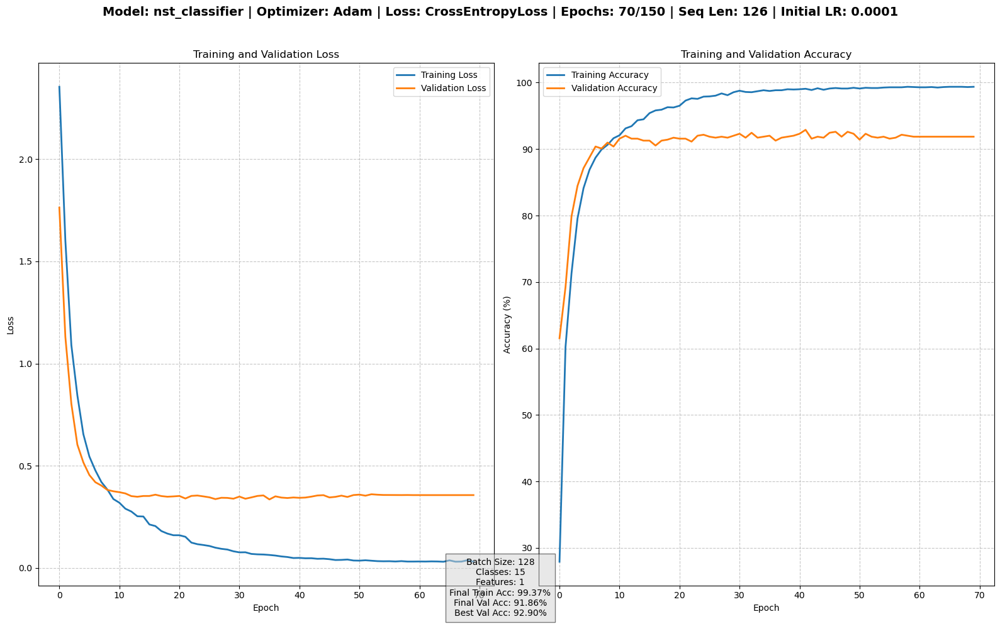

Val Accuracy: 91.86%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_126_confusion_matrix.png


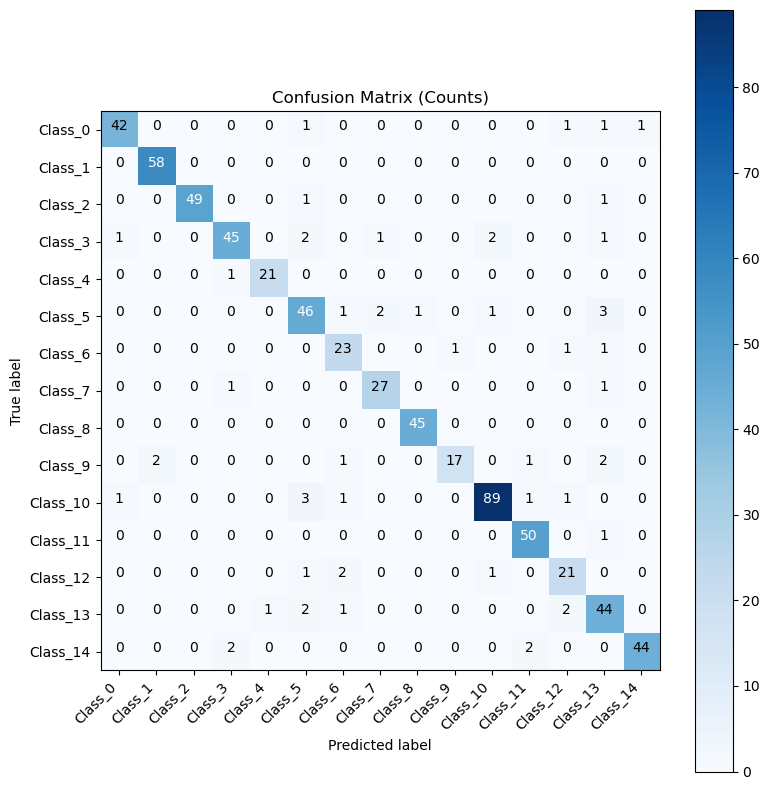

Successfully saved: checkpoints/UTMobile/nst_classifier_126_confusion_matrix_percent.png


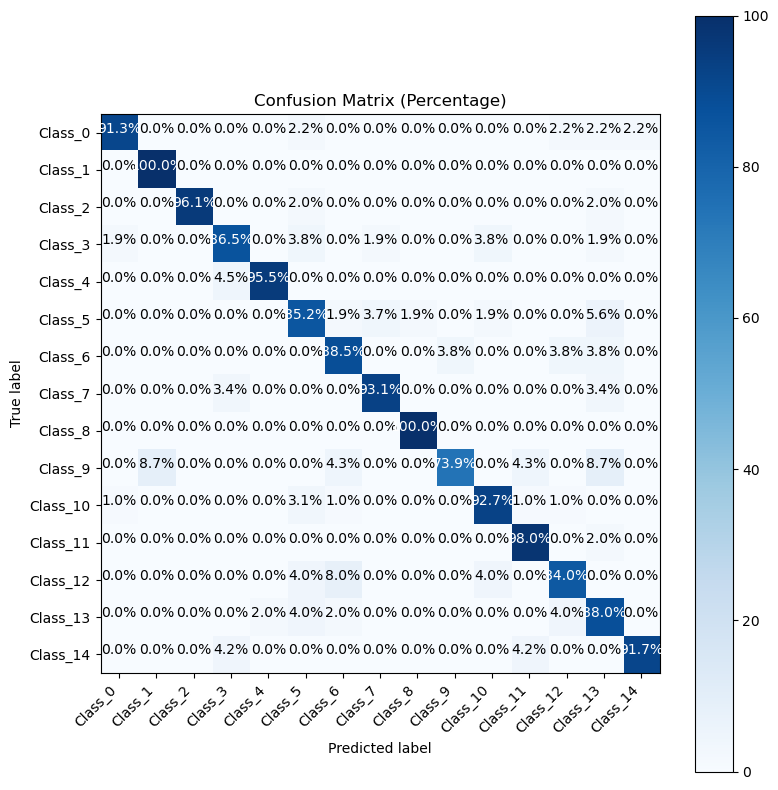


Evaluation Complete!
Total evaluation time: 0:00:00.248996

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<02:31,  1.02s/it, train_loss=2.5177, train_acc=20.04%, val_loss=2.1080, val_acc=40.83%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.5177, Accuracy: 20.04%
Validation Loss: 2.1080, Accuracy: 40.83%
Current LR: 1.00e-04
Epoch time: 0:00:01.015750
----------------------------------------


Training:   1%|▏         | 2/150 [00:01<02:27,  1.01it/s, train_loss=2.0231, train_acc=42.56%, val_loss=1.5301, val_acc=59.47%, time=0:00:00]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_67_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 2.0231, Accuracy: 42.56%
Validation Loss: 1.5301, Accuracy: 59.47%
Current LR: 1.00e-04
Epoch time: 0:00:00.974616
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 68/150
Training Loss: 0.0657, Accuracy: 98.74%
Validation Loss: 0.3133, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.080071
----------------------------------------


Training:  46%|████▌     | 69/150 [01:15<01:28,  1.09s/it, train_loss=0.0676, train_acc=98.85%, val_loss=0.3133, val_acc=91.86%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 69/150
Training Loss: 0.0676, Accuracy: 98.85%
Validation Loss: 0.3133, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.046451
----------------------------------------


Training:  46%|████▌     | 69/150 [01:16<01:30,  1.11s/it, train_loss=0.0667, train_acc=98.63%, val_loss=0.3132, val_acc=91.86%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 70/150
Training Loss: 0.0667, Accuracy: 98.63%
Validation Loss: 0.3132, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.092859
----------------------------------------
Early stopping triggered after 70 epochs

Training Complete!
Total training time: 0:01:16.700799

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e70_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc92.0.png
Successfully saved metrics plot


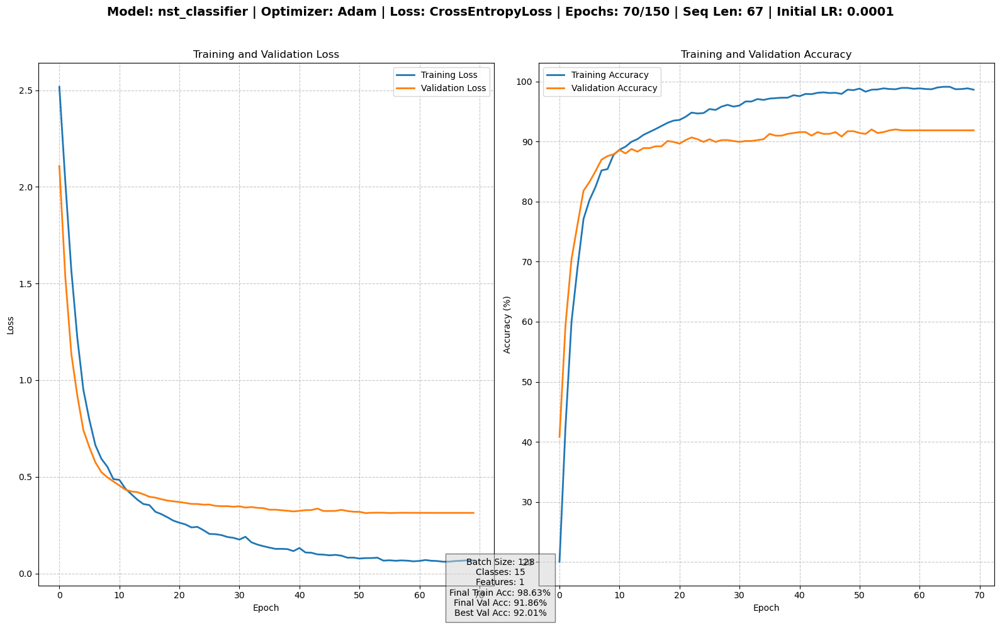

Val Accuracy: 91.86%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_67_confusion_matrix.png


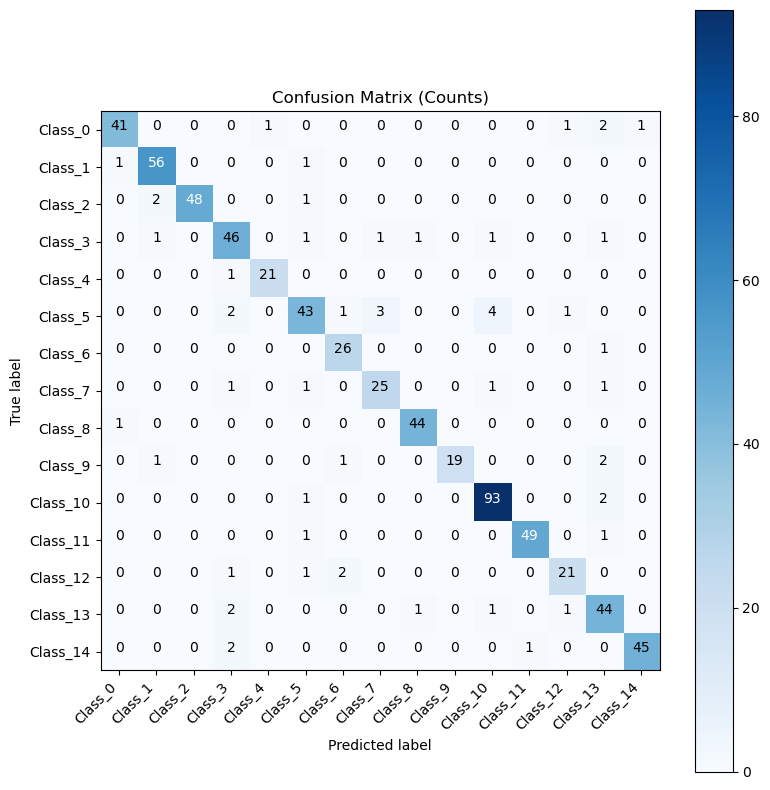

Successfully saved: checkpoints/UTMobile/nst_classifier_67_confusion_matrix_percent.png


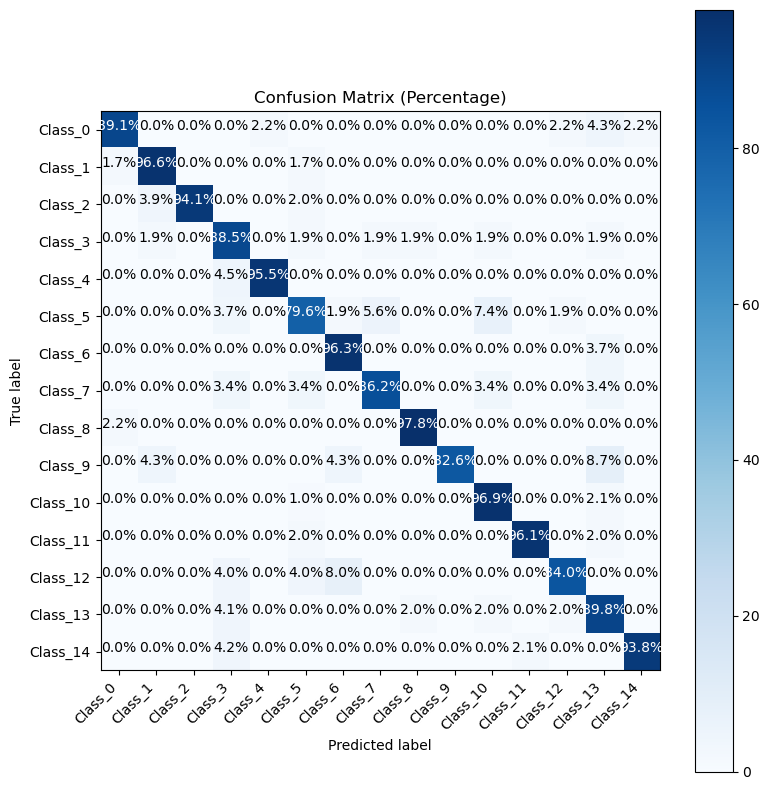


Evaluation Complete!
Total evaluation time: 0:00:00.232090

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<02:54,  1.17s/it, train_loss=2.5971, train_acc=15.18%, val_loss=2.3441, val_acc=31.66%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.5971, Accuracy: 15.18%
Validation Loss: 2.3441, Accuracy: 31.66%
Current LR: 1.00e-04
Epoch time: 0:00:01.171373
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<02:48,  1.14s/it, train_loss=2.2841, train_acc=34.69%, val_loss=1.9904, val_acc=46.89%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/nst_classifier_26_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 2.2841, Accuracy: 34.69%
Validation Loss: 1.9904, Accuracy: 46.89%
Current LR: 1.00e-04
Epoch time: 0:00:01.113774
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 62/150
Training Loss: 0.3529, Accuracy: 90.86%
Validation Loss: 0.3875, Accuracy: 88.91%
Current LR: 1.00e-07
Epoch time: 0:00:01.100521
----------------------------------------


Training:  42%|████▏     | 63/150 [01:08<01:34,  1.09s/it, train_loss=0.3465, train_acc=90.89%, val_loss=0.3875, val_acc=88.91%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 63/150
Training Loss: 0.3465, Accuracy: 90.89%
Validation Loss: 0.3875, Accuracy: 88.91%
Current LR: 1.00e-07
Epoch time: 0:00:01.061204
----------------------------------------


Training:  42%|████▏     | 63/150 [01:10<01:36,  1.11s/it, train_loss=0.3374, train_acc=90.71%, val_loss=0.3875, val_acc=88.91%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 64/150
Training Loss: 0.3374, Accuracy: 90.71%
Validation Loss: 0.3875, Accuracy: 88.91%
Current LR: 1.00e-07
Epoch time: 0:00:01.103829
----------------------------------------
Early stopping triggered after 64 epochs

Training Complete!
Total training time: 0:01:10.024303

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/nst_classifier_e64_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc89.1.png
Successfully saved metrics plot


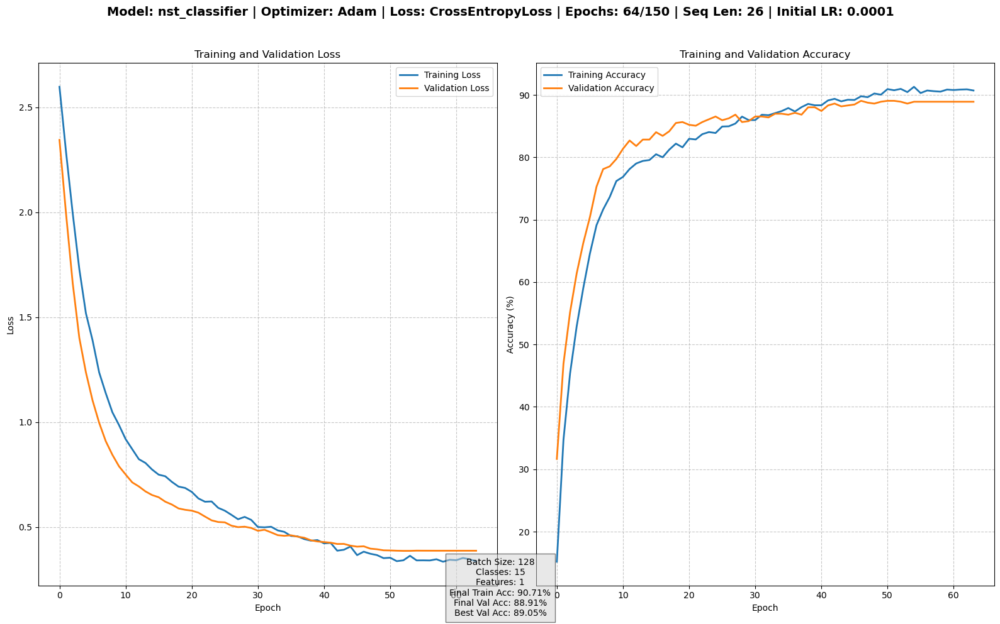

Val Accuracy: 88.91%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/nst_classifier_26_confusion_matrix.png


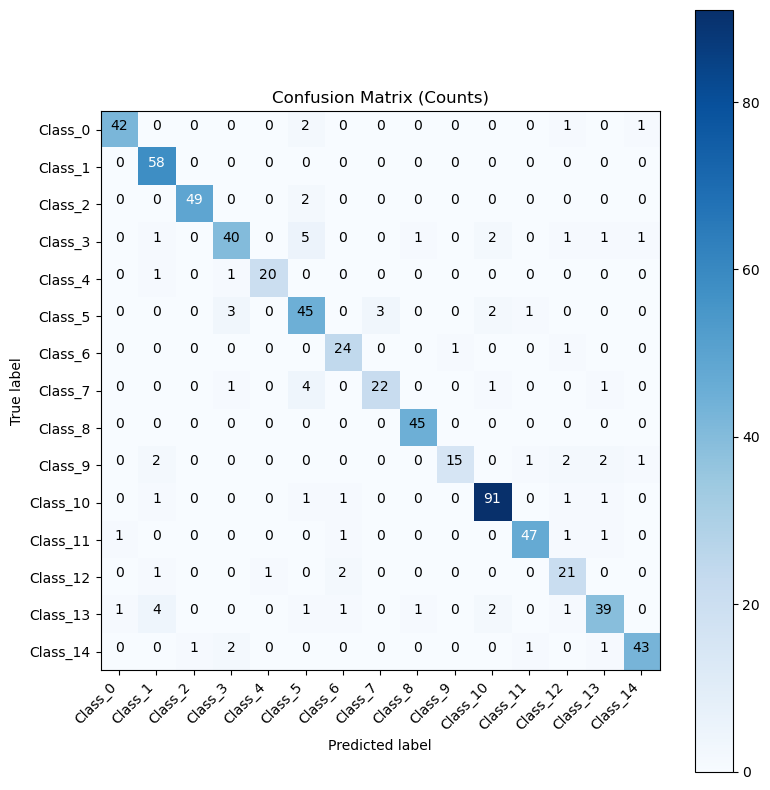

Successfully saved: checkpoints/UTMobile/nst_classifier_26_confusion_matrix_percent.png


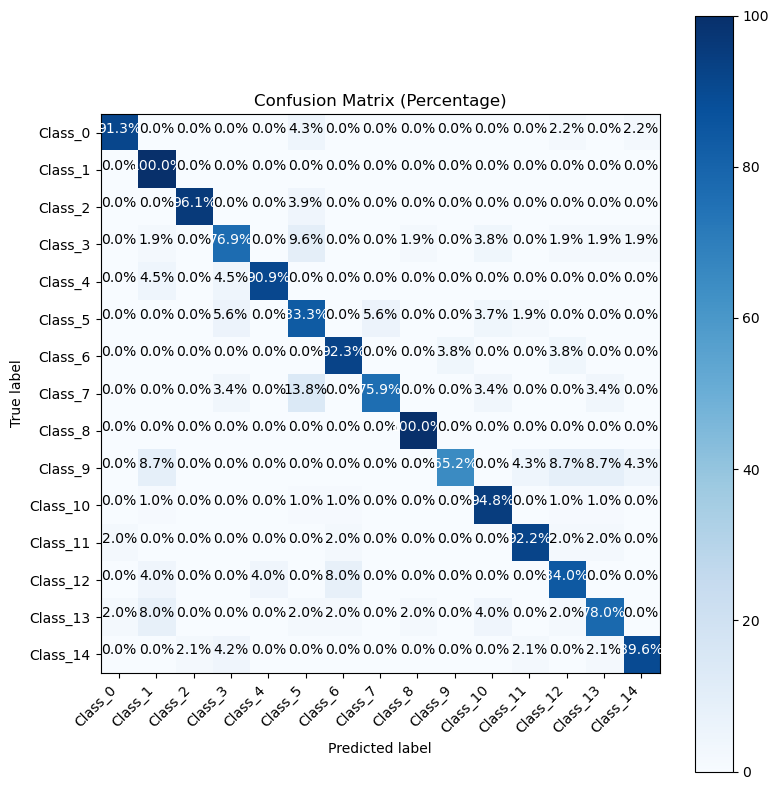


Evaluation Complete!
Total evaluation time: 0:00:00.252214

Evaluating INFORMER model across datasets...

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:03<09:01,  3.63s/it, train_loss=1.4908, train_acc=56.61%, val_loss=0.7205, val_acc=78.11%, time=0:00:03]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.4908, Accuracy: 56.61%
Validation Loss: 0.7205, Accuracy: 78.11%
Current LR: 1.00e-04
Epoch time: 0:00:03.629441
----------------------------------------


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_501_best.pth


Training:   1%|▏         | 2/150 [00:07<08:52,  3.60s/it, train_loss=0.5046, train_acc=86.41%, val_loss=0.5409, val_acc=84.62%, time=0:00:03]

...

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 31/150
Training Loss: 0.0229, Accuracy: 99.44%
Validation Loss: 0.5804, Accuracy: 88.61%
Current LR: 1.00e-07
Epoch time: 0:00:03.454745
----------------------------------------


Training:  21%|██▏       | 32/150 [01:52<06:52,  3.50s/it, train_loss=0.0170, train_acc=99.41%, val_loss=0.5902, val_acc=88.76%, time=0:00:03]

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 32/150
Training Loss: 0.0170, Accuracy: 99.41%
Validation Loss: 0.5902, Accuracy: 88.76%
Current LR: 1.00e-07
Epoch time: 0:00:03.460052
----------------------------------------


Training:  21%|██▏       | 32/150 [01:56<07:08,  3.63s/it, train_loss=0.0163, train_acc=99.44%, val_loss=0.5933, val_acc=88.61%, time=0:00:03]


ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 33/150
Training Loss: 0.0163, Accuracy: 99.44%
Validation Loss: 0.5933, Accuracy: 88.61%
Current LR: 1.00e-07
Epoch time: 0:00:03.471019
----------------------------------------
Early stopping triggered after 33 epochs

Training Complete!
Total training time: 0:01:56.244784

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e33_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc89.3.png
Successfully saved metrics plot


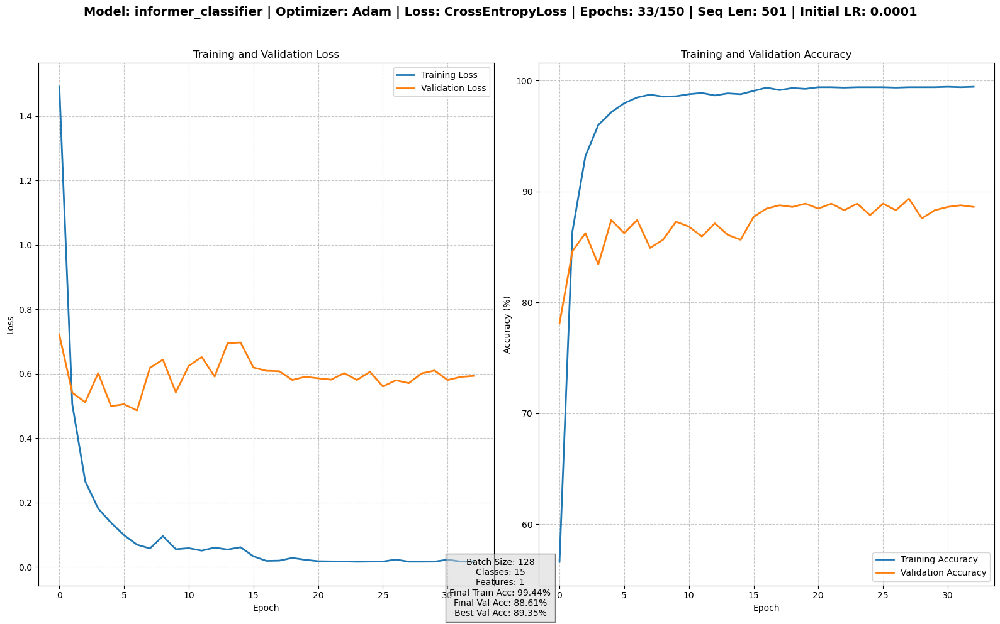

Val Accuracy: 88.61%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_501_confusion_matrix.png


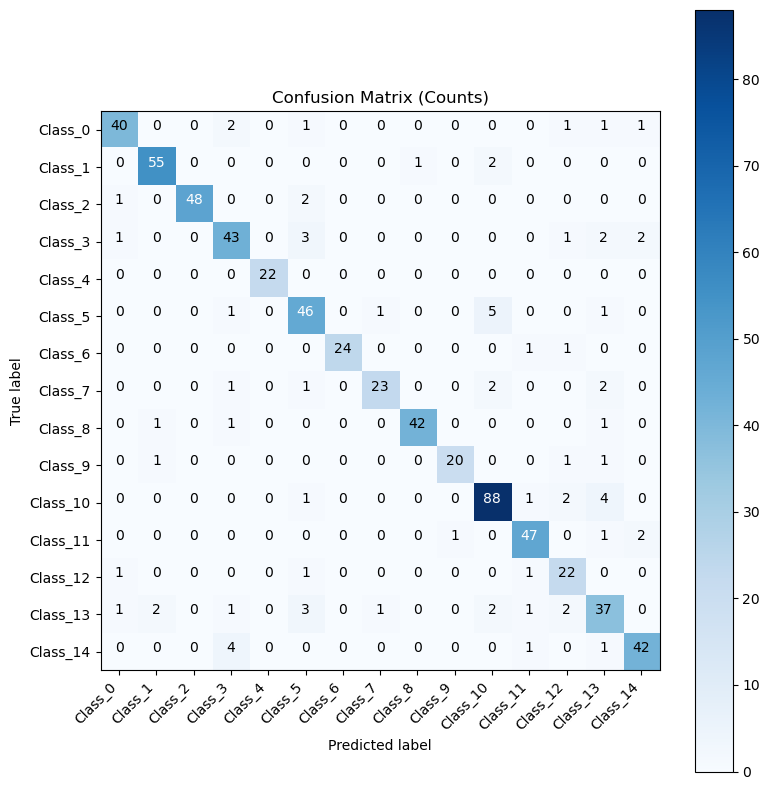

Successfully saved: checkpoints/UTMobile/informer_classifier_501_confusion_matrix_percent.png


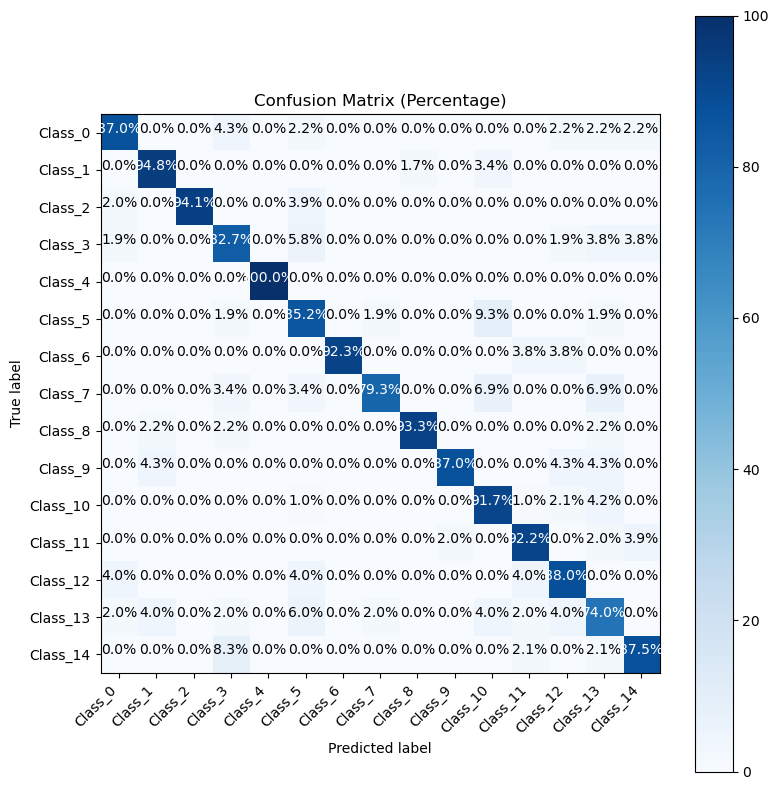


Evaluation Complete!
Total evaluation time: 0:00:00.522036

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:02<05:20,  2.15s/it, train_loss=1.3728, train_acc=59.64%, val_loss=0.6495, val_acc=80.47%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.3728, Accuracy: 59.64%
Validation Loss: 0.6495, Accuracy: 80.47%
Current LR: 1.00e-04
Epoch time: 0:00:02.149650
----------------------------------------


Training:   1%|▏         | 2/150 [00:04<05:23,  2.18s/it, train_loss=0.5434, train_acc=85.34%, val_loss=0.4669, val_acc=88.02%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 0.5434, Accuracy: 85.34%
Validation Loss: 0.4669, Accuracy: 88.02%
Current LR: 1.00e-04
Epoch time: 0:00:02.204040
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 34/150
Training Loss: 0.0164, Accuracy: 99.44%
Validation Loss: 0.4028, Accuracy: 92.01%
Current LR: 1.00e-07
Epoch time: 0:00:02.083342
----------------------------------------


Training:  23%|██▎       | 35/150 [01:14<03:59,  2.09s/it, train_loss=0.0163, train_acc=99.48%, val_loss=0.4195, val_acc=91.27%, time=0:00:02]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 35/150
Training Loss: 0.0163, Accuracy: 99.48%
Validation Loss: 0.4195, Accuracy: 91.27%
Current LR: 1.00e-07
Epoch time: 0:00:02.074165
----------------------------------------


Training:  23%|██▎       | 35/150 [01:16<04:10,  2.18s/it, train_loss=0.0160, train_acc=99.48%, val_loss=0.4042, val_acc=91.86%, time=0:00:02]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 36/150
Training Loss: 0.0160, Accuracy: 99.48%
Validation Loss: 0.4042, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:02.068551
----------------------------------------
Early stopping triggered after 36 epochs

Training Complete!
Total training time: 0:01:16.368998

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e36_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc92.0.png
Successfully saved metrics plot


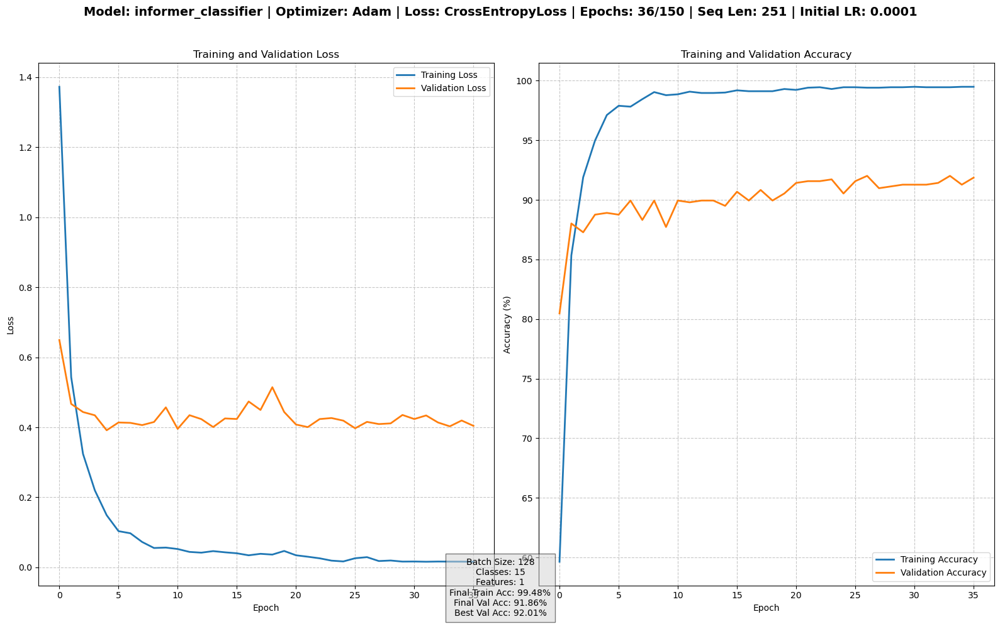

Val Accuracy: 92.01%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_251_confusion_matrix.png


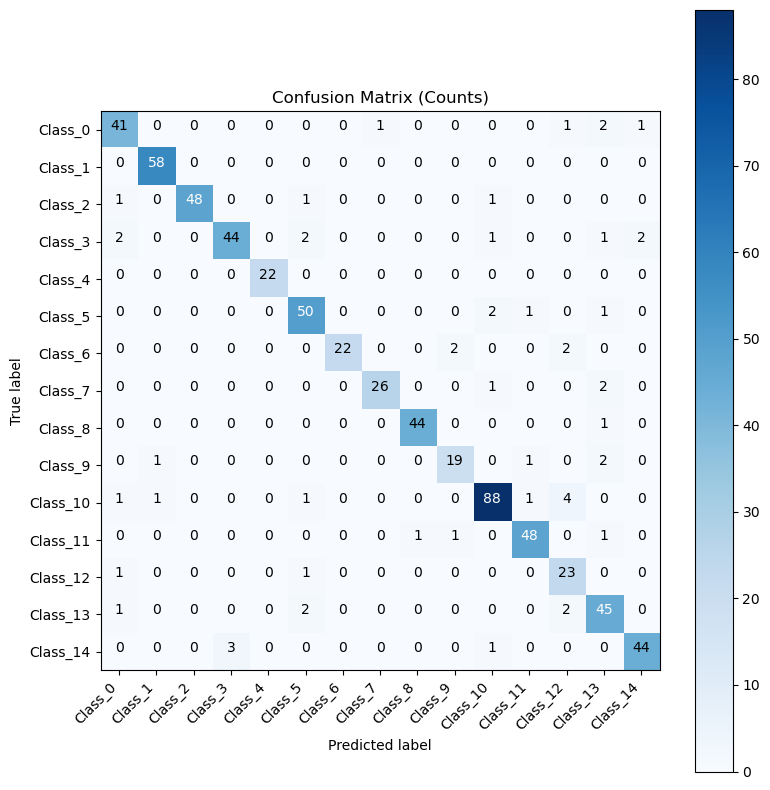

Successfully saved: checkpoints/UTMobile/informer_classifier_251_confusion_matrix_percent.png


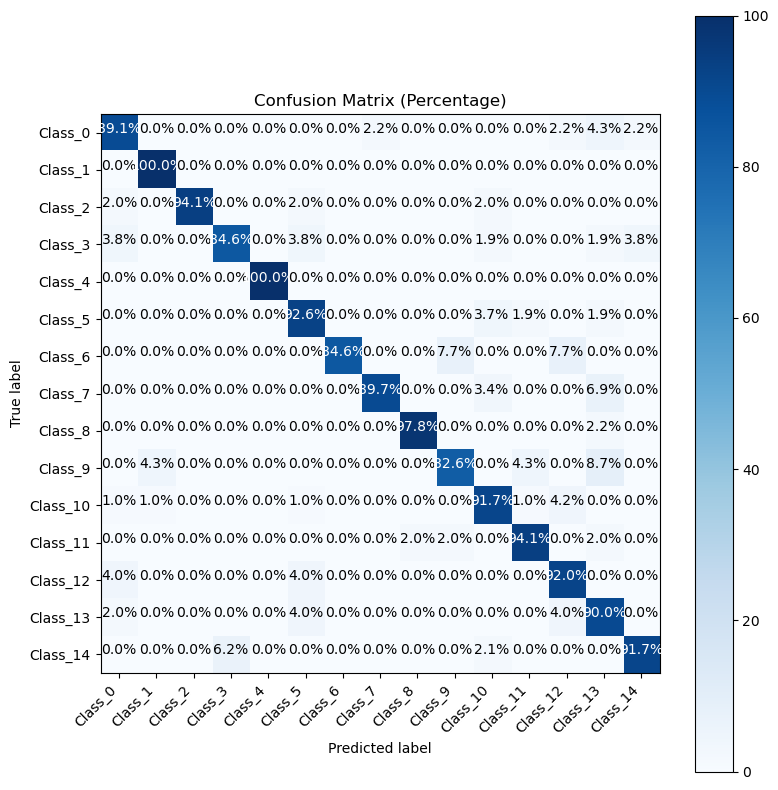


Evaluation Complete!
Total evaluation time: 0:00:00.344537

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<04:25,  1.78s/it, train_loss=1.4386, train_acc=58.52%, val_loss=0.6960, val_acc=80.47%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.4386, Accuracy: 58.52%
Validation Loss: 0.6960, Accuracy: 80.47%
Current LR: 1.00e-04
Epoch time: 0:00:01.779043
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:26,  1.80s/it, train_loss=0.6088, train_acc=83.81%, val_loss=0.5081, val_acc=85.36%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 0.6088, Accuracy: 83.81%
Validation Loss: 0.5081, Accuracy: 85.36%
Current LR: 1.00e-04
Epoch time: 0:00:01.813113
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 37/150
Training Loss: 0.0164, Accuracy: 99.41%
Validation Loss: 0.4167, Accuracy: 90.98%
Current LR: 1.00e-07
Epoch time: 0:00:01.749799
----------------------------------------


Training:  25%|██▌       | 38/150 [01:07<03:16,  1.76s/it, train_loss=0.0170, train_acc=99.41%, val_loss=0.3985, val_acc=91.42%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 38/150
Training Loss: 0.0170, Accuracy: 99.41%
Validation Loss: 0.3985, Accuracy: 91.42%
Current LR: 1.00e-07
Epoch time: 0:00:01.759670
----------------------------------------


Training:  25%|██▌       | 38/150 [01:09<03:24,  1.82s/it, train_loss=0.0167, train_acc=99.41%, val_loss=0.3996, val_acc=90.24%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 39/150
Training Loss: 0.0167, Accuracy: 99.41%
Validation Loss: 0.3996, Accuracy: 90.24%
Current LR: 1.00e-07
Epoch time: 0:00:01.752367
----------------------------------------
Early stopping triggered after 39 epochs

Training Complete!
Total training time: 0:01:09.342988

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e39_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc91.7.png
Successfully saved metrics plot


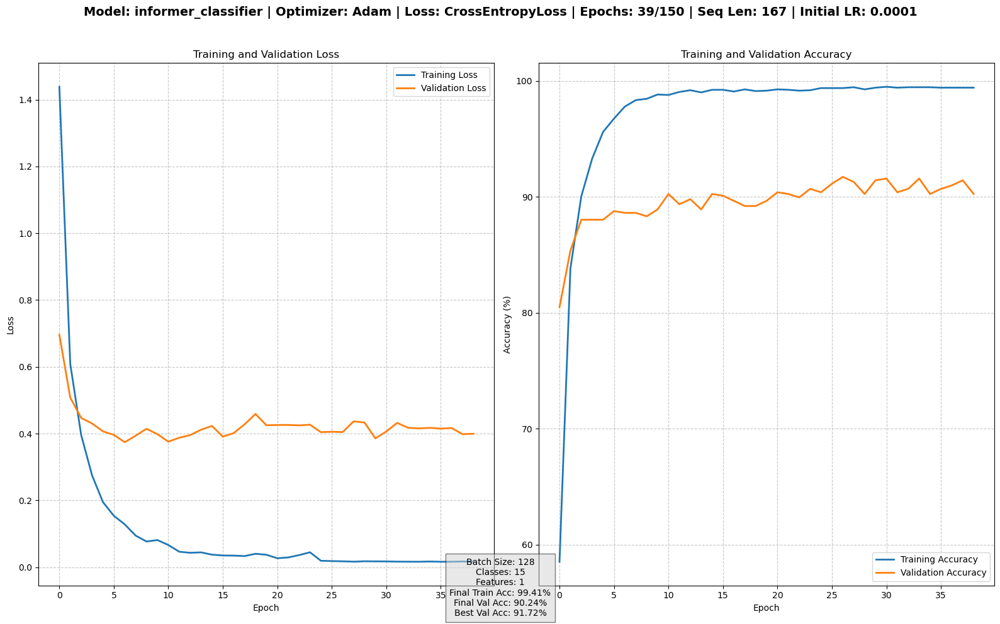

Val Accuracy: 91.12%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_167_confusion_matrix.png


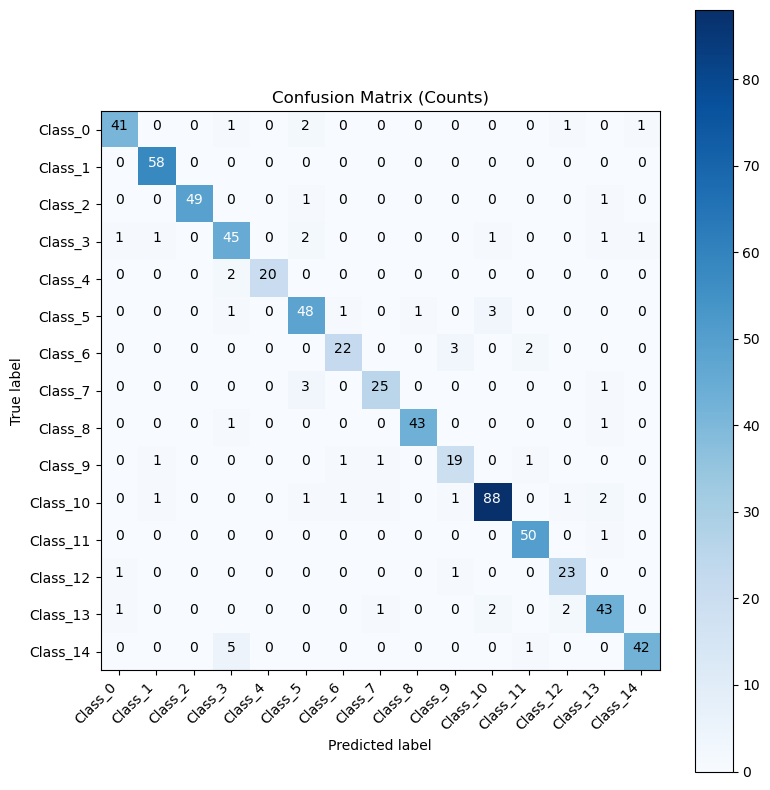

Successfully saved: checkpoints/UTMobile/informer_classifier_167_confusion_matrix_percent.png


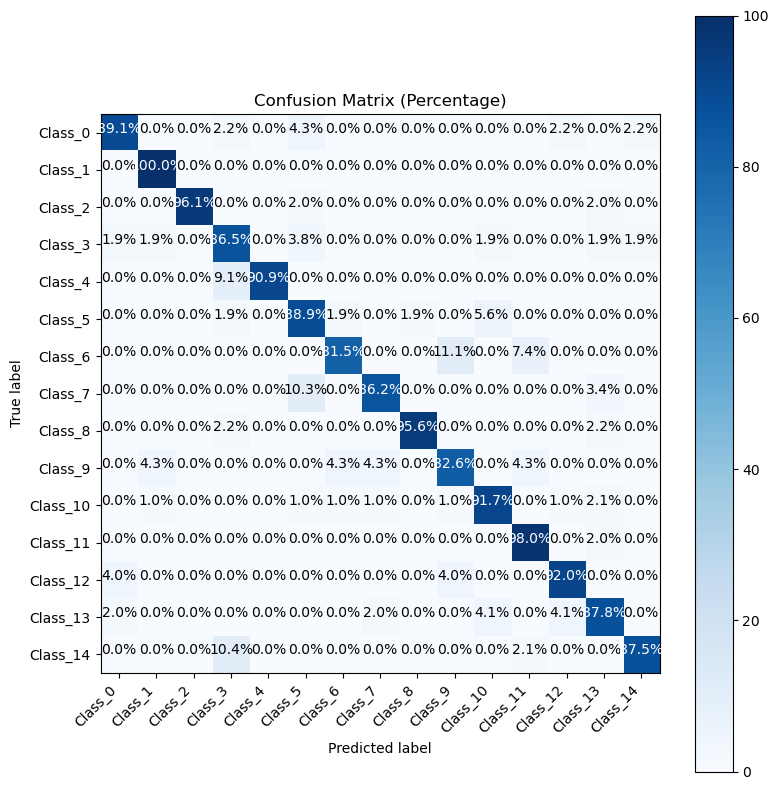


Evaluation Complete!
Total evaluation time: 0:00:00.305429

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<04:09,  1.68s/it, train_loss=1.4823, train_acc=55.35%, val_loss=0.7742, val_acc=79.44%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.4823, Accuracy: 55.35%
Validation Loss: 0.7742, Accuracy: 79.44%
Current LR: 1.00e-04
Epoch time: 0:00:01.675728
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:08,  1.68s/it, train_loss=0.6512, train_acc=83.04%, val_loss=0.5105, val_acc=87.72%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 0.6512, Accuracy: 83.04%
Validation Loss: 0.5105, Accuracy: 87.72%
Current LR: 1.00e-04
Epoch time: 0:00:01.674959
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 32/150
Training Loss: 0.0264, Accuracy: 99.37%
Validation Loss: 0.3263, Accuracy: 91.57%
Current LR: 1.00e-07
Epoch time: 0:00:01.545709
----------------------------------------


Training:  22%|██▏       | 33/150 [00:51<02:59,  1.54s/it, train_loss=0.0254, train_acc=99.37%, val_loss=0.3465, val_acc=92.16%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 33/150
Training Loss: 0.0254, Accuracy: 99.37%
Validation Loss: 0.3465, Accuracy: 92.16%
Current LR: 1.00e-07
Epoch time: 0:00:01.519183
----------------------------------------


Training:  22%|██▏       | 33/150 [00:52<03:06,  1.60s/it, train_loss=0.0262, train_acc=99.33%, val_loss=0.3423, val_acc=92.16%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 34/150
Training Loss: 0.0262, Accuracy: 99.33%
Validation Loss: 0.3423, Accuracy: 92.16%
Current LR: 1.00e-07
Epoch time: 0:00:01.550562
----------------------------------------
Early stopping triggered after 34 epochs

Training Complete!
Total training time: 0:00:52.670307

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e34_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc92.9.png
Successfully saved metrics plot


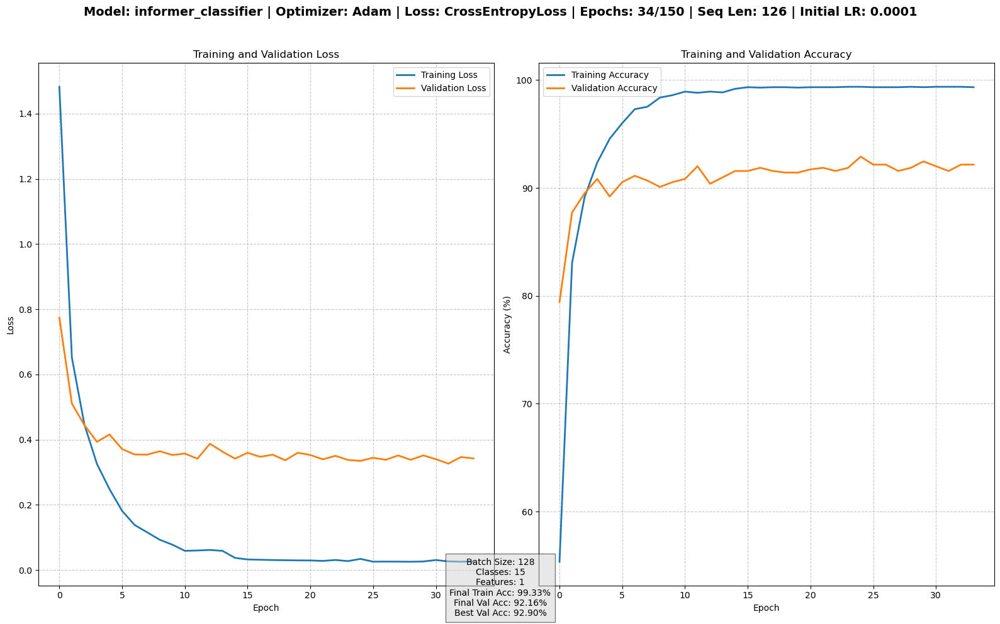

Val Accuracy: 92.16%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_126_confusion_matrix.png


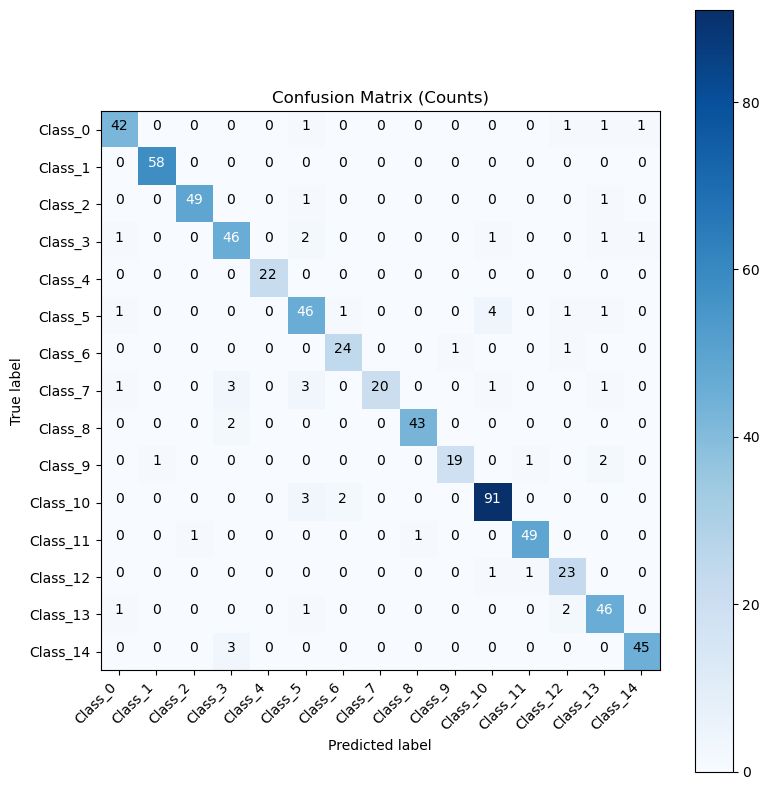

Successfully saved: checkpoints/UTMobile/informer_classifier_126_confusion_matrix_percent.png


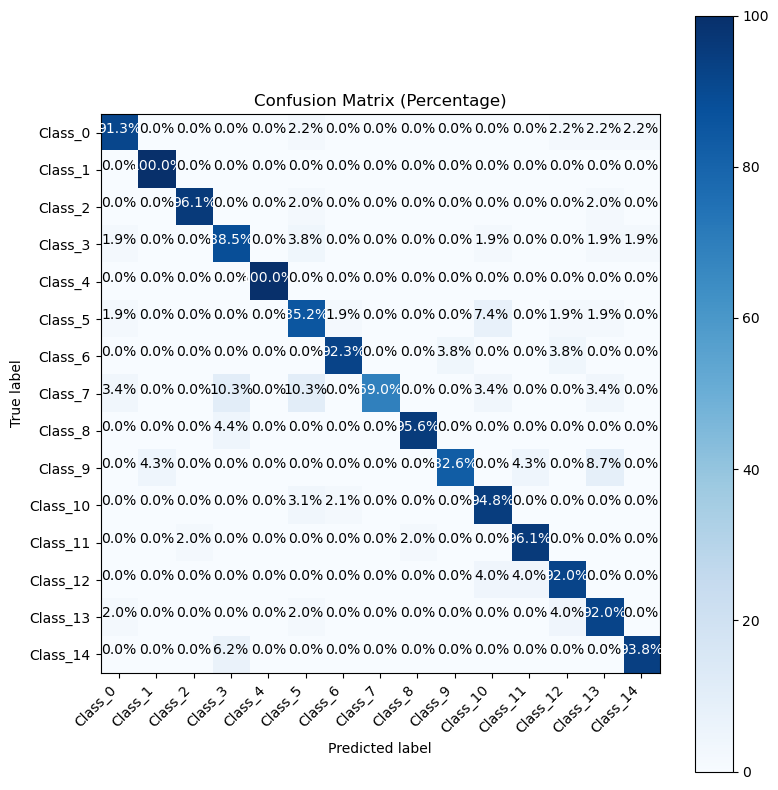


Evaluation Complete!
Total evaluation time: 0:00:00.280261

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:22,  1.36s/it, train_loss=1.8314, train_acc=45.70%, val_loss=1.0754, val_acc=72.63%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.8314, Accuracy: 45.70%
Validation Loss: 1.0754, Accuracy: 72.63%
Current LR: 1.00e-04
Epoch time: 0:00:01.354320
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:31,  1.43s/it, train_loss=0.9223, train_acc=75.33%, val_loss=0.7188, val_acc=77.51%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 0.9223, Accuracy: 75.33%
Validation Loss: 0.7188, Accuracy: 77.51%
Current LR: 1.00e-04
Epoch time: 0:00:01.476058
----------------------------------------


...

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 52/150
Training Loss: 0.0182, Accuracy: 99.48%
Validation Loss: 0.3530, Accuracy: 91.72%
Current LR: 1.00e-07
Epoch time: 0:00:01.340383
----------------------------------------


Training:  35%|███▌      | 53/150 [01:13<02:10,  1.35s/it, train_loss=0.0188, train_acc=99.44%, val_loss=0.3422, val_acc=92.31%, time=0:00:01]

ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 53/150
Training Loss: 0.0188, Accuracy: 99.44%
Validation Loss: 0.3422, Accuracy: 92.31%
Current LR: 1.00e-07
Epoch time: 0:00:01.307935
----------------------------------------


Training:  35%|███▌      | 53/150 [01:15<02:17,  1.42s/it, train_loss=0.0179, train_acc=99.44%, val_loss=0.3558, val_acc=92.46%, time=0:00:01]


ReduceLROnPlateau counter: 8 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 54/150
Training Loss: 0.0179, Accuracy: 99.44%
Validation Loss: 0.3558, Accuracy: 92.46%
Current LR: 1.00e-07
Epoch time: 0:00:01.338861
----------------------------------------
Early stopping triggered after 54 epochs

Training Complete!
Total training time: 0:01:15.027374

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e54_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc92.9.png
Successfully saved metrics plot


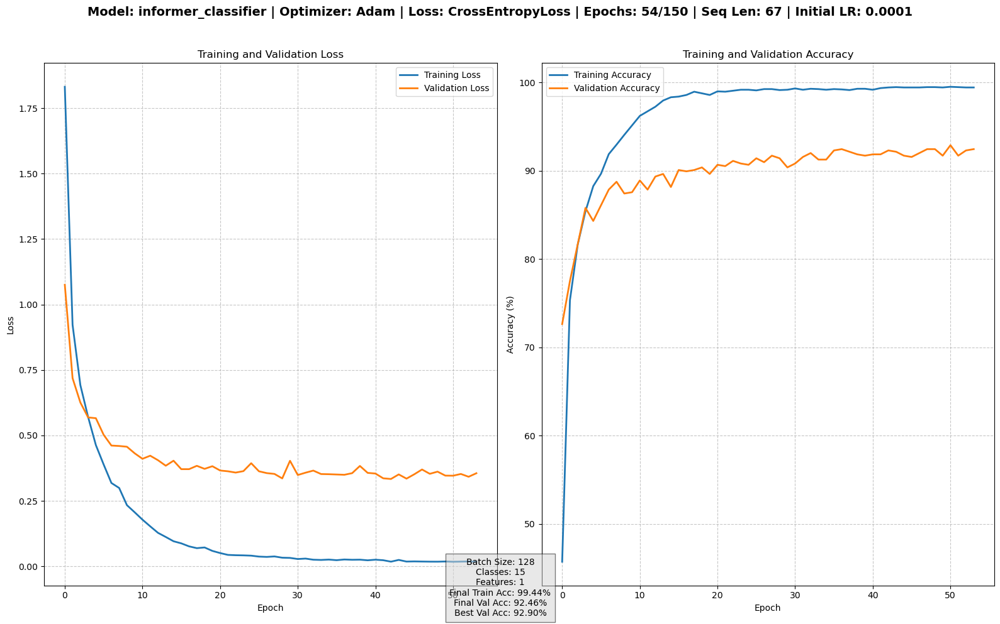

Val Accuracy: 91.86%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_67_confusion_matrix.png


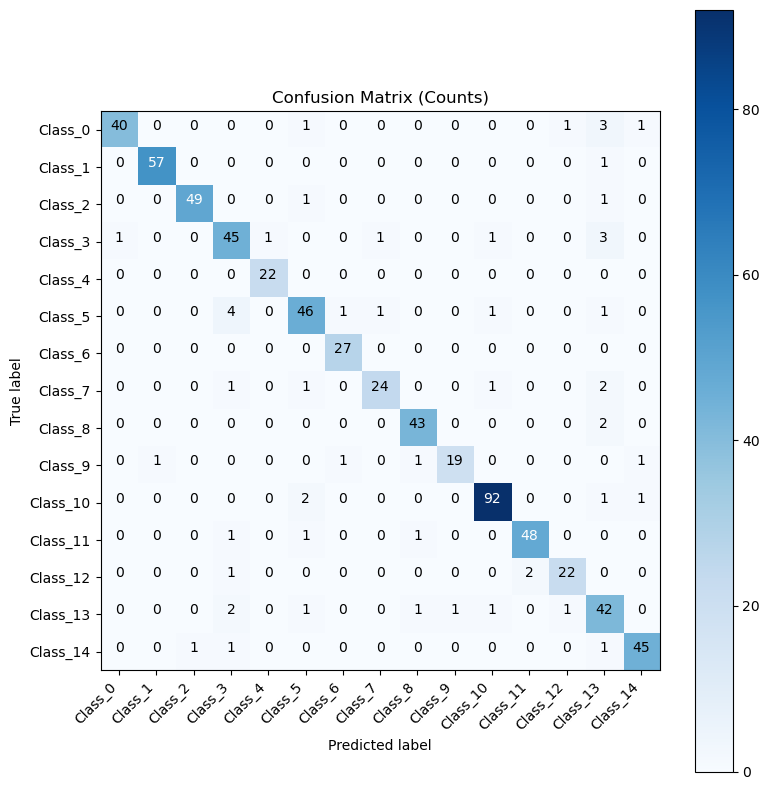

Successfully saved: checkpoints/UTMobile/informer_classifier_67_confusion_matrix_percent.png


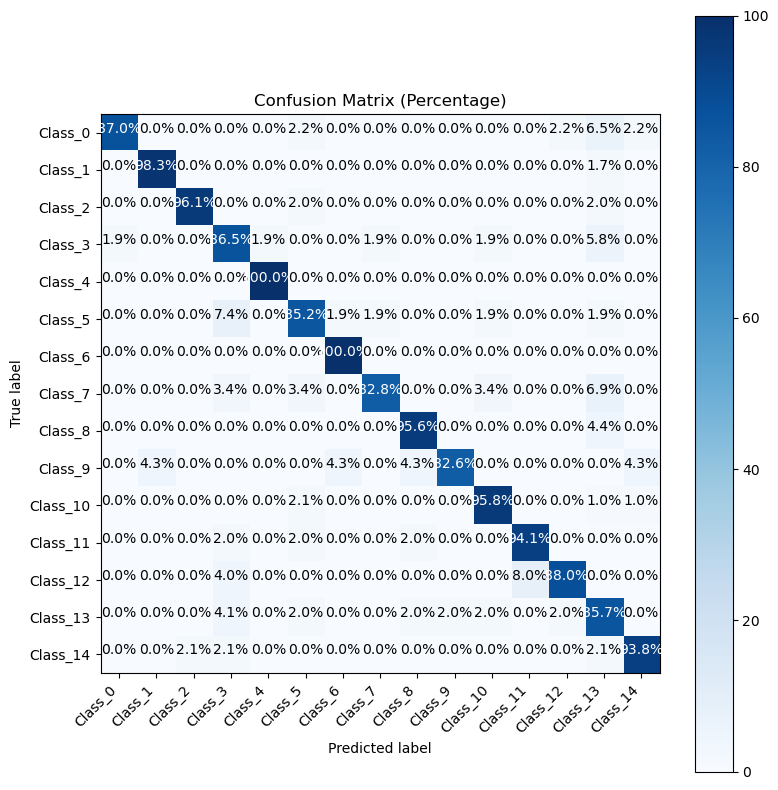


Evaluation Complete!
Total evaluation time: 0:00:00.261778

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:26,  1.39s/it, train_loss=2.0629, train_acc=39.80%, val_loss=1.4064, val_acc=60.36%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.0629, Accuracy: 39.80%
Validation Loss: 1.4064, Accuracy: 60.36%
Current LR: 1.00e-04
Epoch time: 0:00:01.384530
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:26,  1.40s/it, train_loss=1.2562, train_acc=66.57%, val_loss=0.9594, val_acc=73.67%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/informer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.2562, Accuracy: 66.57%
Validation Loss: 0.9594, Accuracy: 73.67%
Current LR: 1.00e-04
Epoch time: 0:00:01.398380
----------------------------------------


...

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 68/150
Training Loss: 0.0248, Accuracy: 99.41%
Validation Loss: 0.3126, Accuracy: 91.27%
Current LR: 1.00e-07
Epoch time: 0:00:01.217900
----------------------------------------


Training:  46%|████▌     | 69/150 [01:29<01:41,  1.25s/it, train_loss=0.0249, train_acc=99.44%, val_loss=0.3065, val_acc=91.12%, time=0:00:01]

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 69/150
Training Loss: 0.0249, Accuracy: 99.44%
Validation Loss: 0.3065, Accuracy: 91.12%
Current LR: 1.00e-07
Epoch time: 0:00:01.250222
----------------------------------------


Training:  46%|████▌     | 69/150 [01:30<01:45,  1.31s/it, train_loss=0.0243, train_acc=99.44%, val_loss=0.3154, val_acc=91.86%, time=0:00:01]


ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 70/150
Training Loss: 0.0243, Accuracy: 99.44%
Validation Loss: 0.3154, Accuracy: 91.86%
Current LR: 1.00e-07
Epoch time: 0:00:01.224394
----------------------------------------
Early stopping triggered after 70 epochs

Training Complete!
Total training time: 0:01:30.265658

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/informer_classifier_e70_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc92.2.png
Successfully saved metrics plot


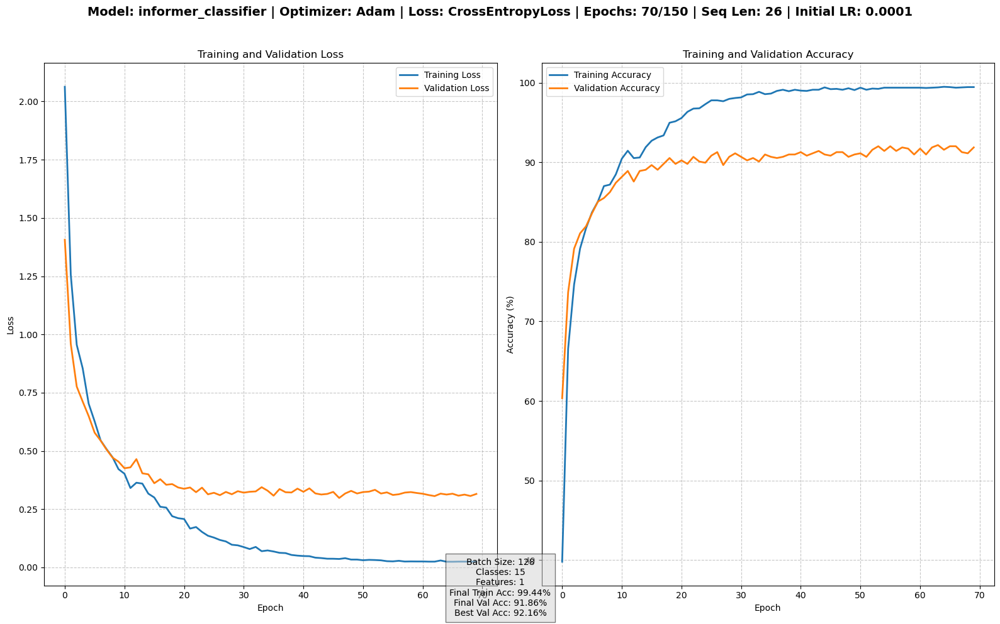

Val Accuracy: 92.01%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/informer_classifier_26_confusion_matrix.png


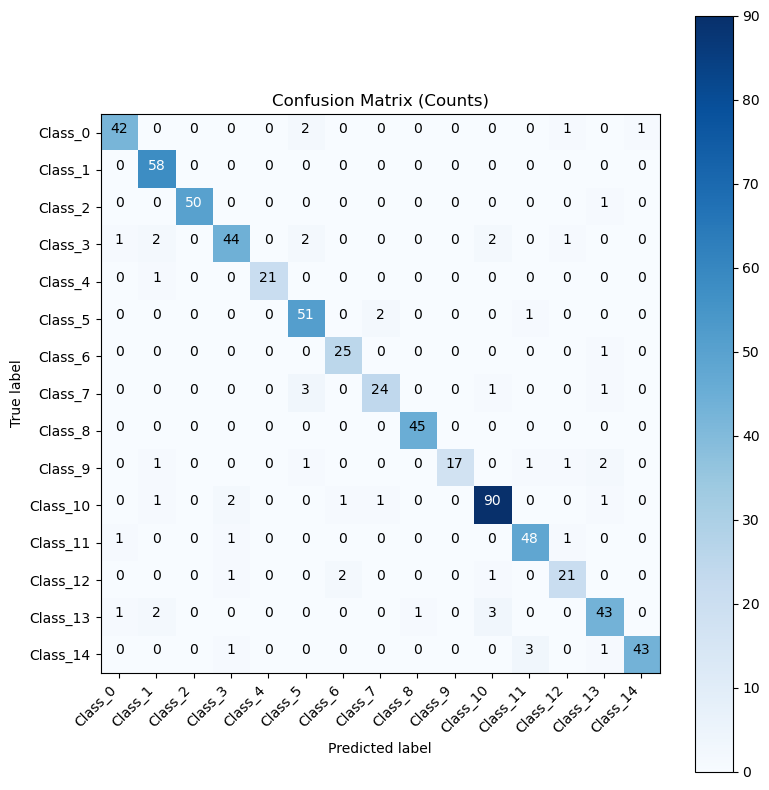

Successfully saved: checkpoints/UTMobile/informer_classifier_26_confusion_matrix_percent.png


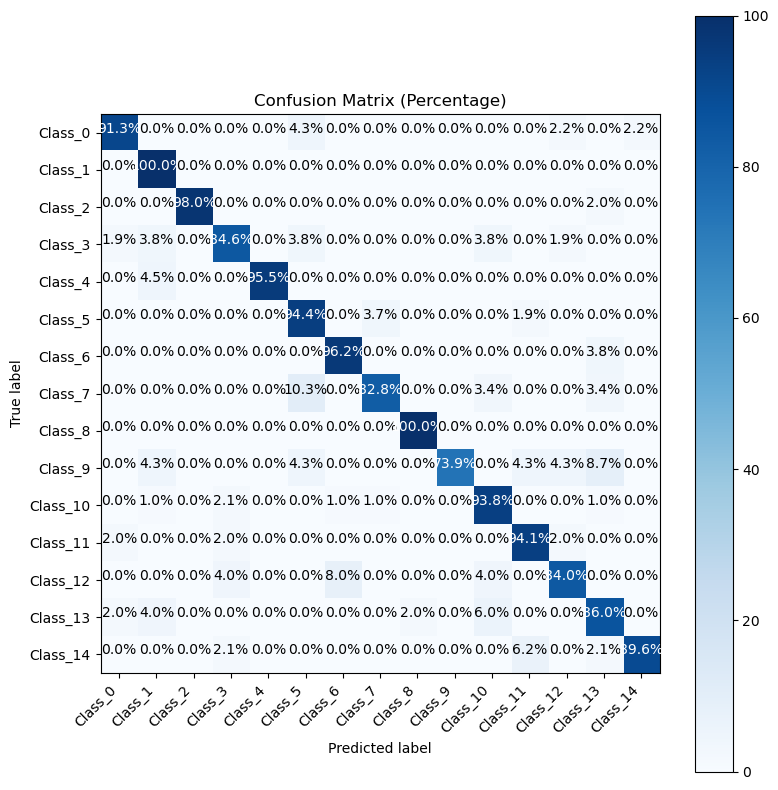


Evaluation Complete!
Total evaluation time: 0:00:00.258970

Evaluating TIMESNET model across datasets...

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   0%|          | 0/150 [00:00<?, ?it/s]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_501_best.pth


Training:   1%|          | 1/150 [00:18<45:13, 18.21s/it, train_loss=1.6669, train_acc=49.17%, val_loss=0.9190, val_acc=75.00%, time=0:00:18]

Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.6669, Accuracy: 49.17%
Validation Loss: 0.9190, Accuracy: 75.00%
Current LR: 1.00e-04
Epoch time: 0:00:18.207297
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 33/150
Training Loss: 0.0217, Accuracy: 99.30%
Validation Loss: 0.4165, Accuracy: 91.72%
Current LR: 1.00e-07
Epoch time: 0:00:18.202751
----------------------------------------


Training:  23%|██▎       | 34/150 [10:22<35:11, 18.20s/it, train_loss=0.0321, train_acc=99.33%, val_loss=0.4165, val_acc=91.72%, time=0:00:18]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 34/150
Training Loss: 0.0321, Accuracy: 99.33%
Validation Loss: 0.4165, Accuracy: 91.72%
Current LR: 1.00e-07
Epoch time: 0:00:18.211587
----------------------------------------


Training:  23%|██▎       | 34/150 [10:40<36:25, 18.84s/it, train_loss=0.0219, train_acc=99.33%, val_loss=0.4165, val_acc=91.72%, time=0:00:18]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 35/150
Training Loss: 0.0219, Accuracy: 99.33%
Validation Loss: 0.4165, Accuracy: 91.72%
Current LR: 1.00e-07
Epoch time: 0:00:18.222500
----------------------------------------
Early stopping triggered after 35 epochs

Training Complete!
Total training time: 0:10:40.668561

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e35_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc92.0.png
Successfully saved metrics plot


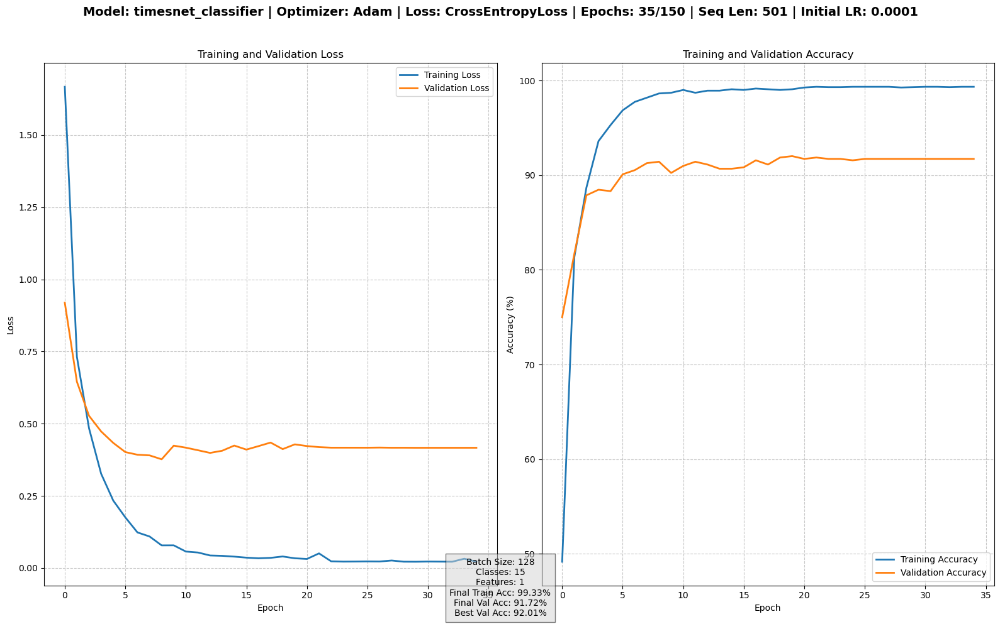

Val Accuracy: 91.72%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_501_confusion_matrix.png


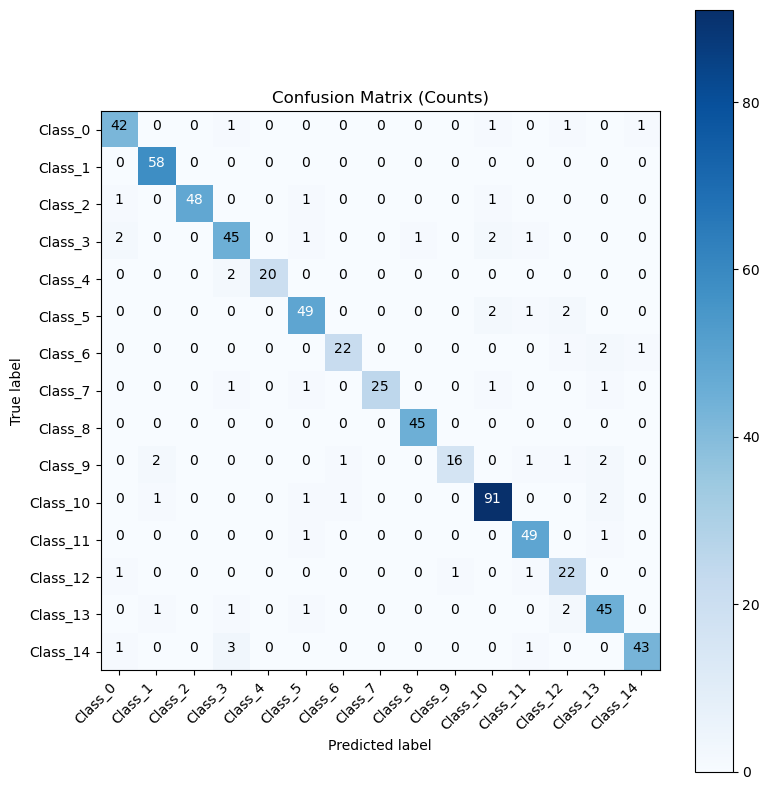

Successfully saved: checkpoints/UTMobile/timesnet_classifier_501_confusion_matrix_percent.png


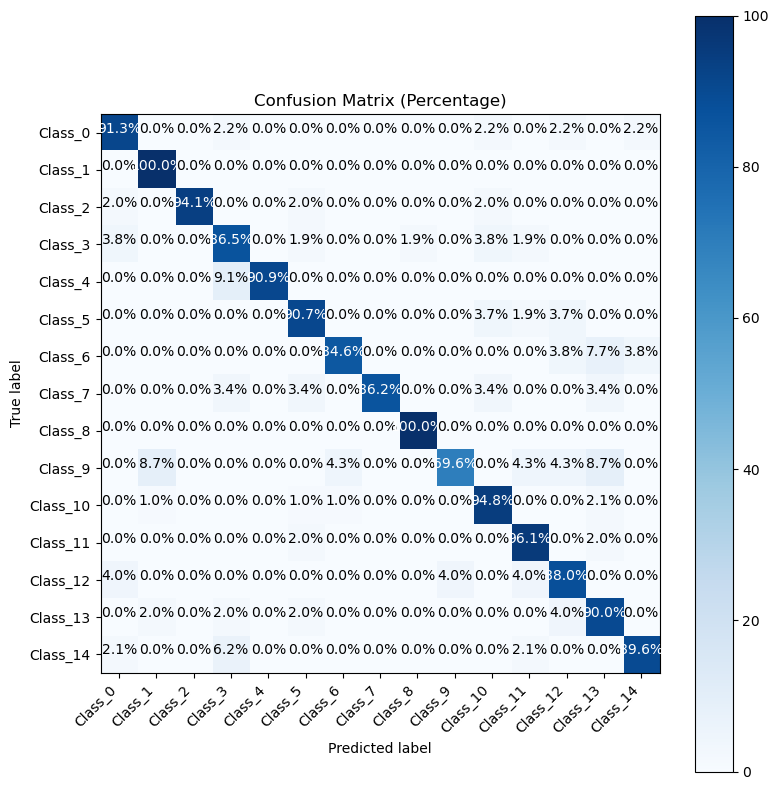


Evaluation Complete!
Total evaluation time: 0:00:01.054293

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   0%|          | 0/150 [00:00<?, ?it/s]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_251_best.pth


Training:   1%|          | 1/150 [00:10<27:06, 10.91s/it, train_loss=1.8536, train_acc=45.06%, val_loss=1.1030, val_acc=68.79%, time=0:00:10]

Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.8536, Accuracy: 45.06%
Validation Loss: 1.1030, Accuracy: 68.79%
Current LR: 1.00e-04
Epoch time: 0:00:10.913018
----------------------------------------


...

EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 44/150
Training Loss: 0.0203, Accuracy: 99.41%
Validation Loss: 0.3597, Accuracy: 92.31%
Current LR: 1.00e-07
Epoch time: 0:00:10.542876
----------------------------------------


Training:  30%|███       | 45/150 [07:57<18:26, 10.54s/it, train_loss=0.0366, train_acc=99.30%, val_loss=0.3598, val_acc=92.31%, time=0:00:10]

ReduceLROnPlateau counter: 1 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 45/150
Training Loss: 0.0366, Accuracy: 99.30%
Validation Loss: 0.3598, Accuracy: 92.31%
Current LR: 1.00e-07
Epoch time: 0:00:10.575855
----------------------------------------


Training:  30%|███       | 45/150 [08:08<18:59, 10.85s/it, train_loss=0.0204, train_acc=99.33%, val_loss=0.3599, val_acc=92.31%, time=0:00:10]


ReduceLROnPlateau counter: 2 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 46/150
Training Loss: 0.0204, Accuracy: 99.33%
Validation Loss: 0.3599, Accuracy: 92.31%
Current LR: 1.00e-07
Epoch time: 0:00:10.523067
----------------------------------------
Early stopping triggered after 46 epochs

Training Complete!
Total training time: 0:08:08.257284

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e46_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc92.5.png
Successfully saved metrics plot


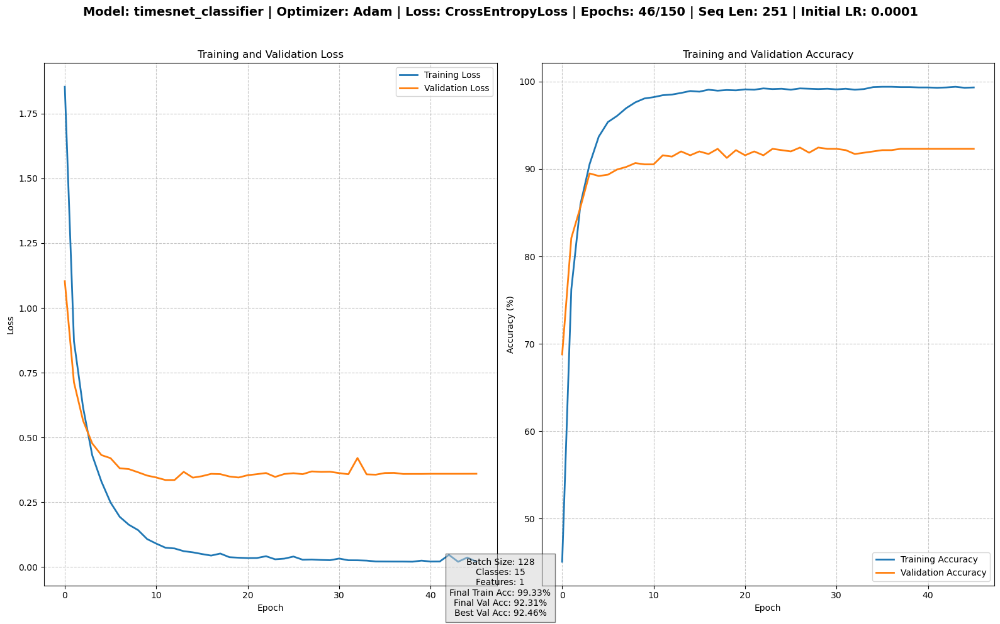

Val Accuracy: 92.31%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_251_confusion_matrix.png


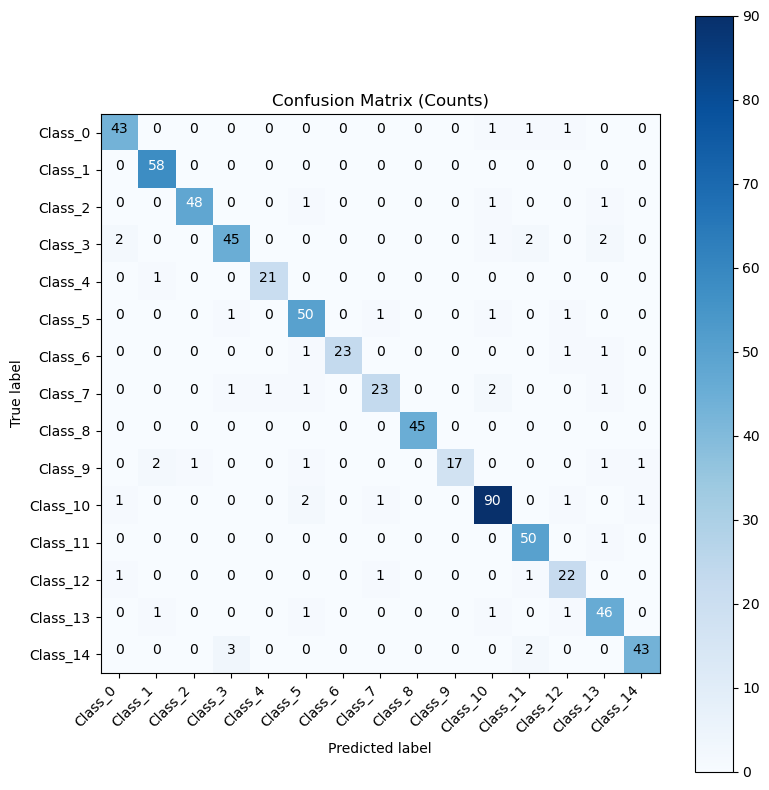

Successfully saved: checkpoints/UTMobile/timesnet_classifier_251_confusion_matrix_percent.png


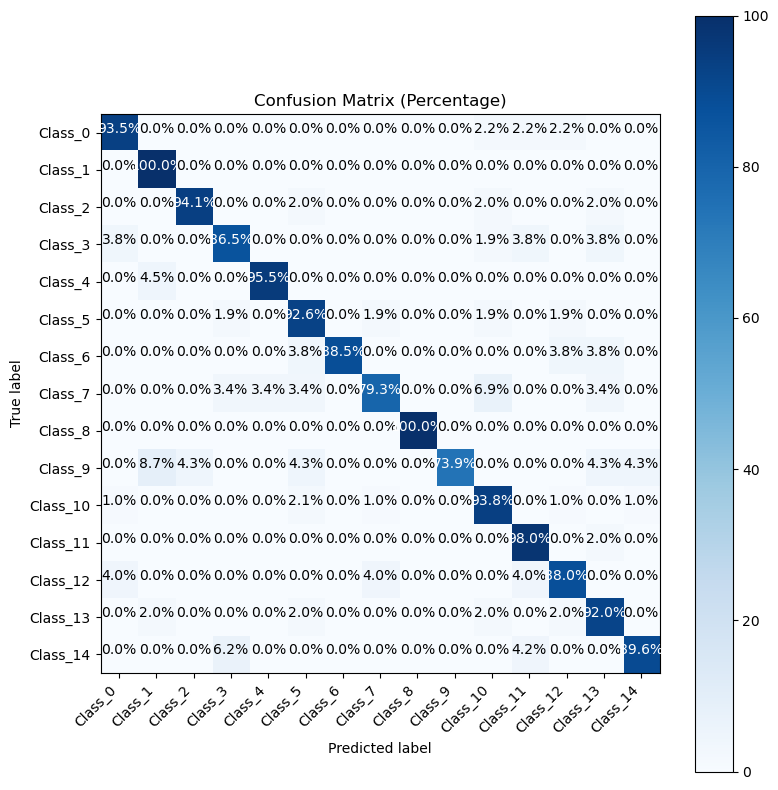


Evaluation Complete!
Total evaluation time: 0:00:00.694698

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:07<18:09,  7.31s/it, train_loss=1.9448, train_acc=42.85%, val_loss=1.2371, val_acc=66.12%, time=0:00:07]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.9448, Accuracy: 42.85%
Validation Loss: 1.2371, Accuracy: 66.12%
Current LR: 1.00e-04
Epoch time: 0:00:07.307722
----------------------------------------


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_167_best.pth


Training:   1%|▏         | 2/150 [00:15<18:35,  7.54s/it, train_loss=1.0119, train_acc=74.19%, val_loss=0.8136, val_acc=78.70%, time=0:00:07]

...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 44/150
Training Loss: 0.0242, Accuracy: 99.26%
Validation Loss: 0.2869, Accuracy: 92.75%
Current LR: 1.00e-07
Epoch time: 0:00:07.089115
----------------------------------------


Training:  30%|███       | 45/150 [05:24<12:25,  7.10s/it, train_loss=0.0250, train_acc=99.33%, val_loss=0.2870, val_acc=92.75%, time=0:00:07]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 45/150
Training Loss: 0.0250, Accuracy: 99.33%
Validation Loss: 0.2870, Accuracy: 92.75%
Current LR: 1.00e-07
Epoch time: 0:00:07.114184
----------------------------------------


Training:  30%|███       | 45/150 [05:31<12:53,  7.36s/it, train_loss=0.0253, train_acc=99.30%, val_loss=0.2870, val_acc=92.75%, time=0:00:07]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 46/150
Training Loss: 0.0253, Accuracy: 99.30%
Validation Loss: 0.2870, Accuracy: 92.75%
Current LR: 1.00e-07
Epoch time: 0:00:07.094095
----------------------------------------
Early stopping triggered after 46 epochs

Training Complete!
Total training time: 0:05:31.346374

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e46_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc92.8.png
Successfully saved metrics plot


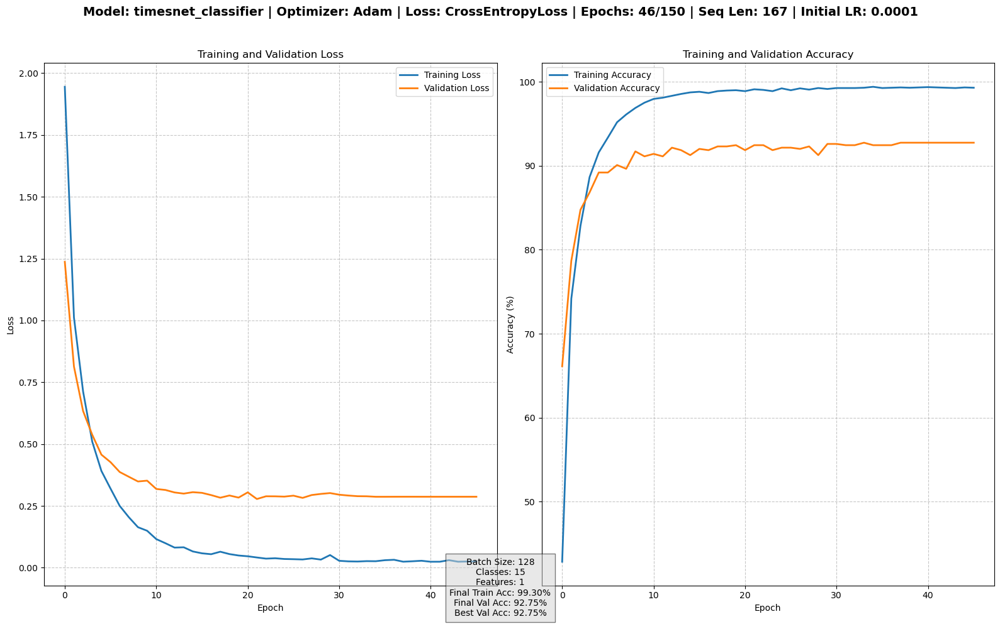

Val Accuracy: 92.75%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_167_confusion_matrix.png


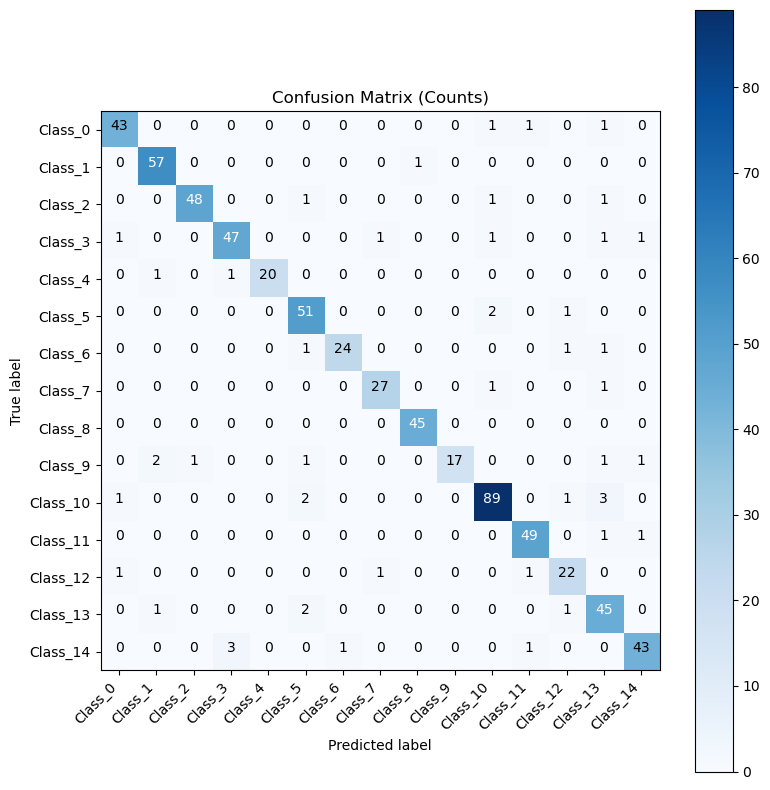

Successfully saved: checkpoints/UTMobile/timesnet_classifier_167_confusion_matrix_percent.png


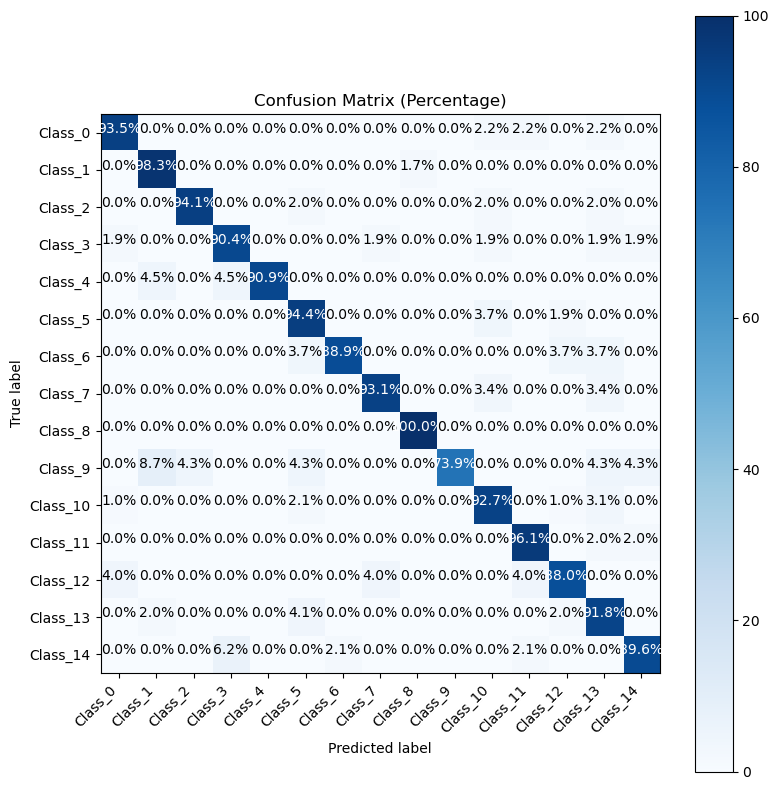


Evaluation Complete!
Total evaluation time: 0:00:00.587199

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:05<13:35,  5.47s/it, train_loss=1.9841, train_acc=42.06%, val_loss=1.3288, val_acc=62.72%, time=0:00:05]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.9841, Accuracy: 42.06%
Validation Loss: 1.3288, Accuracy: 62.72%
Current LR: 1.00e-04
Epoch time: 0:00:05.472054
----------------------------------------


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_126_best.pth


Training:   1%|▏         | 2/150 [00:10<13:33,  5.50s/it, train_loss=1.0996, train_acc=71.75%, val_loss=0.8858, val_acc=76.92%, time=0:00:05]

...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 51/150
Training Loss: 0.0223, Accuracy: 99.37%
Validation Loss: 0.2667, Accuracy: 93.34%
Current LR: 1.00e-07
Epoch time: 0:00:04.963615
----------------------------------------


Training:  35%|███▍      | 52/150 [04:23<08:07,  4.98s/it, train_loss=0.0231, train_acc=99.33%, val_loss=0.2666, val_acc=93.34%, time=0:00:04]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 52/150
Training Loss: 0.0231, Accuracy: 99.33%
Validation Loss: 0.2666, Accuracy: 93.34%
Current LR: 1.00e-07
Epoch time: 0:00:04.968326
----------------------------------------


Training:  35%|███▍      | 52/150 [04:28<08:26,  5.17s/it, train_loss=0.0225, train_acc=99.33%, val_loss=0.2666, val_acc=93.34%, time=0:00:04]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 53/150
Training Loss: 0.0225, Accuracy: 99.33%
Validation Loss: 0.2666, Accuracy: 93.34%
Current LR: 1.00e-07
Epoch time: 0:00:04.962507
----------------------------------------
Early stopping triggered after 53 epochs

Training Complete!
Total training time: 0:04:28.688343

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e53_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc93.5.png
Successfully saved metrics plot


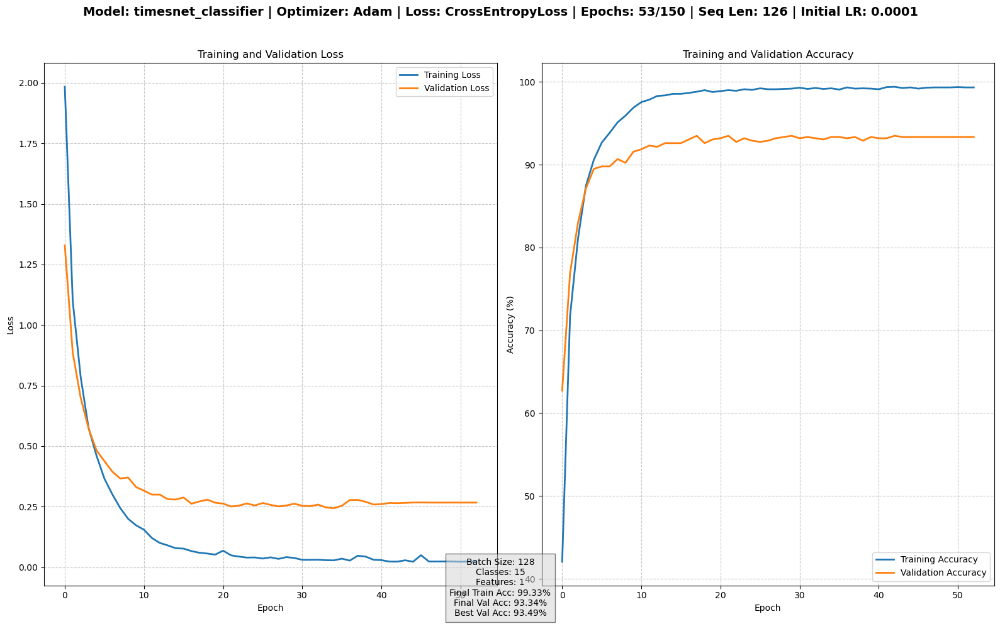

Val Accuracy: 93.34%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_126_confusion_matrix.png


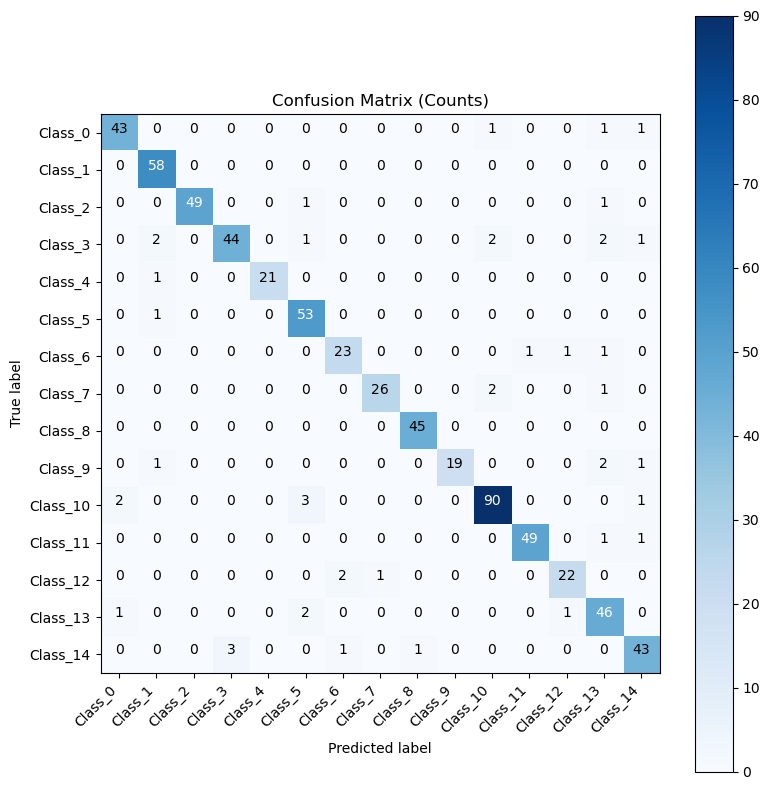

Successfully saved: checkpoints/UTMobile/timesnet_classifier_126_confusion_matrix_percent.png


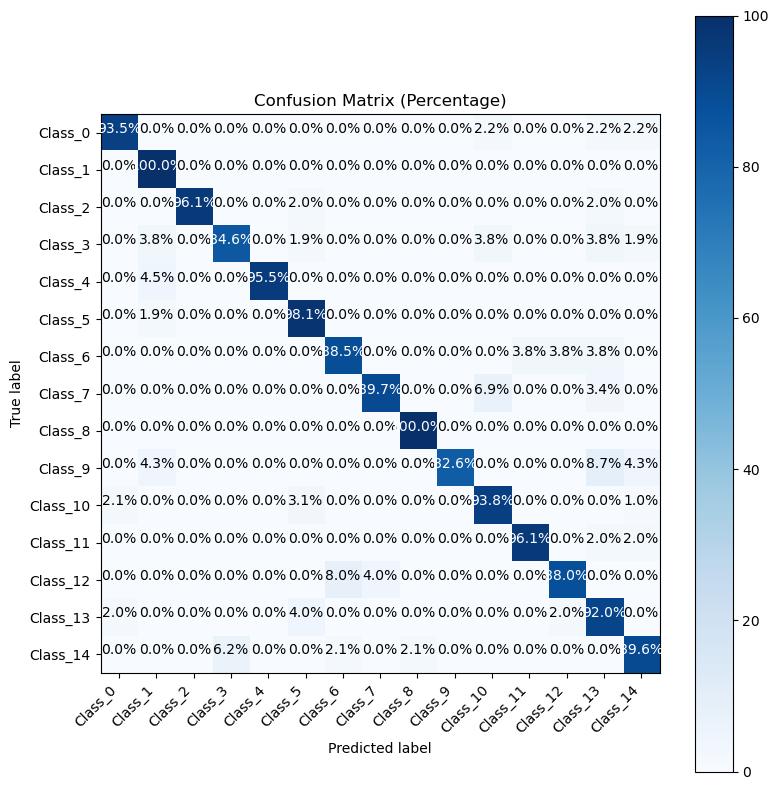


Evaluation Complete!
Total evaluation time: 0:00:00.494145

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:03<09:25,  3.80s/it, train_loss=2.1512, train_acc=37.96%, val_loss=1.5844, val_acc=58.88%, time=0:00:03]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.1512, Accuracy: 37.96%
Validation Loss: 1.5844, Accuracy: 58.88%
Current LR: 1.00e-04
Epoch time: 0:00:03.794831
----------------------------------------


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_67_best.pth


Training:   1%|▏         | 2/150 [00:07<09:11,  3.73s/it, train_loss=1.3342, train_acc=63.37%, val_loss=1.0921, val_acc=71.30%, time=0:00:03]

...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 49/150
Training Loss: 0.0360, Accuracy: 99.26%
Validation Loss: 0.2201, Accuracy: 93.93%
Current LR: 1.00e-07
Epoch time: 0:00:03.289587
----------------------------------------


Training:  33%|███▎      | 50/150 [02:55<05:38,  3.39s/it, train_loss=0.0337, train_acc=99.37%, val_loss=0.2202, val_acc=93.93%, time=0:00:03]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 50/150
Training Loss: 0.0337, Accuracy: 99.37%
Validation Loss: 0.2202, Accuracy: 93.93%
Current LR: 1.00e-07
Epoch time: 0:00:03.419698
----------------------------------------


Training:  33%|███▎      | 50/150 [02:58<05:57,  3.58s/it, train_loss=0.0367, train_acc=99.22%, val_loss=0.2202, val_acc=93.93%, time=0:00:03]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 51/150
Training Loss: 0.0367, Accuracy: 99.22%
Validation Loss: 0.2202, Accuracy: 93.93%
Current LR: 1.00e-07
Epoch time: 0:00:03.428803
----------------------------------------
Early stopping triggered after 51 epochs

Training Complete!
Total training time: 0:02:58.851632

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e51_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc94.1.png
Successfully saved metrics plot


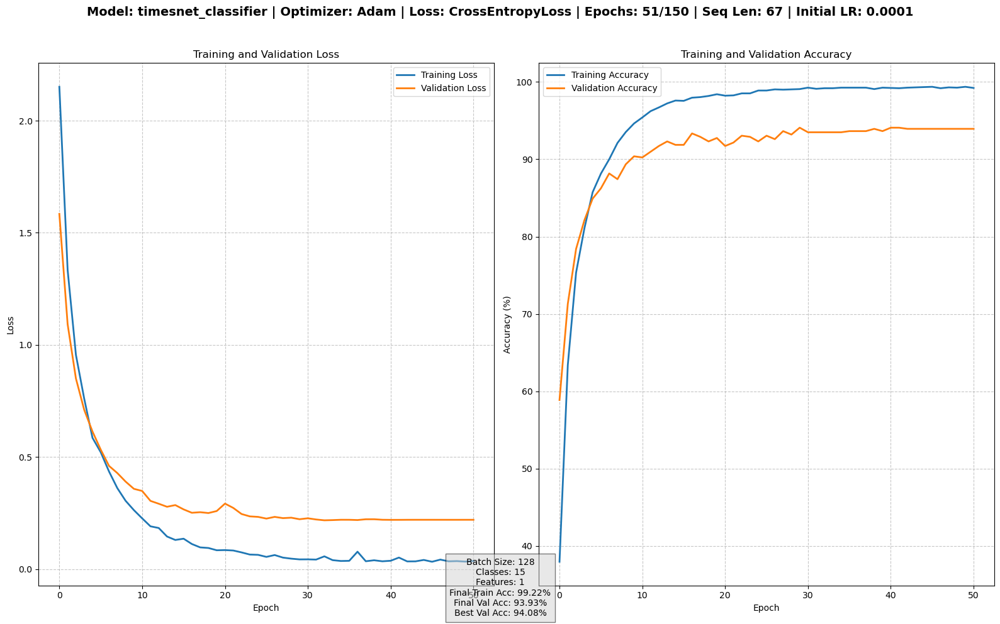

Val Accuracy: 93.93%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_67_confusion_matrix.png


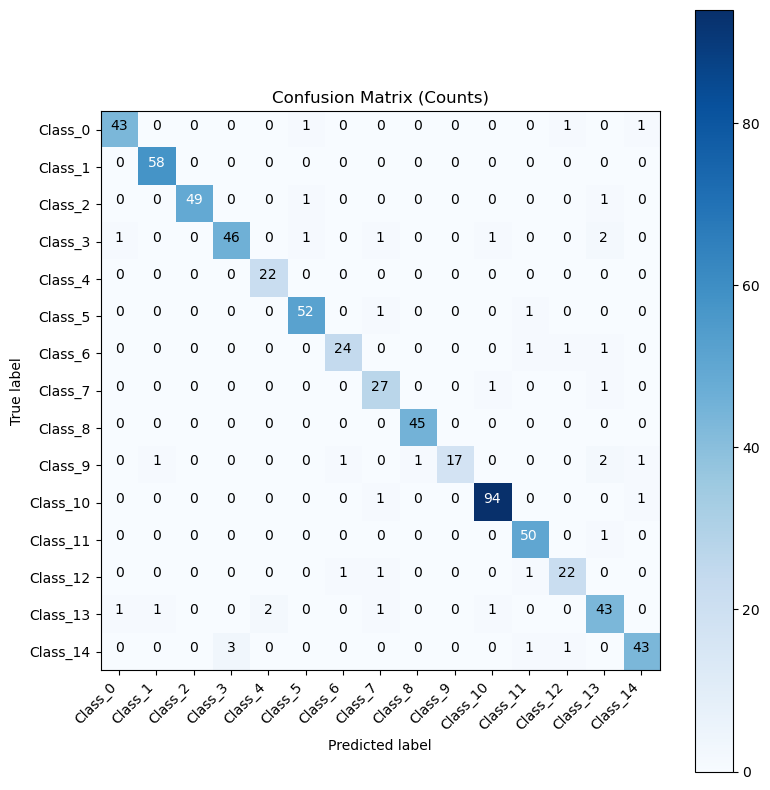

Successfully saved: checkpoints/UTMobile/timesnet_classifier_67_confusion_matrix_percent.png


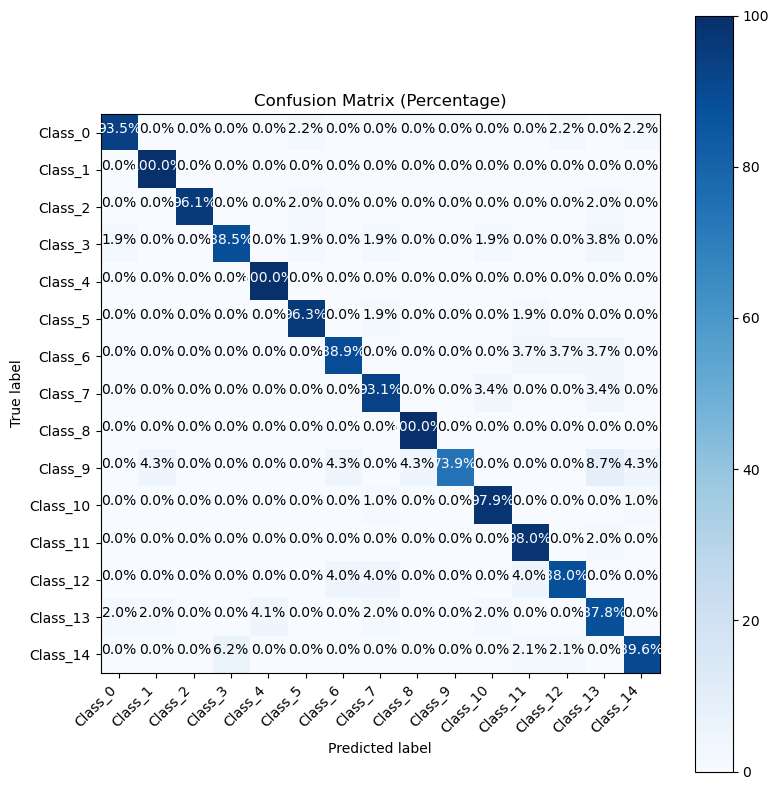


Evaluation Complete!
Total evaluation time: 0:00:00.418700

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:02<06:24,  2.58s/it, train_loss=2.2728, train_acc=32.25%, val_loss=1.7602, val_acc=55.33%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.2728, Accuracy: 32.25%
Validation Loss: 1.7602, Accuracy: 55.33%
Current LR: 1.00e-04
Epoch time: 0:00:02.579093
----------------------------------------


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timesnet_classifier_26_best.pth


Training:   1%|▏         | 2/150 [00:05<06:18,  2.56s/it, train_loss=1.5492, train_acc=58.35%, val_loss=1.2869, val_acc=65.24%, time=0:00:02]

...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 67/150
Training Loss: 0.0424, Accuracy: 99.11%
Validation Loss: 0.3456, Accuracy: 91.27%
Current LR: 1.00e-07
Epoch time: 0:00:01.972206
----------------------------------------


Training:  45%|████▌     | 68/150 [02:24<02:44,  2.00s/it, train_loss=0.0402, train_acc=99.19%, val_loss=0.3456, val_acc=91.27%, time=0:00:02]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 68/150
Training Loss: 0.0402, Accuracy: 99.19%
Validation Loss: 0.3456, Accuracy: 91.27%
Current LR: 1.00e-07
Epoch time: 0:00:02.004945
----------------------------------------


Training:  45%|████▌     | 68/150 [02:26<02:57,  2.16s/it, train_loss=0.0475, train_acc=99.15%, val_loss=0.3456, val_acc=91.27%, time=0:00:02]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 69/150
Training Loss: 0.0475, Accuracy: 99.15%
Validation Loss: 0.3456, Accuracy: 91.27%
Current LR: 1.00e-07
Epoch time: 0:00:02.007164
----------------------------------------
Early stopping triggered after 69 epochs

Training Complete!
Total training time: 0:02:26.957717

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timesnet_classifier_e69_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc91.6.png
Successfully saved metrics plot


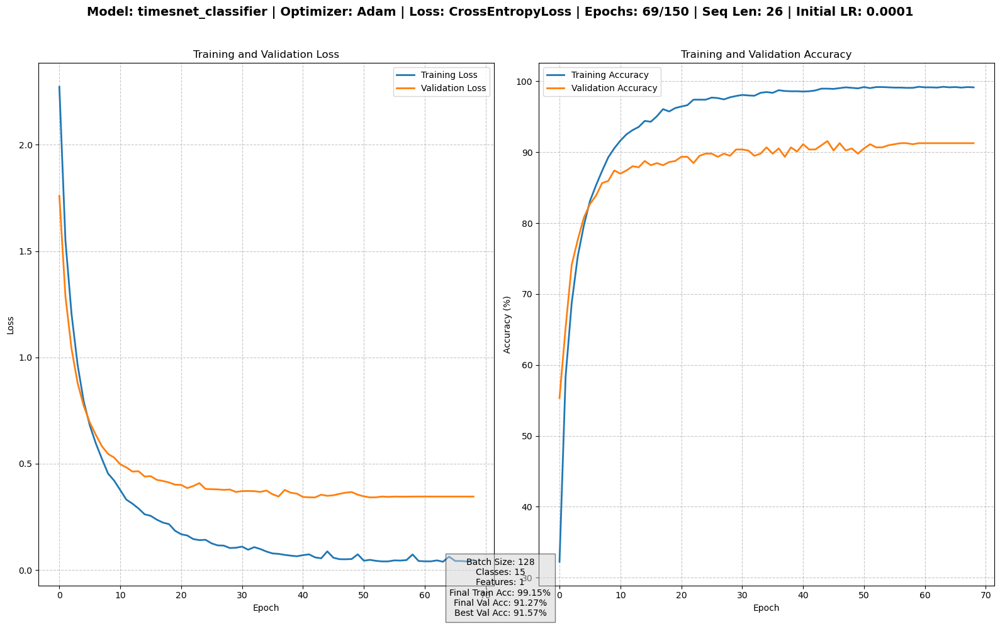

Val Accuracy: 91.27%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timesnet_classifier_26_confusion_matrix.png


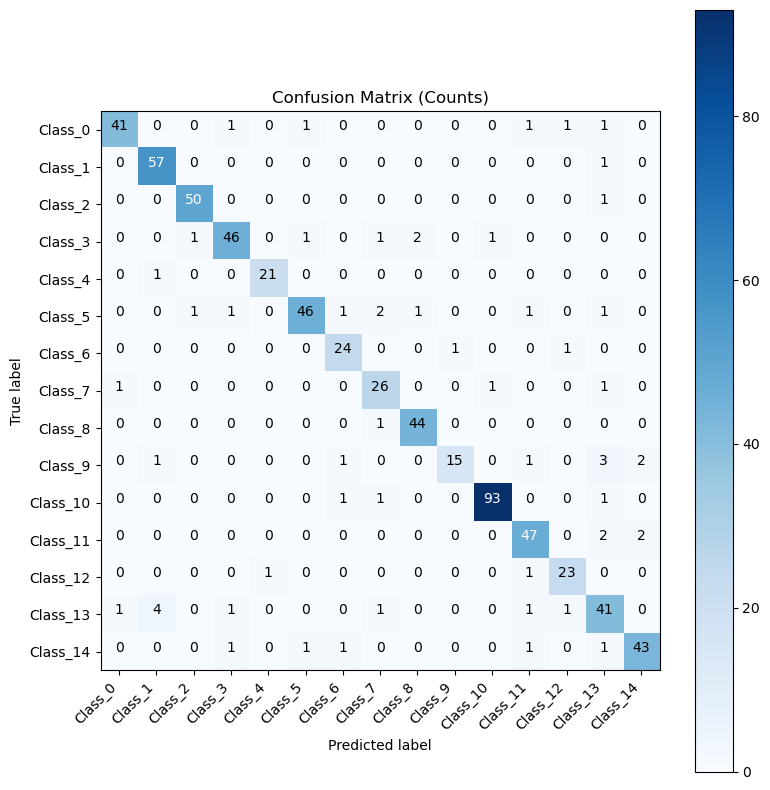

Successfully saved: checkpoints/UTMobile/timesnet_classifier_26_confusion_matrix_percent.png


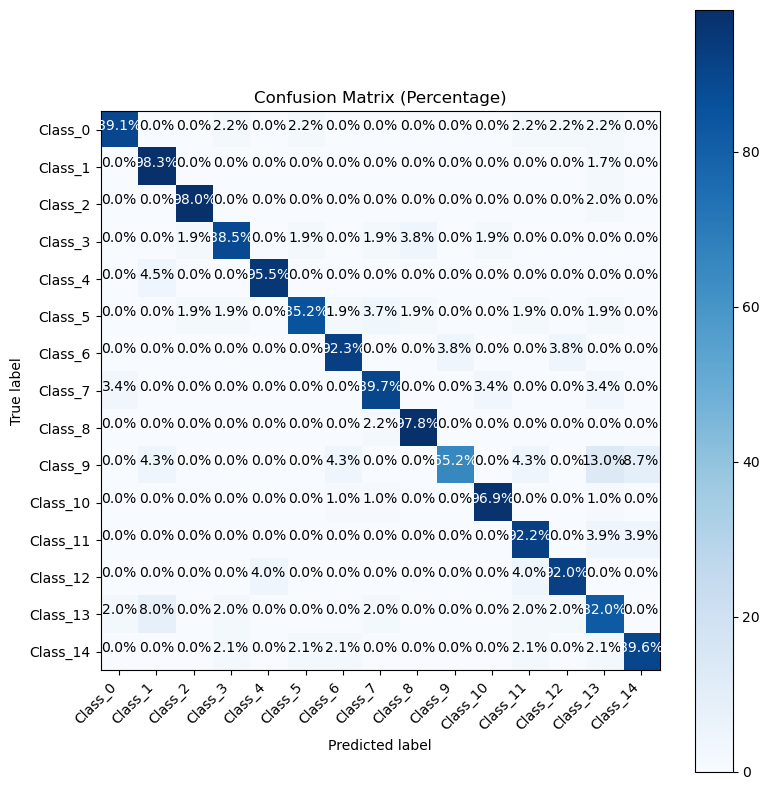


Evaluation Complete!
Total evaluation time: 0:00:00.348172

Evaluating AUTOFORMER model across datasets...

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:02<06:50,  2.76s/it, train_loss=2.2923, train_acc=29.62%, val_loss=1.7479, val_acc=48.22%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.2923, Accuracy: 29.62%
Validation Loss: 1.7479, Accuracy: 48.22%
Current LR: 1.00e-04
Epoch time: 0:00:02.754492
----------------------------------------


Training:   1%|▏         | 2/150 [00:05<06:47,  2.76s/it, train_loss=1.3523, train_acc=64.46%, val_loss=1.2710, val_acc=63.17%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.3523, Accuracy: 64.46%
Validation Loss: 1.2710, Accuracy: 63.17%
Current LR: 1.00e-04
Epoch time: 0:00:02.753056
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 51/150
Training Loss: 0.0214, Accuracy: 99.52%
Validation Loss: 0.9333, Accuracy: 75.15%
Current LR: 1.00e-07
Epoch time: 0:00:02.642107
----------------------------------------


Training:  35%|███▍      | 52/150 [02:18<04:19,  2.65s/it, train_loss=0.0229, train_acc=99.44%, val_loss=0.9343, val_acc=75.15%, time=0:00:02]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 52/150
Training Loss: 0.0229, Accuracy: 99.44%
Validation Loss: 0.9343, Accuracy: 75.15%
Current LR: 1.00e-07
Epoch time: 0:00:02.649412
----------------------------------------


Training:  35%|███▍      | 52/150 [02:20<04:25,  2.71s/it, train_loss=0.0221, train_acc=99.44%, val_loss=0.9370, val_acc=75.15%, time=0:00:02]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 53/150
Training Loss: 0.0221, Accuracy: 99.44%
Validation Loss: 0.9370, Accuracy: 75.15%
Current LR: 1.00e-07
Epoch time: 0:00:02.669421
----------------------------------------
Early stopping triggered after 53 epochs

Training Complete!
Total training time: 0:02:20.713997

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e53_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc78.6.png
Successfully saved metrics plot


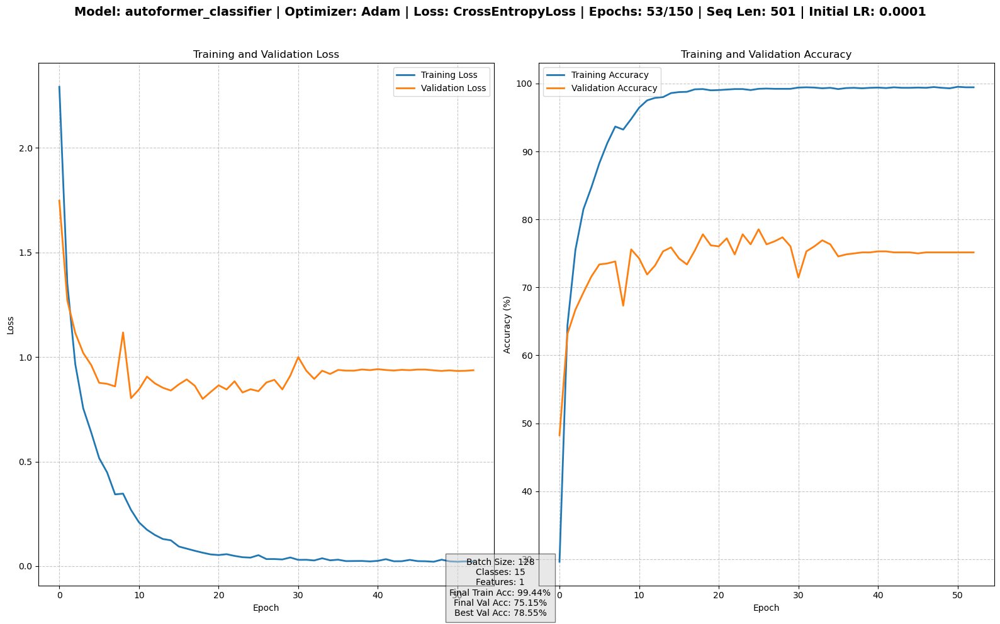

Val Accuracy: 75.15%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_501_confusion_matrix.png


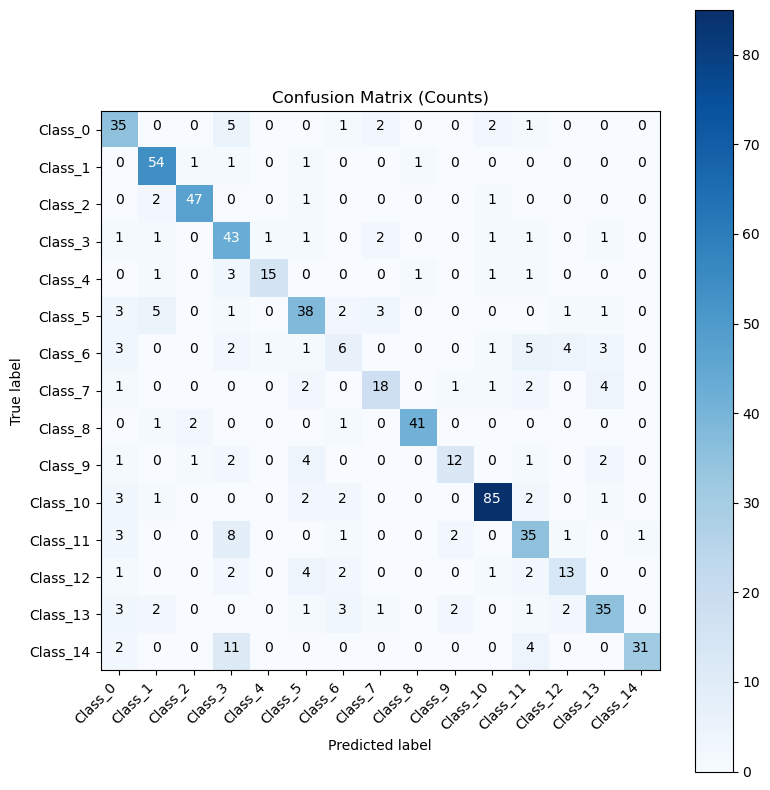

Successfully saved: checkpoints/UTMobile/autoformer_classifier_501_confusion_matrix_percent.png


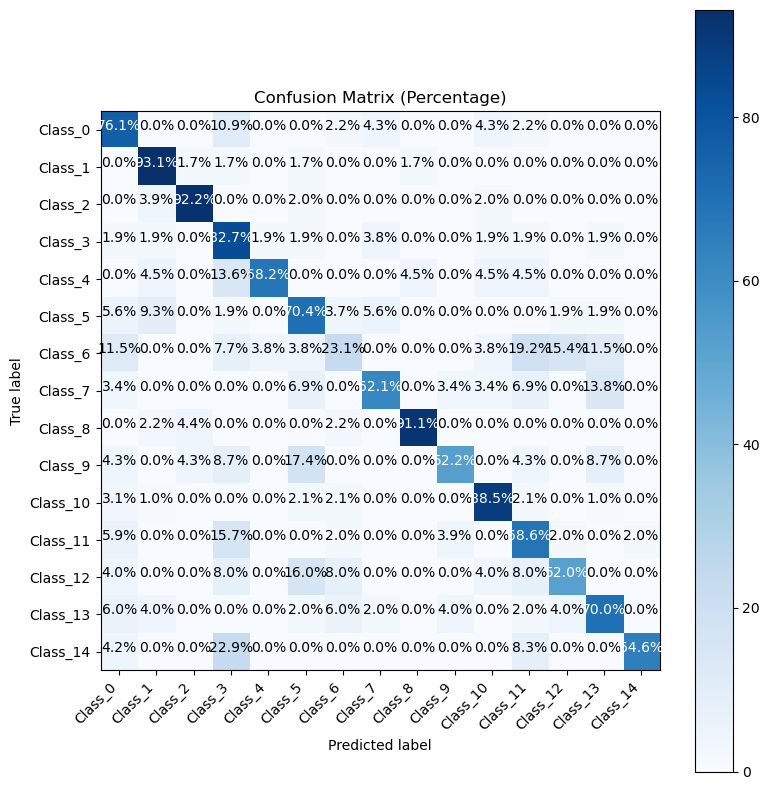


Evaluation Complete!
Total evaluation time: 0:00:00.590583

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:02<05:05,  2.05s/it, train_loss=2.3415, train_acc=27.73%, val_loss=1.9380, val_acc=45.86%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.3415, Accuracy: 27.73%
Validation Loss: 1.9380, Accuracy: 45.86%
Current LR: 1.00e-04
Epoch time: 0:00:02.047789
----------------------------------------


Training:   1%|▏         | 2/150 [00:04<05:06,  2.07s/it, train_loss=1.6801, train_acc=54.09%, val_loss=1.5309, val_acc=54.73%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.6801, Accuracy: 54.09%
Validation Loss: 1.5309, Accuracy: 54.73%
Current LR: 1.00e-04
Epoch time: 0:00:02.081717
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 60/150
Training Loss: 0.0315, Accuracy: 99.48%
Validation Loss: 0.6815, Accuracy: 78.99%
Current LR: 1.00e-07
Epoch time: 0:00:02.053529
----------------------------------------


Training:  41%|████      | 61/150 [02:06<03:04,  2.08s/it, train_loss=0.0327, train_acc=99.30%, val_loss=0.6811, val_acc=78.99%, time=0:00:02]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 61/150
Training Loss: 0.0327, Accuracy: 99.30%
Validation Loss: 0.6811, Accuracy: 78.99%
Current LR: 1.00e-07
Epoch time: 0:00:02.074514
----------------------------------------


Training:  41%|████      | 61/150 [02:08<03:07,  2.11s/it, train_loss=0.0324, train_acc=99.33%, val_loss=0.6814, val_acc=79.14%, time=0:00:02]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 62/150
Training Loss: 0.0324, Accuracy: 99.33%
Validation Loss: 0.6814, Accuracy: 79.14%
Current LR: 1.00e-07
Epoch time: 0:00:02.099995
----------------------------------------
Early stopping triggered after 62 epochs

Training Complete!
Total training time: 0:02:08.826377

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e62_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc79.6.png
Successfully saved metrics plot


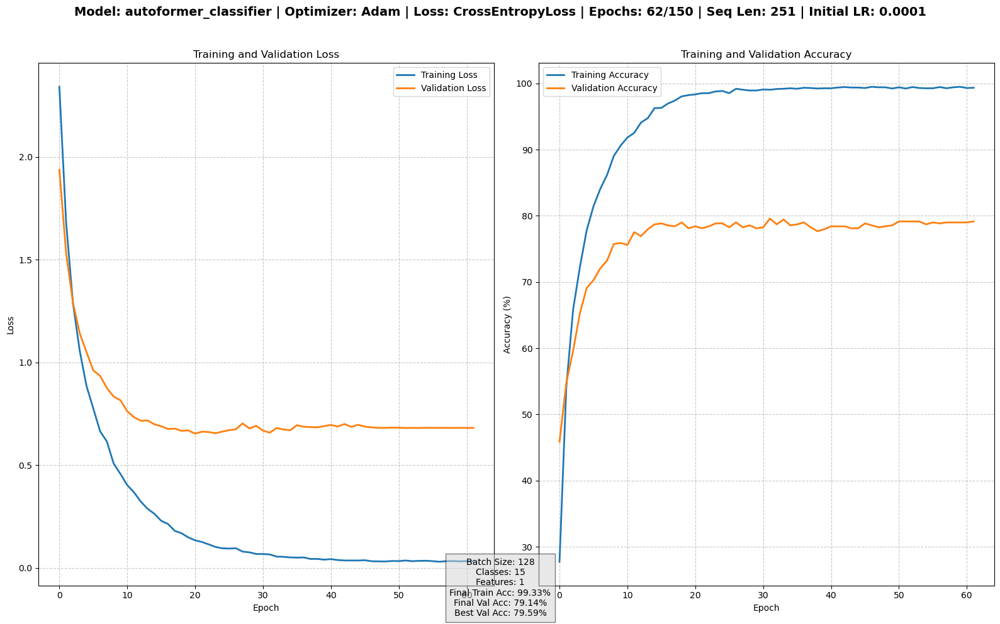

Val Accuracy: 78.85%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_251_confusion_matrix.png


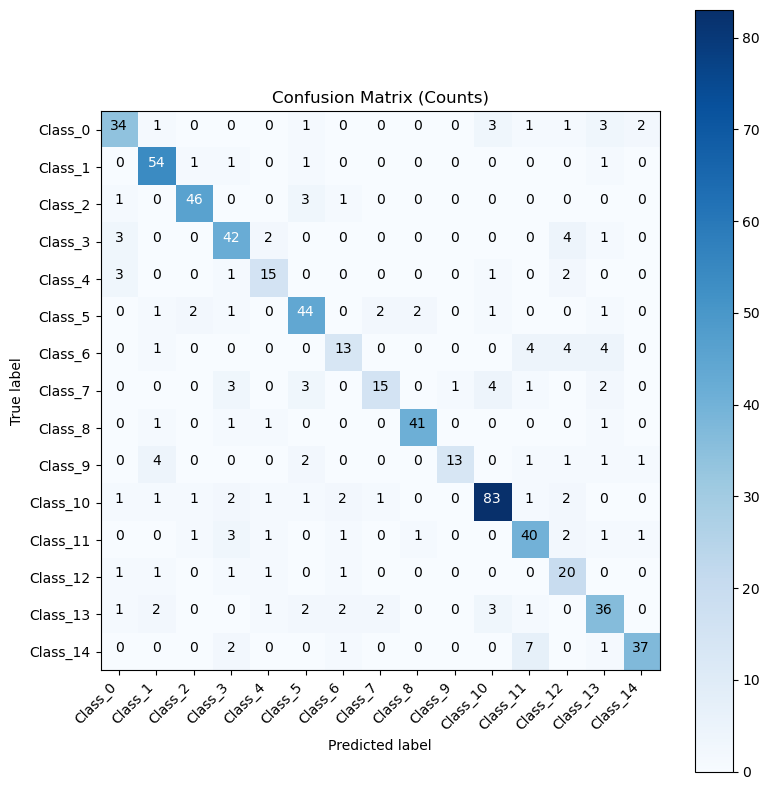

Successfully saved: checkpoints/UTMobile/autoformer_classifier_251_confusion_matrix_percent.png


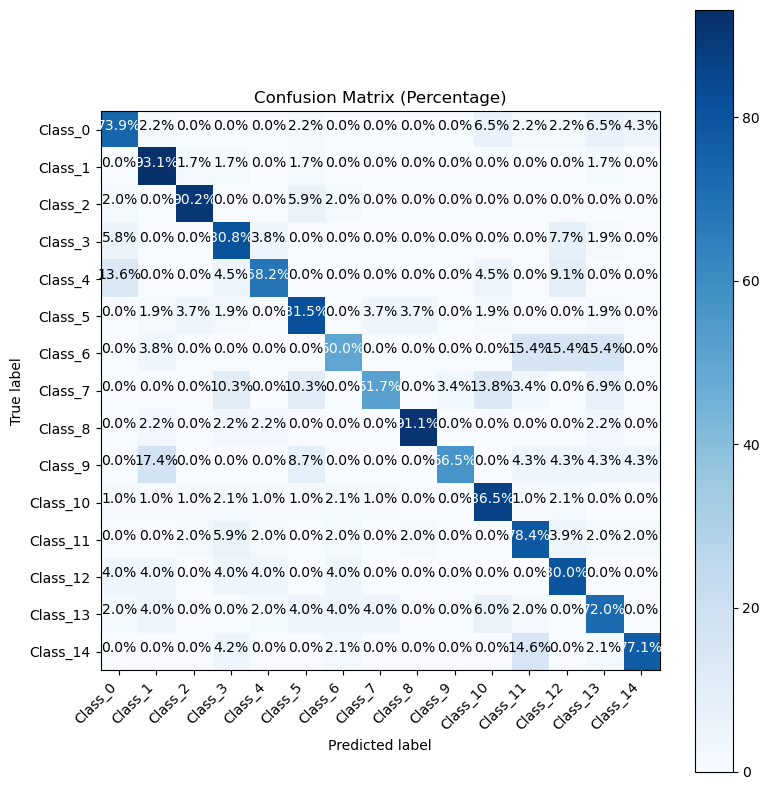


Evaluation Complete!
Total evaluation time: 0:00:00.447963

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<04:53,  1.97s/it, train_loss=2.3262, train_acc=29.19%, val_loss=1.8794, val_acc=47.63%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.3262, Accuracy: 29.19%
Validation Loss: 1.8794, Accuracy: 47.63%
Current LR: 1.00e-04
Epoch time: 0:00:01.967239
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:52,  1.98s/it, train_loss=1.7083, train_acc=53.33%, val_loss=1.5550, val_acc=55.62%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.7083, Accuracy: 53.33%
Validation Loss: 1.5550, Accuracy: 55.62%
Current LR: 1.00e-04
Epoch time: 0:00:01.979683
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 80/150
Training Loss: 0.0303, Accuracy: 99.26%
Validation Loss: 0.6372, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.978102
----------------------------------------


Training:  54%|█████▍    | 81/150 [02:40<02:16,  1.97s/it, train_loss=0.0297, train_acc=99.37%, val_loss=0.6372, val_acc=82.40%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 81/150
Training Loss: 0.0297, Accuracy: 99.37%
Validation Loss: 0.6372, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.983191
----------------------------------------


Training:  54%|█████▍    | 81/150 [02:42<02:18,  2.00s/it, train_loss=0.0286, train_acc=99.33%, val_loss=0.6372, val_acc=82.40%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 82/150
Training Loss: 0.0286, Accuracy: 99.33%
Validation Loss: 0.6372, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.972349
----------------------------------------
Early stopping triggered after 82 epochs

Training Complete!
Total training time: 0:02:42.030864

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e82_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc83.1.png
Successfully saved metrics plot


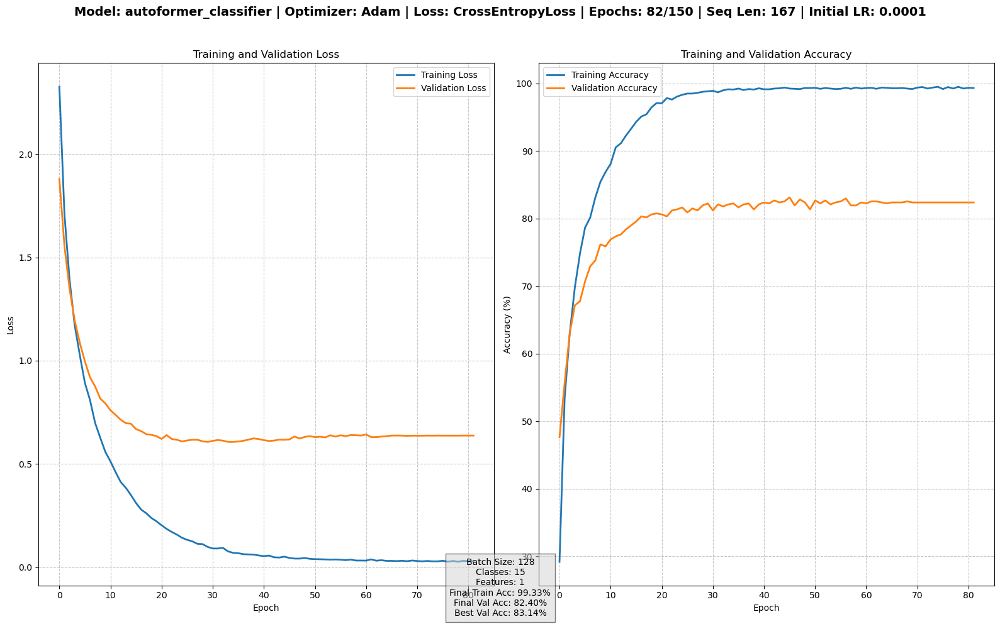

Val Accuracy: 82.40%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_167_confusion_matrix.png


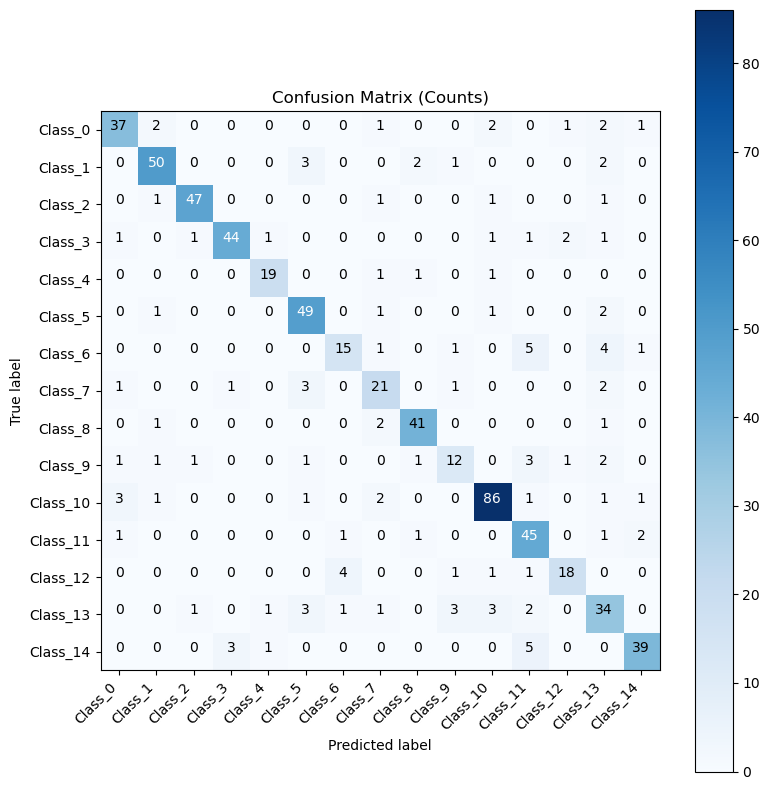

Successfully saved: checkpoints/UTMobile/autoformer_classifier_167_confusion_matrix_percent.png


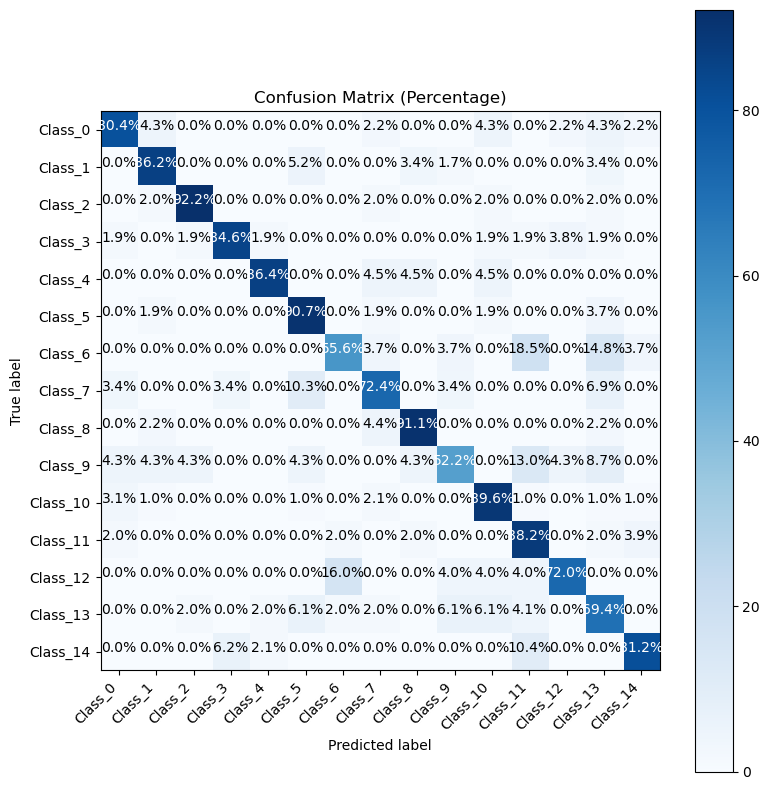


Evaluation Complete!
Total evaluation time: 0:00:00.401343

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<04:35,  1.85s/it, train_loss=2.3915, train_acc=25.81%, val_loss=1.9792, val_acc=42.46%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.3915, Accuracy: 25.81%
Validation Loss: 1.9792, Accuracy: 42.46%
Current LR: 1.00e-04
Epoch time: 0:00:01.848801
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:37,  1.88s/it, train_loss=1.8735, train_acc=47.02%, val_loss=1.6101, val_acc=55.62%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.8735, Accuracy: 47.02%
Validation Loss: 1.6101, Accuracy: 55.62%
Current LR: 1.00e-04
Epoch time: 0:00:01.895128
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 84/150
Training Loss: 0.0412, Accuracy: 99.41%
Validation Loss: 0.6866, Accuracy: 81.66%
Current LR: 1.00e-07
Epoch time: 0:00:01.890003
----------------------------------------


Training:  57%|█████▋    | 85/150 [02:41<02:03,  1.90s/it, train_loss=0.0436, train_acc=99.33%, val_loss=0.6870, val_acc=81.66%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 85/150
Training Loss: 0.0436, Accuracy: 99.33%
Validation Loss: 0.6870, Accuracy: 81.66%
Current LR: 1.00e-07
Epoch time: 0:00:01.880839
----------------------------------------


Training:  57%|█████▋    | 85/150 [02:43<02:05,  1.93s/it, train_loss=0.0431, train_acc=99.22%, val_loss=0.6890, val_acc=81.66%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 86/150
Training Loss: 0.0431, Accuracy: 99.22%
Validation Loss: 0.6890, Accuracy: 81.66%
Current LR: 1.00e-07
Epoch time: 0:00:01.876247
----------------------------------------
Early stopping triggered after 86 epochs

Training Complete!
Total training time: 0:02:43.684873

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e86_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc81.7.png
Successfully saved metrics plot


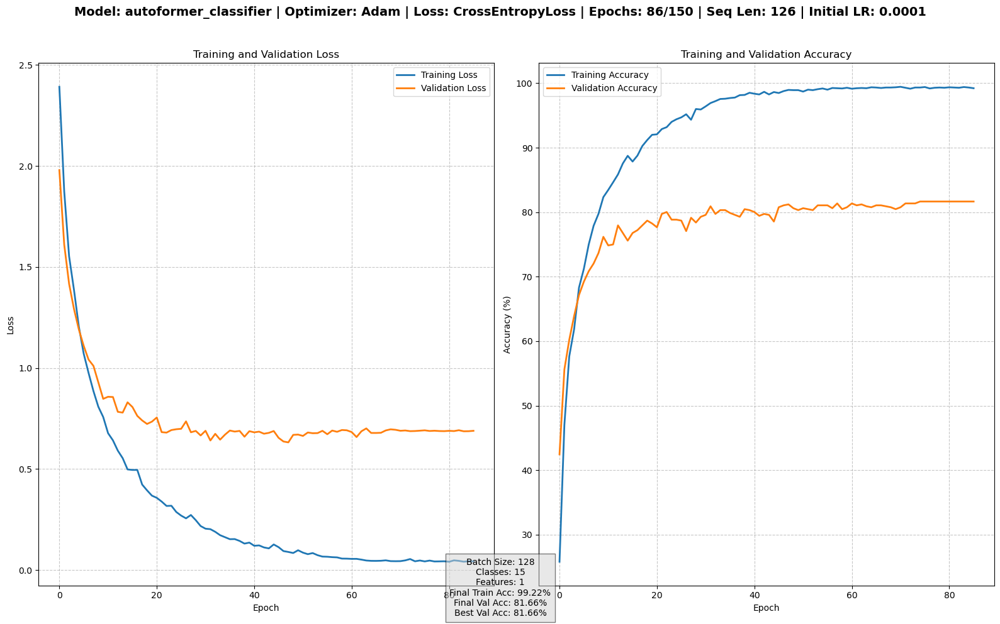

Val Accuracy: 81.66%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_126_confusion_matrix.png


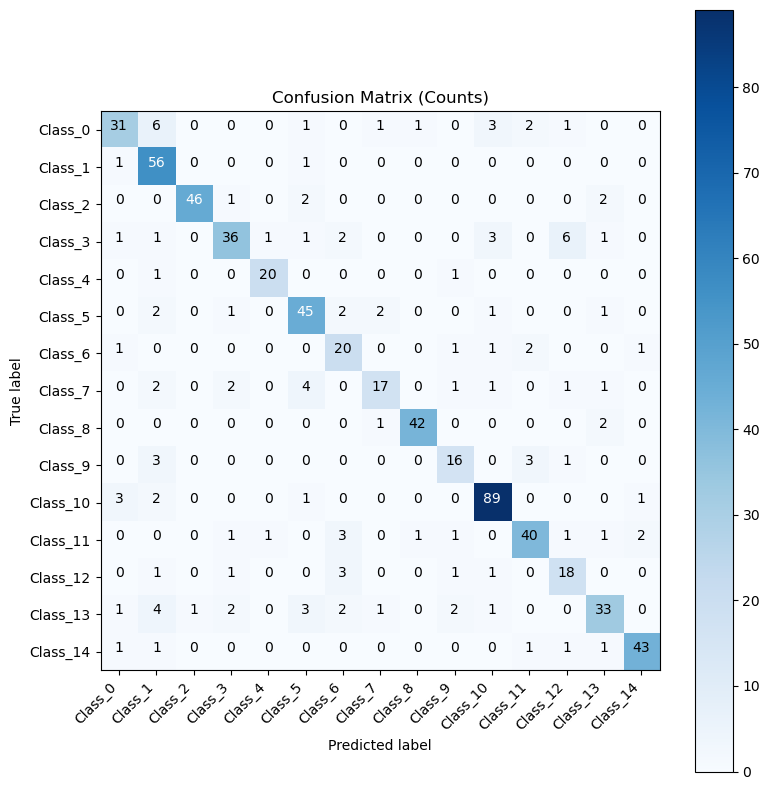

Successfully saved: checkpoints/UTMobile/autoformer_classifier_126_confusion_matrix_percent.png


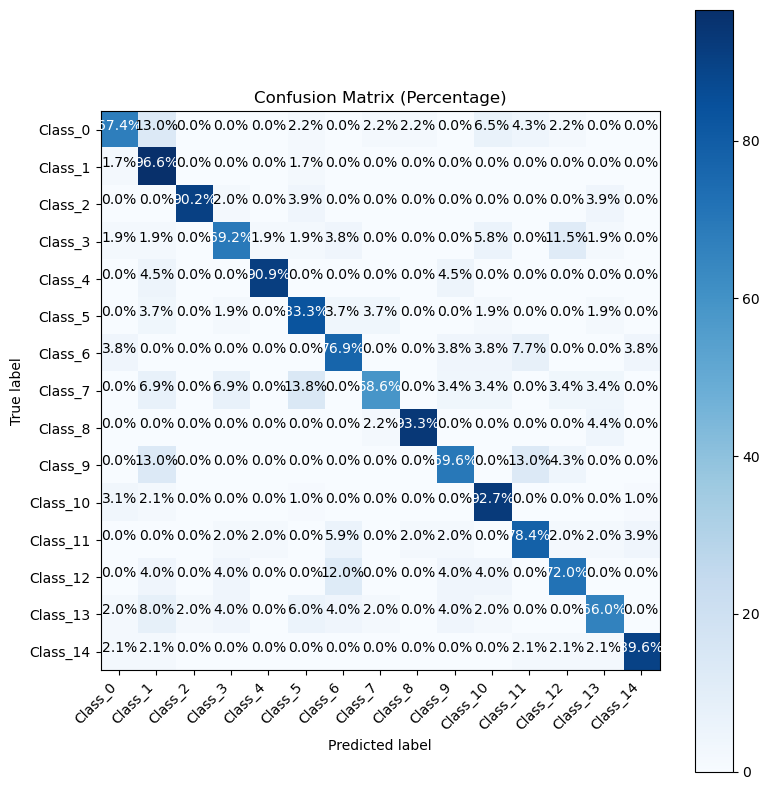


Evaluation Complete!
Total evaluation time: 0:00:00.367675

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<04:27,  1.79s/it, train_loss=2.4062, train_acc=27.85%, val_loss=1.9605, val_acc=45.41%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.4062, Accuracy: 27.85%
Validation Loss: 1.9605, Accuracy: 45.41%
Current LR: 1.00e-04
Epoch time: 0:00:01.793043
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:34,  1.86s/it, train_loss=1.8696, train_acc=48.96%, val_loss=1.6070, val_acc=55.47%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.8696, Accuracy: 48.96%
Validation Loss: 1.6070, Accuracy: 55.47%
Current LR: 1.00e-04
Epoch time: 0:00:01.895187
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 122/150
Training Loss: 0.0592, Accuracy: 99.15%
Validation Loss: 0.6551, Accuracy: 84.02%
Current LR: 1.00e-07
Epoch time: 0:00:01.816159
----------------------------------------


Training:  82%|████████▏ | 123/150 [03:43<00:48,  1.81s/it, train_loss=0.0532, train_acc=99.22%, val_loss=0.6551, val_acc=84.02%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 123/150
Training Loss: 0.0532, Accuracy: 99.22%
Validation Loss: 0.6551, Accuracy: 84.02%
Current LR: 1.00e-07
Epoch time: 0:00:01.801963
----------------------------------------


Training:  82%|████████▏ | 123/150 [03:45<00:49,  1.83s/it, train_loss=0.0639, train_acc=99.30%, val_loss=0.6551, val_acc=84.02%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 124/150
Training Loss: 0.0639, Accuracy: 99.30%
Validation Loss: 0.6551, Accuracy: 84.02%
Current LR: 1.00e-07
Epoch time: 0:00:01.852126
----------------------------------------
Early stopping triggered after 124 epochs

Training Complete!
Total training time: 0:03:45.535394

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e124_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc85.1.png
Successfully saved metrics plot


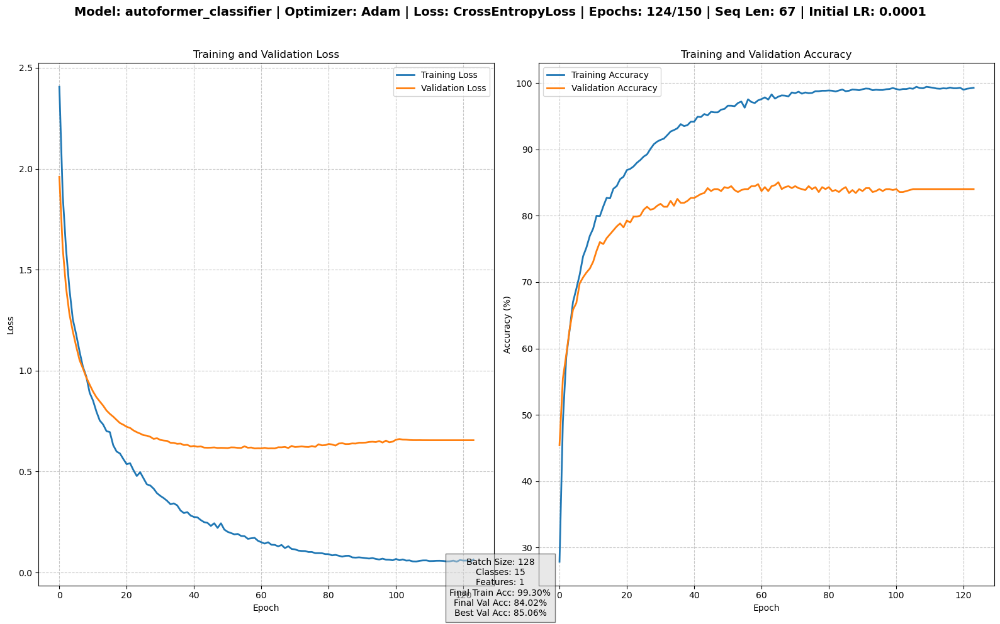

Val Accuracy: 84.02%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_67_confusion_matrix.png


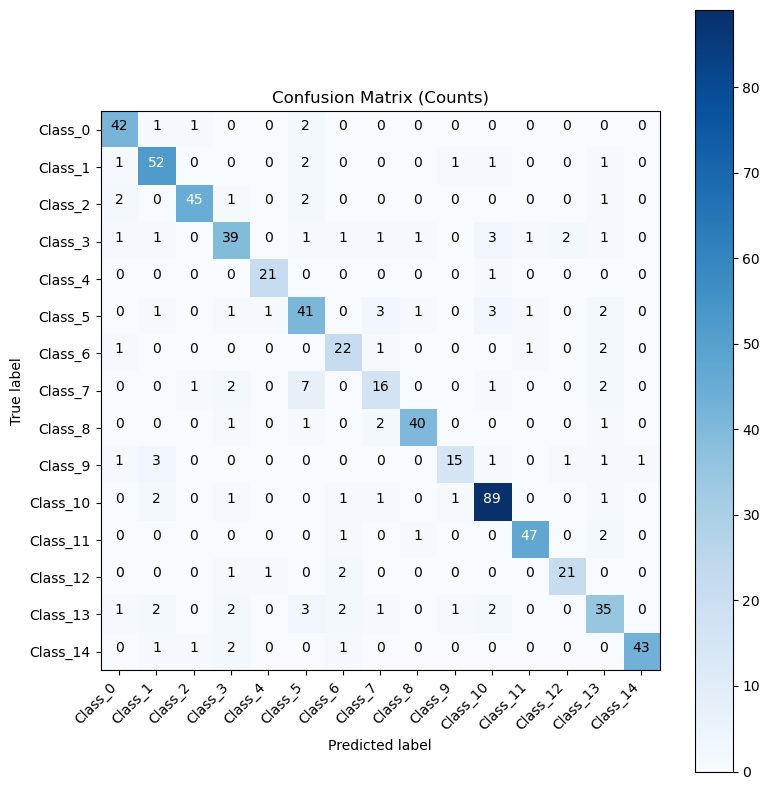

Successfully saved: checkpoints/UTMobile/autoformer_classifier_67_confusion_matrix_percent.png


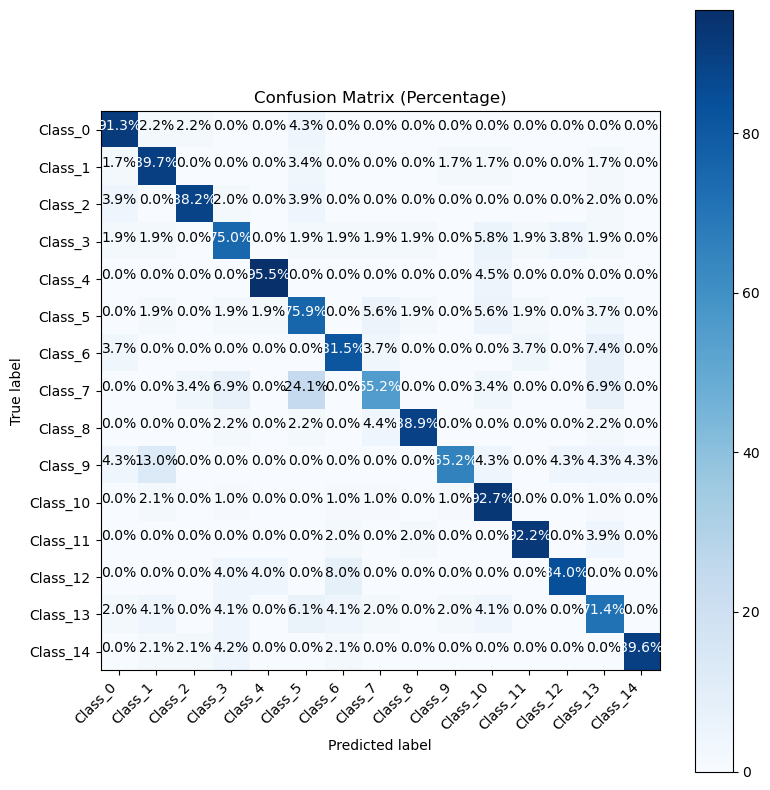


Evaluation Complete!
Total evaluation time: 0:00:00.314881

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:58,  1.60s/it, train_loss=2.5609, train_acc=18.22%, val_loss=2.2919, val_acc=37.13%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.5609, Accuracy: 18.22%
Validation Loss: 2.2919, Accuracy: 37.13%
Current LR: 1.00e-04
Epoch time: 0:00:01.596630
----------------------------------------


Training:   1%|▏         | 2/150 [00:03<04:00,  1.63s/it, train_loss=2.2264, train_acc=36.02%, val_loss=1.9685, val_acc=44.23%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/autoformer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 2.2264, Accuracy: 36.02%
Validation Loss: 1.9685, Accuracy: 44.23%
Current LR: 1.00e-04
Epoch time: 0:00:01.643867
----------------------------------------


...

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 59/150
Training Loss: 0.6127, Accuracy: 83.01%
Validation Loss: 0.6732, Accuracy: 80.03%
Current LR: 1.00e-07
Epoch time: 0:00:01.677605
----------------------------------------


Training:  40%|████      | 60/150 [01:41<02:31,  1.69s/it, train_loss=0.6108, train_acc=82.78%, val_loss=0.6734, val_acc=80.03%, time=0:00:01]

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 60/150
Training Loss: 0.6108, Accuracy: 82.78%
Validation Loss: 0.6734, Accuracy: 80.03%
Current LR: 1.00e-07
Epoch time: 0:00:01.674819
----------------------------------------


Training:  40%|████      | 60/150 [01:42<02:34,  1.72s/it, train_loss=0.6142, train_acc=83.08%, val_loss=0.6734, val_acc=80.03%, time=0:00:01]


ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 61/150
Training Loss: 0.6142, Accuracy: 83.08%
Validation Loss: 0.6734, Accuracy: 80.03%
Current LR: 1.00e-07
Epoch time: 0:00:01.715108
----------------------------------------
Early stopping triggered after 61 epochs

Training Complete!
Total training time: 0:01:42.907453

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/autoformer_classifier_e61_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc80.3.png
Successfully saved metrics plot


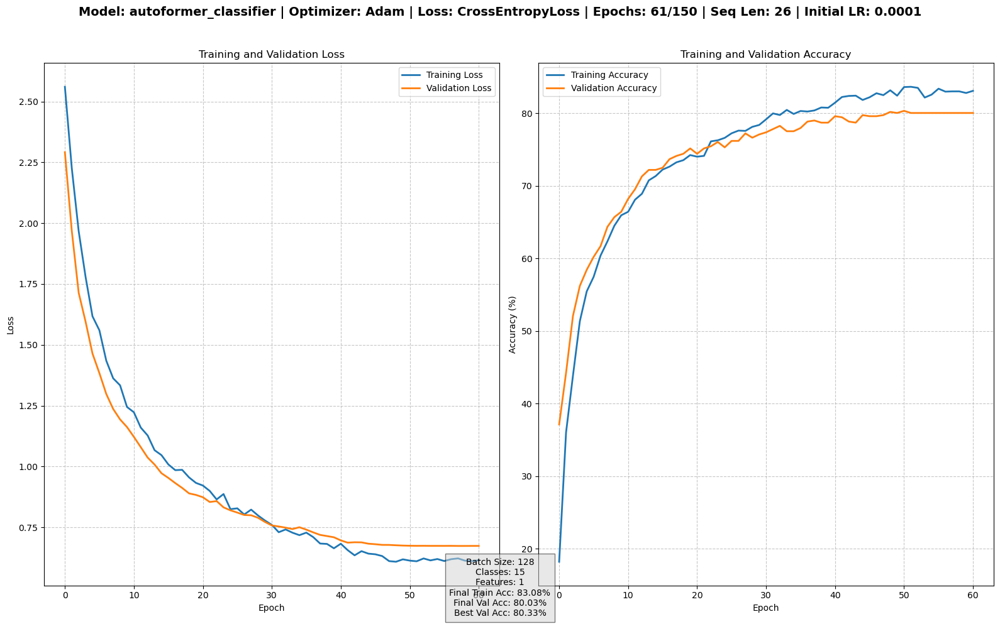

Val Accuracy: 80.03%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/autoformer_classifier_26_confusion_matrix.png


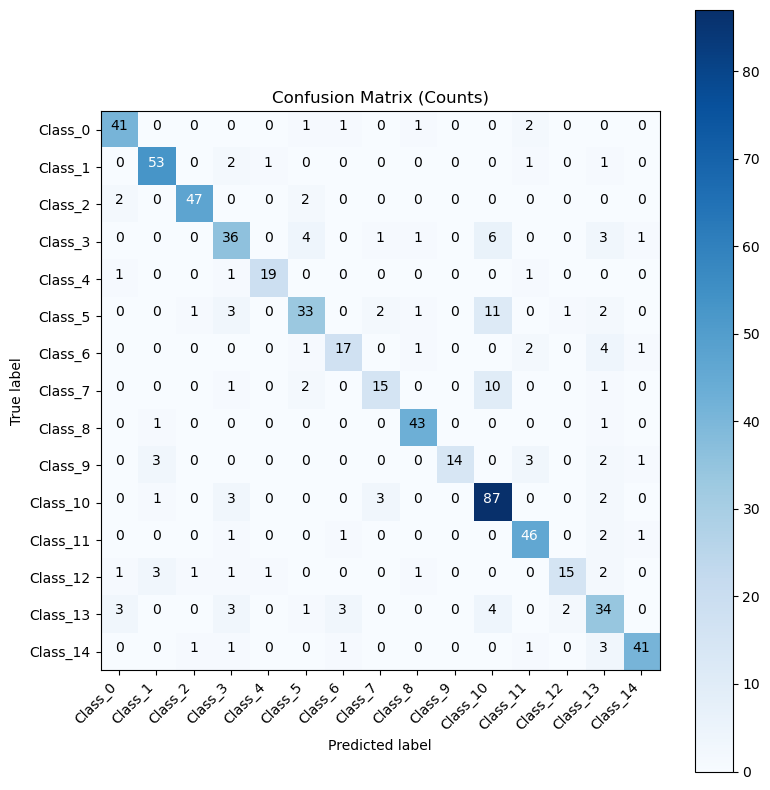

Successfully saved: checkpoints/UTMobile/autoformer_classifier_26_confusion_matrix_percent.png


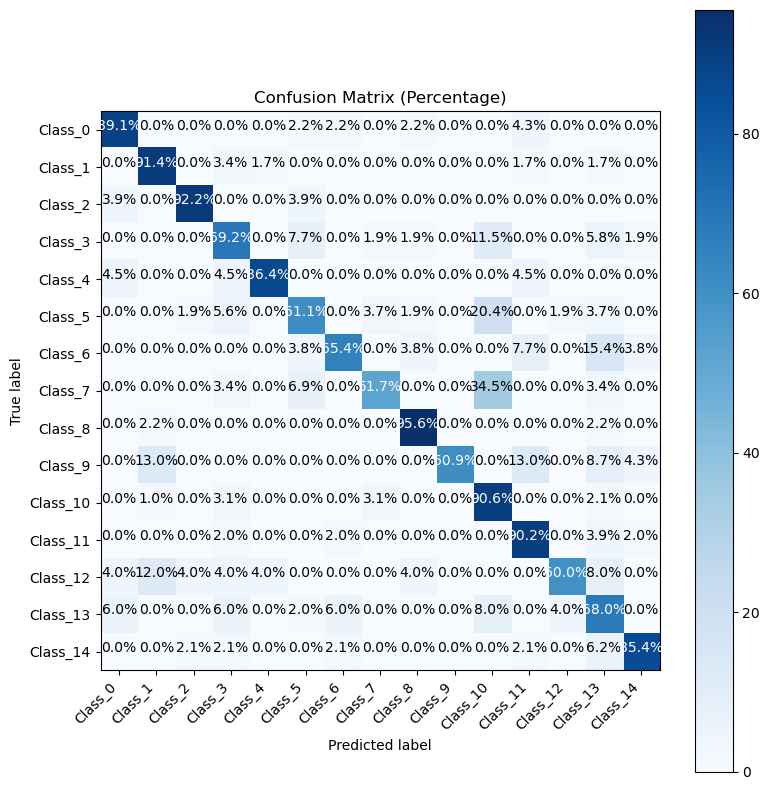


Evaluation Complete!
Total evaluation time: 0:00:00.338584

Evaluating FEDFORMER model across datasets...
fourier enhanced block used!
modes=32, index=[5, 20, 25, 29, 34, 40, 46, 48, 54, 75, 80, 81, 83, 108, 110, 114, 128, 140, 144, 149, 152, 162, 169, 177, 181, 184, 192, 196, 222, 229, 237, 242]
fourier enhanced block used!
modes=32, index=[1, 8, 9, 17, 19, 30, 31, 32, 34, 38, 40, 41, 45, 46, 49, 54, 57, 59, 60, 70, 73, 78, 84, 87, 92, 95, 104, 109, 114, 116, 122, 124]
 fourier enhanced cross attention used!
modes_q=32, index_q=[7, 11, 21, 22, 29, 36, 39, 42, 43, 55, 56, 64, 65, 66, 69, 72, 73, 75, 79, 80, 84, 86, 87, 96, 98, 104, 111, 114, 117, 121, 122, 124]
modes_kv=32, index_kv=[6, 9, 22, 25, 26, 42, 54, 55, 72, 83, 84, 85, 90, 92, 101, 114, 133, 134, 142, 146, 152, 153, 156, 174, 182, 183, 191, 192, 194, 204, 226, 237]

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:04<10:30,  4.23s/it, train_loss=1.9164, train_acc=44.24%, val_loss=1.1633, val_acc=69.53%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 1.9164, Accuracy: 44.24%
Validation Loss: 1.1633, Accuracy: 69.53%
Current LR: 1.00e-04
Epoch time: 0:00:04.229871
----------------------------------------


Training:   1%|▏         | 2/150 [00:08<10:37,  4.31s/it, train_loss=0.9762, train_acc=77.64%, val_loss=0.8643, val_acc=78.70%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 0.9762, Accuracy: 77.64%
Validation Loss: 0.8643, Accuracy: 78.70%
Current LR: 1.00e-04
Epoch time: 0:00:04.358398
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 43/150
Training Loss: 0.0218, Accuracy: 99.30%
Validation Loss: 0.5984, Accuracy: 85.65%
Current LR: 1.00e-07
Epoch time: 0:00:04.358452
----------------------------------------


Training:  29%|██▉       | 44/150 [03:04<07:33,  4.28s/it, train_loss=0.0210, train_acc=99.41%, val_loss=0.5984, val_acc=85.65%, time=0:00:04]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 44/150
Training Loss: 0.0210, Accuracy: 99.41%
Validation Loss: 0.5984, Accuracy: 85.65%
Current LR: 1.00e-07
Epoch time: 0:00:04.190295
----------------------------------------


Training:  29%|██▉       | 44/150 [03:08<07:33,  4.28s/it, train_loss=0.0208, train_acc=99.44%, val_loss=0.5984, val_acc=85.65%, time=0:00:04]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 45/150
Training Loss: 0.0208, Accuracy: 99.44%
Validation Loss: 0.5984, Accuracy: 85.65%
Current LR: 1.00e-07
Epoch time: 0:00:04.290857
----------------------------------------
Early stopping triggered after 45 epochs

Training Complete!
Total training time: 0:03:08.413102

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e45_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc86.1.png
Successfully saved metrics plot


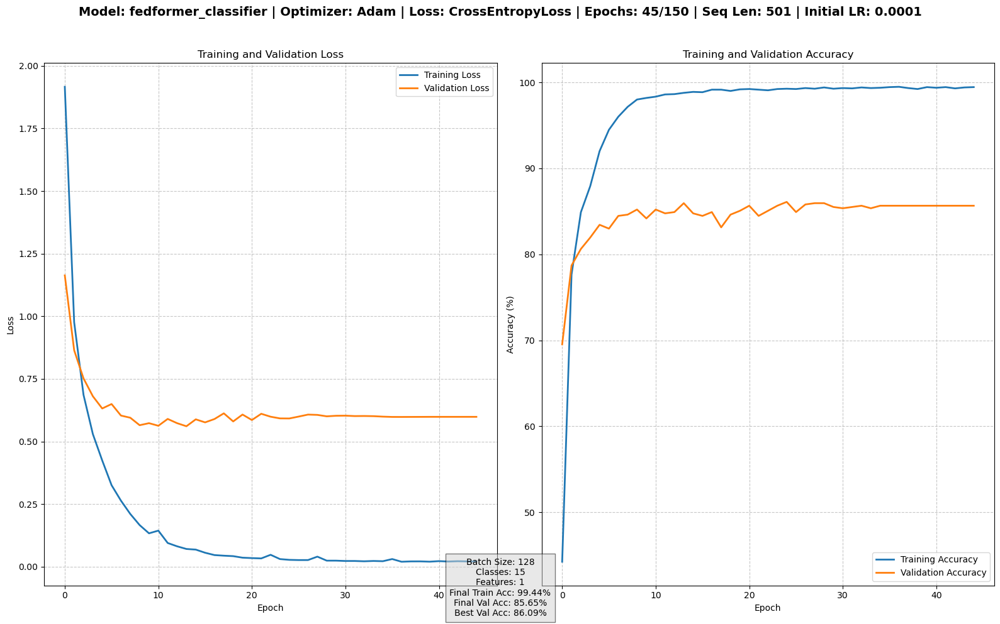

Val Accuracy: 85.65%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_501_confusion_matrix.png


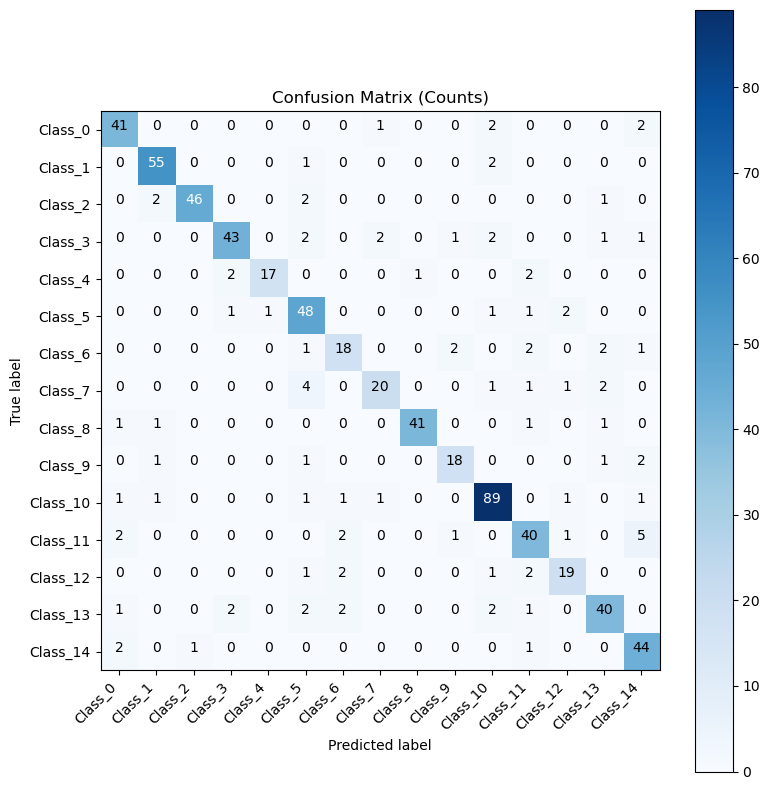

Successfully saved: checkpoints/UTMobile/fedformer_classifier_501_confusion_matrix_percent.png


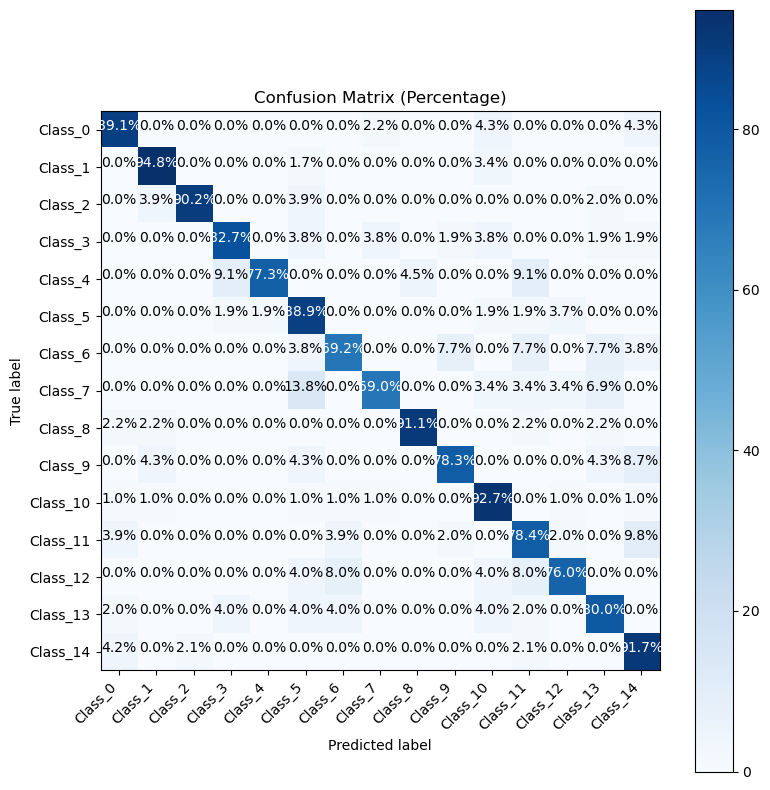


Evaluation Complete!
Total evaluation time: 0:00:00.457229
fourier enhanced block used!
modes=32, index=[1, 6, 12, 14, 16, 18, 20, 23, 24, 36, 43, 45, 51, 61, 65, 72, 74, 78, 80, 81, 83, 85, 90, 98, 99, 101, 105, 107, 111, 112, 116, 123]
fourier enhanced block used!
modes=32, index=[1, 2, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 24, 25, 28, 30, 32, 34, 35, 36, 37, 38, 43, 45, 47, 49, 51, 52, 53, 55, 57, 59]
 fourier enhanced cross attention used!
modes_q=32, index_q=[0, 1, 4, 7, 10, 14, 17, 18, 20, 21, 23, 24, 26, 28, 29, 30, 32, 34, 35, 36, 37, 40, 43, 45, 47, 48, 51, 55, 56, 58, 60, 61]
modes_kv=32, index_kv=[2, 4, 6, 9, 14, 19, 21, 27, 28, 30, 36, 44, 45, 55, 56, 57, 65, 68, 76, 78, 80, 90, 101, 103, 104, 105, 106, 114, 118, 120, 123, 124]

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:04<10:07,  4.07s/it, train_loss=2.1234, train_acc=34.65%, val_loss=1.4865, val_acc=59.32%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.1234, Accuracy: 34.65%
Validation Loss: 1.4865, Accuracy: 59.32%
Current LR: 1.00e-04
Epoch time: 0:00:04.073016
----------------------------------------


Training:   1%|▏         | 2/150 [00:08<10:18,  4.18s/it, train_loss=1.2954, train_acc=67.46%, val_loss=1.0741, val_acc=70.86%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.2954, Accuracy: 67.46%
Validation Loss: 1.0741, Accuracy: 70.86%
Current LR: 1.00e-04
Epoch time: 0:00:04.255487
----------------------------------------


...

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 46/150
Training Loss: 0.0247, Accuracy: 99.48%
Validation Loss: 0.4721, Accuracy: 85.80%
Current LR: 1.00e-07
Epoch time: 0:00:04.331009
----------------------------------------


Training:  31%|███▏      | 47/150 [03:23<07:23,  4.30s/it, train_loss=0.0249, train_acc=99.48%, val_loss=0.4721, val_acc=85.80%, time=0:00:04]

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 47/150
Training Loss: 0.0249, Accuracy: 99.48%
Validation Loss: 0.4721, Accuracy: 85.80%
Current LR: 1.00e-07
Epoch time: 0:00:04.300431
----------------------------------------


Training:  31%|███▏      | 47/150 [03:27<07:34,  4.41s/it, train_loss=0.0249, train_acc=99.48%, val_loss=0.4721, val_acc=85.80%, time=0:00:04]


ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 48/150
Training Loss: 0.0249, Accuracy: 99.48%
Validation Loss: 0.4721, Accuracy: 85.80%
Current LR: 1.00e-07
Epoch time: 0:00:04.226975
----------------------------------------
Early stopping triggered after 48 epochs

Training Complete!
Total training time: 0:03:27.255600

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e48_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc87.0.png
Successfully saved metrics plot


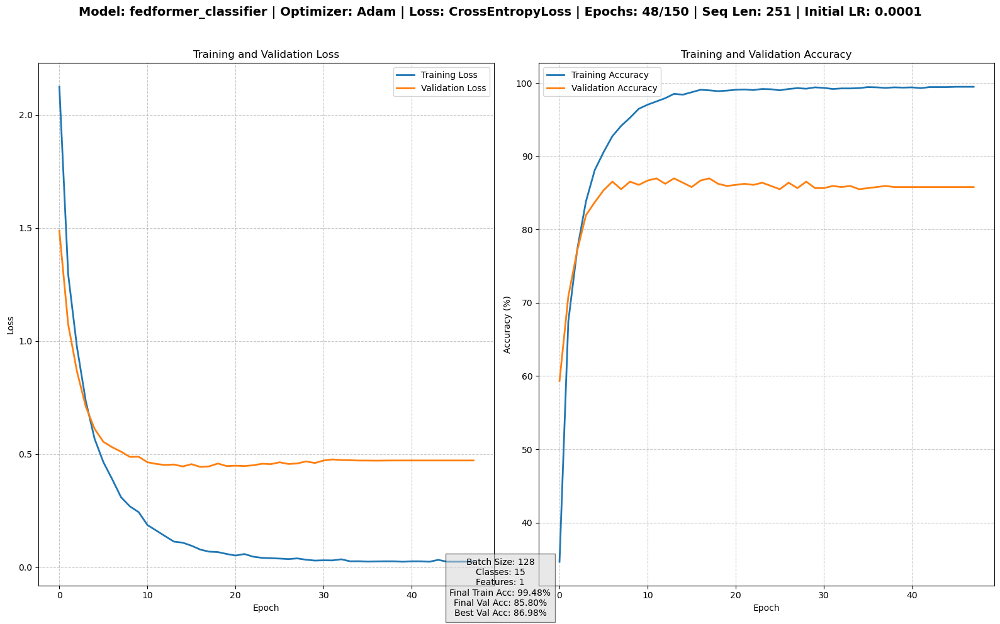

Val Accuracy: 85.80%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_251_confusion_matrix.png


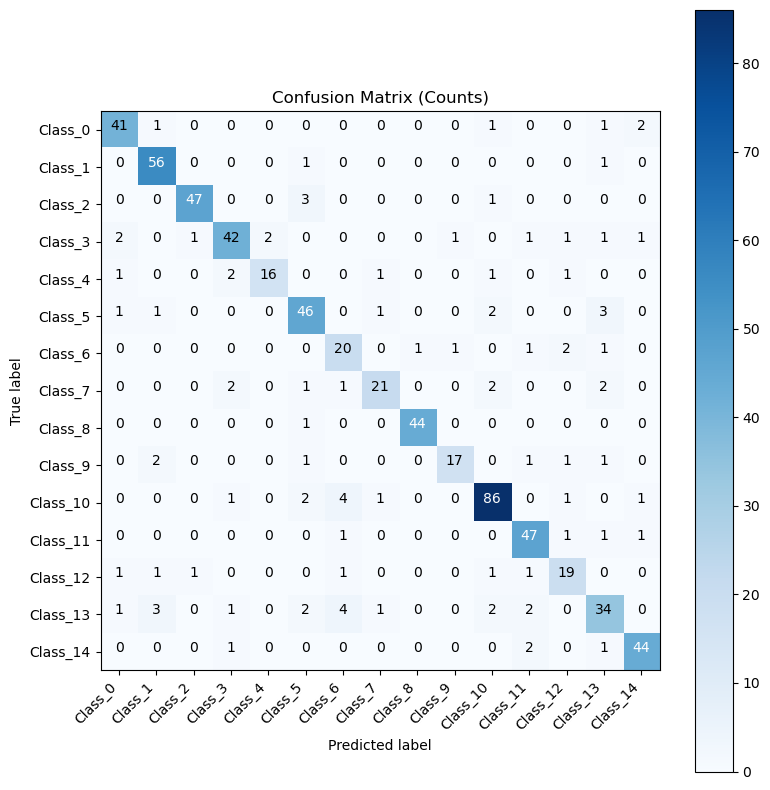

Successfully saved: checkpoints/UTMobile/fedformer_classifier_251_confusion_matrix_percent.png


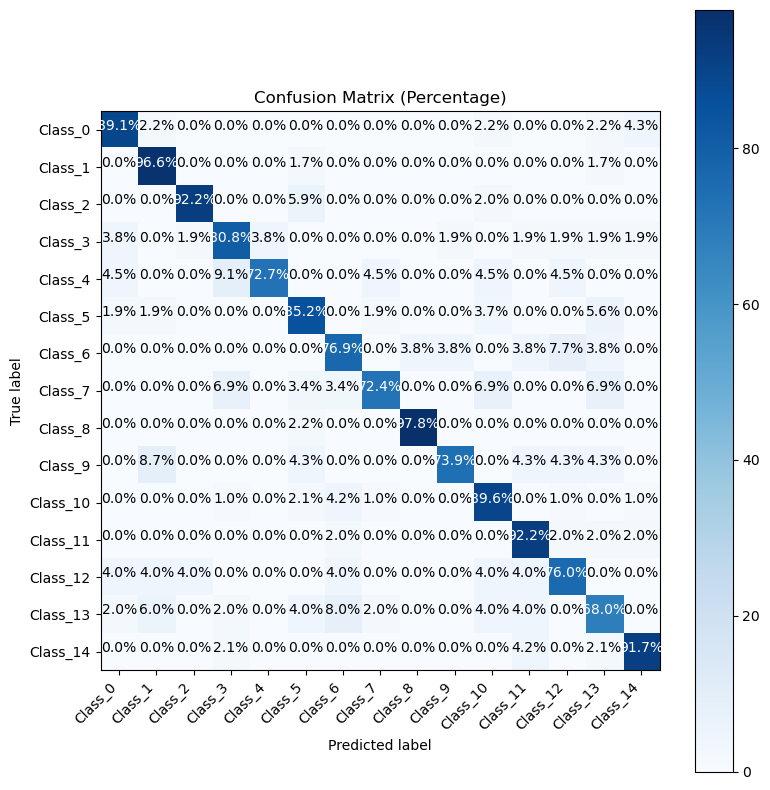


Evaluation Complete!
Total evaluation time: 0:00:00.450390
fourier enhanced block used!
modes=32, index=[0, 1, 3, 4, 7, 14, 26, 28, 29, 30, 32, 33, 36, 38, 39, 41, 43, 45, 46, 53, 54, 60, 67, 68, 71, 72, 73, 75, 78, 79, 80, 82]
fourier enhanced block used!
modes=32, index=[0, 1, 3, 6, 7, 9, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40]
 fourier enhanced cross attention used!
modes_q=32, index_q=[0, 1, 4, 5, 6, 7, 9, 10, 11, 14, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 37, 38, 39, 40]
modes_kv=32, index_kv=[6, 9, 12, 18, 19, 21, 28, 30, 33, 36, 38, 39, 42, 44, 49, 51, 53, 54, 56, 57, 58, 60, 64, 65, 66, 67, 72, 75, 76, 78, 81, 82]

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:04<11:04,  4.46s/it, train_loss=2.2069, train_acc=32.59%, val_loss=1.6579, val_acc=51.48%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.2069, Accuracy: 32.59%
Validation Loss: 1.6579, Accuracy: 51.48%
Current LR: 1.00e-04
Epoch time: 0:00:04.455702
----------------------------------------


Training:   1%|▏         | 2/150 [00:08<11:02,  4.48s/it, train_loss=1.5018, train_acc=59.67%, val_loss=1.2818, val_acc=64.35%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.5018, Accuracy: 59.67%
Validation Loss: 1.2818, Accuracy: 64.35%
Current LR: 1.00e-04
Epoch time: 0:00:04.488940
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 59/150
Training Loss: 0.0280, Accuracy: 99.30%
Validation Loss: 0.4468, Accuracy: 86.39%
Current LR: 1.00e-07
Epoch time: 0:00:04.328683
----------------------------------------


Training:  40%|████      | 60/150 [04:19<06:30,  4.34s/it, train_loss=0.0263, train_acc=99.44%, val_loss=0.4468, val_acc=86.39%, time=0:00:04]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 60/150
Training Loss: 0.0263, Accuracy: 99.44%
Validation Loss: 0.4468, Accuracy: 86.39%
Current LR: 1.00e-07
Epoch time: 0:00:04.308897
----------------------------------------


Training:  40%|████      | 60/150 [04:24<06:36,  4.41s/it, train_loss=0.0263, train_acc=99.41%, val_loss=0.4468, val_acc=86.39%, time=0:00:04]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 61/150
Training Loss: 0.0263, Accuracy: 99.41%
Validation Loss: 0.4468, Accuracy: 86.39%
Current LR: 1.00e-07
Epoch time: 0:00:04.336297
----------------------------------------
Early stopping triggered after 61 epochs

Training Complete!
Total training time: 0:04:24.345186

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e61_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc87.4.png
Successfully saved metrics plot


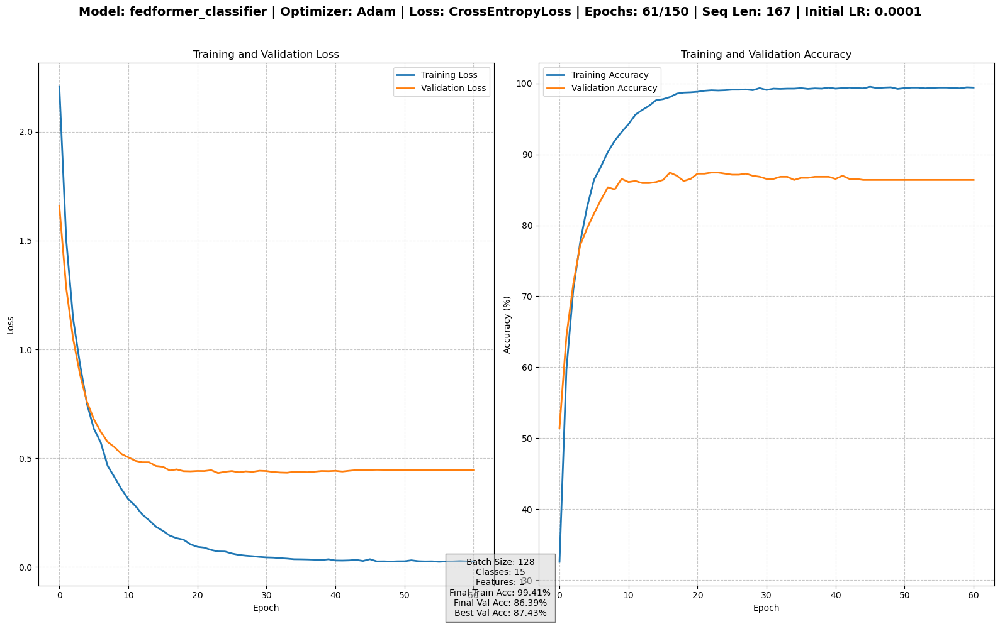

Val Accuracy: 86.39%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_167_confusion_matrix.png


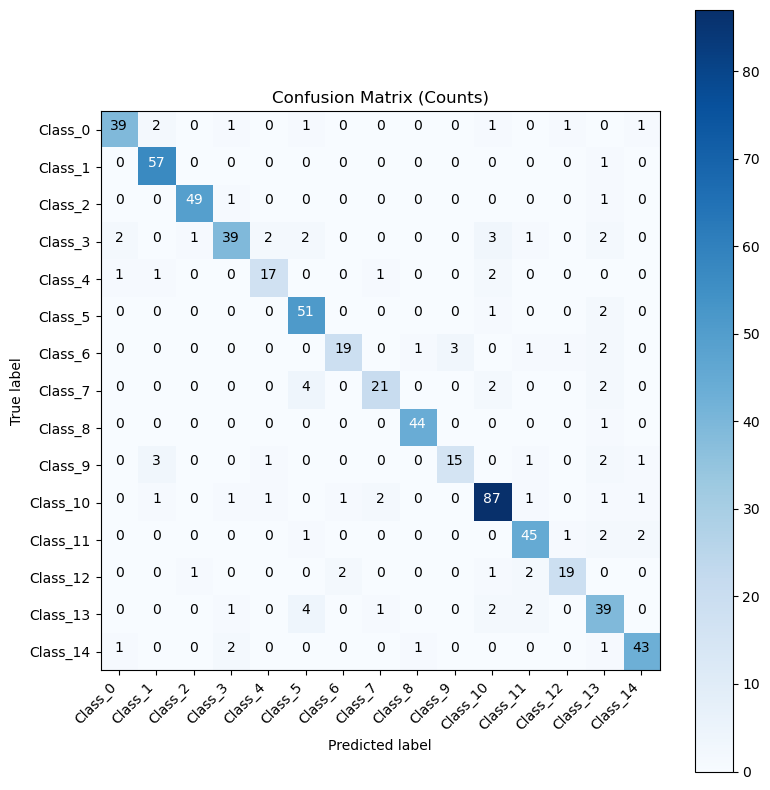

Successfully saved: checkpoints/UTMobile/fedformer_classifier_167_confusion_matrix_percent.png


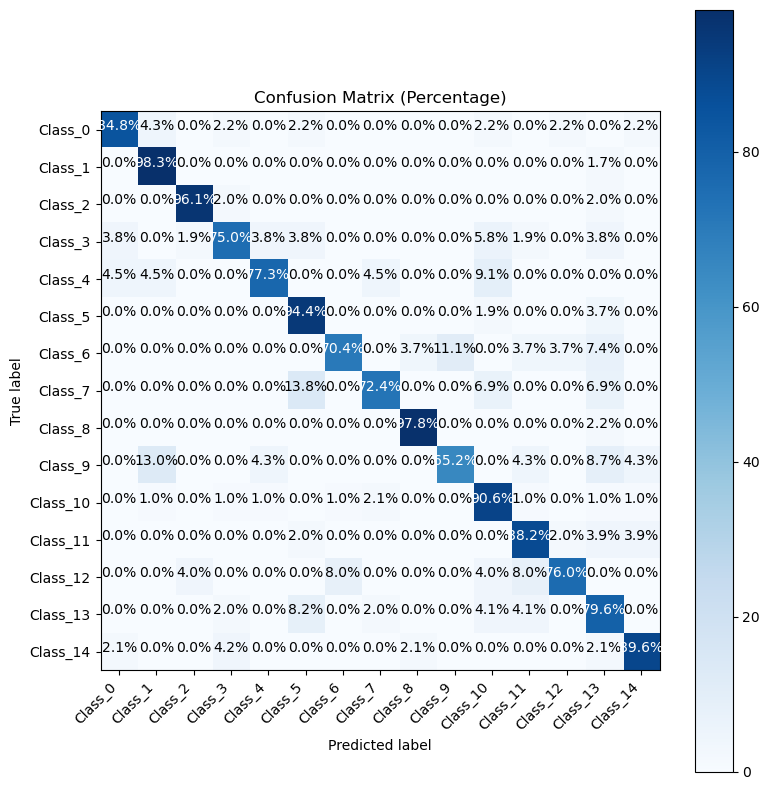


Evaluation Complete!
Total evaluation time: 0:00:00.487098
fourier enhanced block used!
modes=32, index=[0, 3, 5, 7, 12, 13, 14, 15, 16, 17, 18, 19, 27, 28, 29, 30, 31, 32, 33, 35, 39, 41, 44, 45, 48, 49, 51, 54, 56, 58, 60, 61]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
 fourier enhanced cross attention used!
modes_q=31, index_q=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
modes_kv=32, index_kv=[0, 1, 3, 5, 6, 7, 8, 9, 11, 13, 14, 15, 16, 17, 20, 23, 27, 29, 30, 31, 32, 37, 39, 40, 41, 44, 47, 51, 55, 57, 61, 62]

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:04<10:57,  4.41s/it, train_loss=2.2548, train_acc=31.73%, val_loss=1.7246, val_acc=53.25%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.2548, Accuracy: 31.73%
Validation Loss: 1.7246, Accuracy: 53.25%
Current LR: 1.00e-04
Epoch time: 0:00:04.408902
----------------------------------------


Training:   1%|▏         | 2/150 [00:08<10:52,  4.41s/it, train_loss=1.6298, train_acc=56.31%, val_loss=1.3653, val_acc=60.06%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.6298, Accuracy: 56.31%
Validation Loss: 1.3653, Accuracy: 60.06%
Current LR: 1.00e-04
Epoch time: 0:00:04.403603
----------------------------------------


...

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 74/150
Training Loss: 0.0283, Accuracy: 99.44%
Validation Loss: 0.4650, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:04.399525
----------------------------------------


Training:  50%|█████     | 75/150 [05:24<05:25,  4.34s/it, train_loss=0.0294, train_acc=99.37%, val_loss=0.4650, val_acc=86.54%, time=0:00:04]

ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 75/150
Training Loss: 0.0294, Accuracy: 99.37%
Validation Loss: 0.4650, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:04.335365
----------------------------------------


Training:  50%|█████     | 75/150 [05:28<05:28,  4.38s/it, train_loss=0.0287, train_acc=99.48%, val_loss=0.4650, val_acc=86.54%, time=0:00:04]


ReduceLROnPlateau counter: 8 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 76/150
Training Loss: 0.0287, Accuracy: 99.48%
Validation Loss: 0.4650, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:04.318182
----------------------------------------
Early stopping triggered after 76 epochs

Training Complete!
Total training time: 0:05:28.535006

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e76_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc87.1.png
Successfully saved metrics plot


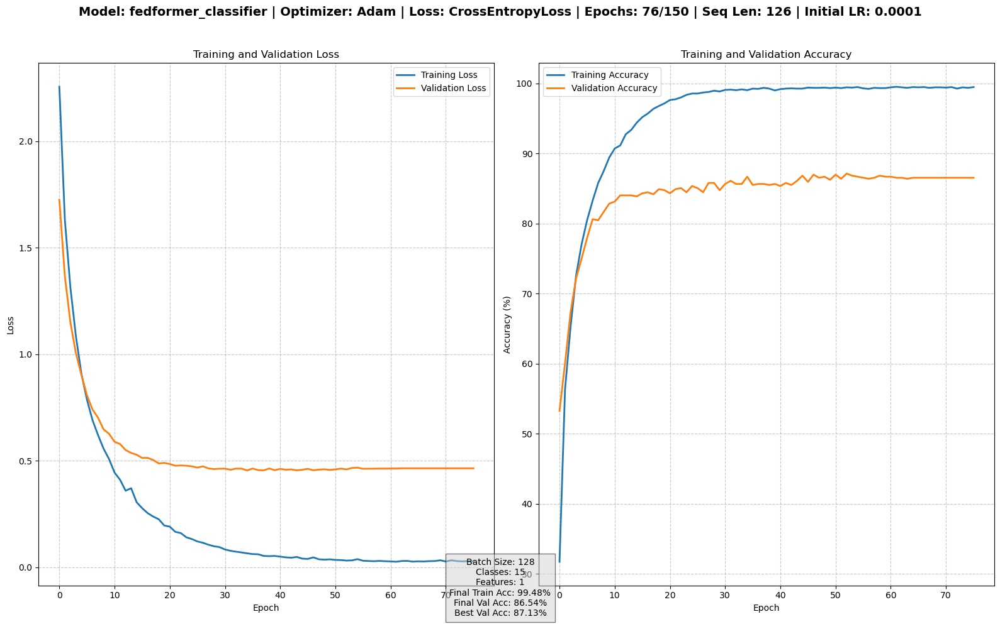

Val Accuracy: 86.54%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_126_confusion_matrix.png


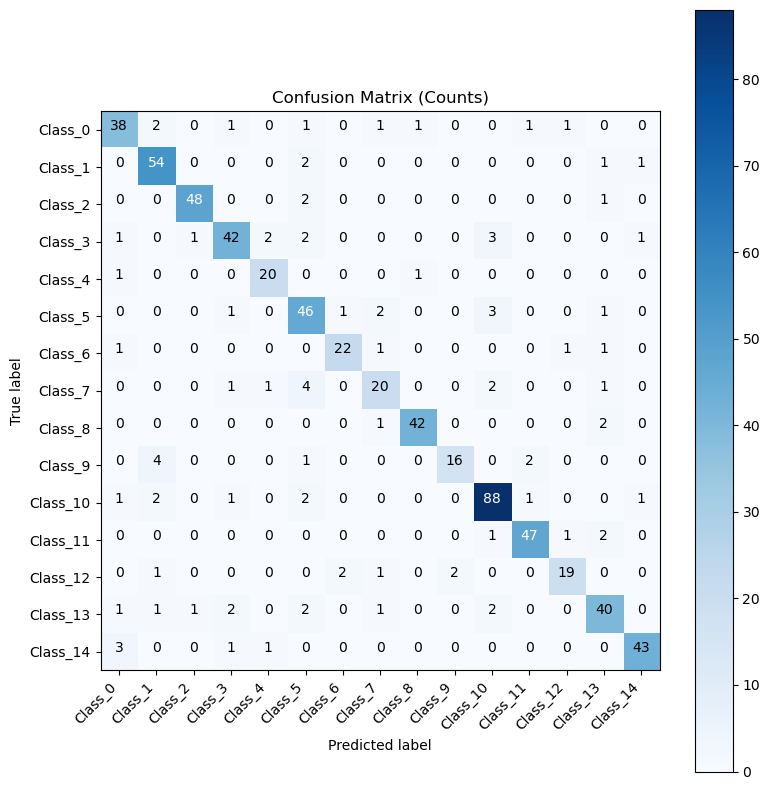

Successfully saved: checkpoints/UTMobile/fedformer_classifier_126_confusion_matrix_percent.png


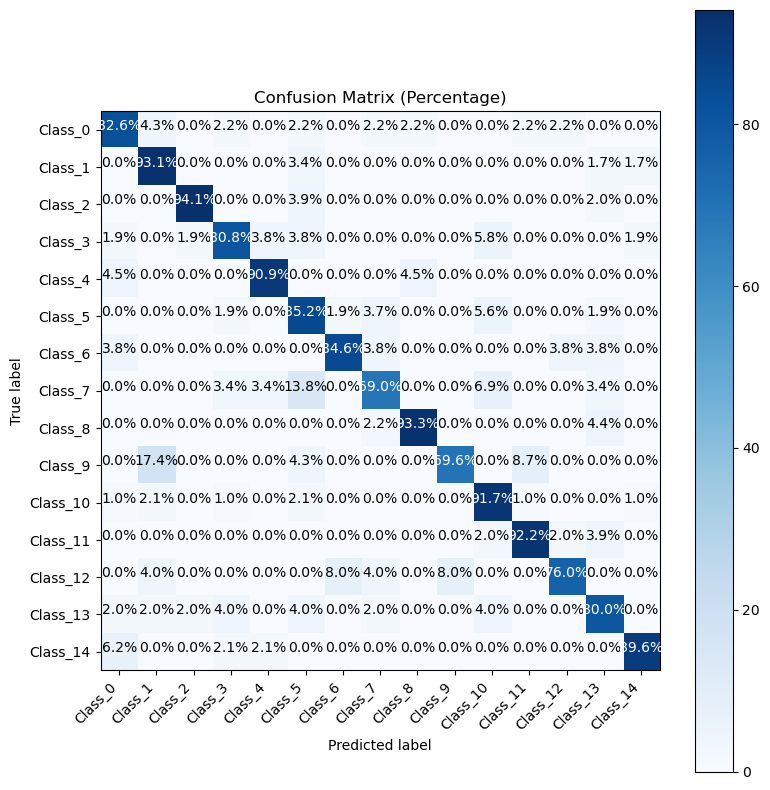


Evaluation Complete!
Total evaluation time: 0:00:00.476249
fourier enhanced block used!
modes=32, index=[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
 fourier enhanced cross attention used!
modes_q=16, index_q=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
modes_kv=32, index_kv=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:04<10:48,  4.35s/it, train_loss=2.3917, train_acc=27.67%, val_loss=1.8653, val_acc=46.89%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.3917, Accuracy: 27.67%
Validation Loss: 1.8653, Accuracy: 46.89%
Current LR: 1.00e-04
Epoch time: 0:00:04.351796
----------------------------------------


Training:   1%|▏         | 2/150 [00:08<10:32,  4.27s/it, train_loss=1.7312, train_acc=52.04%, val_loss=1.4797, val_acc=56.51%, time=0:00:04]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.7312, Accuracy: 52.04%
Validation Loss: 1.4797, Accuracy: 56.51%
Current LR: 1.00e-04
Epoch time: 0:00:04.214050
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 86/150
Training Loss: 0.0490, Accuracy: 99.22%
Validation Loss: 0.5368, Accuracy: 85.21%
Current LR: 1.00e-07
Epoch time: 0:00:04.292999
----------------------------------------


Training:  58%|█████▊    | 87/150 [06:14<04:31,  4.32s/it, train_loss=0.0510, train_acc=99.26%, val_loss=0.5368, val_acc=85.21%, time=0:00:04]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 87/150
Training Loss: 0.0510, Accuracy: 99.26%
Validation Loss: 0.5368, Accuracy: 85.21%
Current LR: 1.00e-07
Epoch time: 0:00:04.304451
----------------------------------------


Training:  58%|█████▊    | 87/150 [06:18<04:34,  4.35s/it, train_loss=0.0535, train_acc=99.30%, val_loss=0.5368, val_acc=85.21%, time=0:00:04]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 88/150
Training Loss: 0.0535, Accuracy: 99.30%
Validation Loss: 0.5368, Accuracy: 85.21%
Current LR: 1.00e-07
Epoch time: 0:00:04.340248
----------------------------------------
Early stopping triggered after 88 epochs

Training Complete!
Total training time: 0:06:18.584931

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e88_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc85.7.png
Successfully saved metrics plot


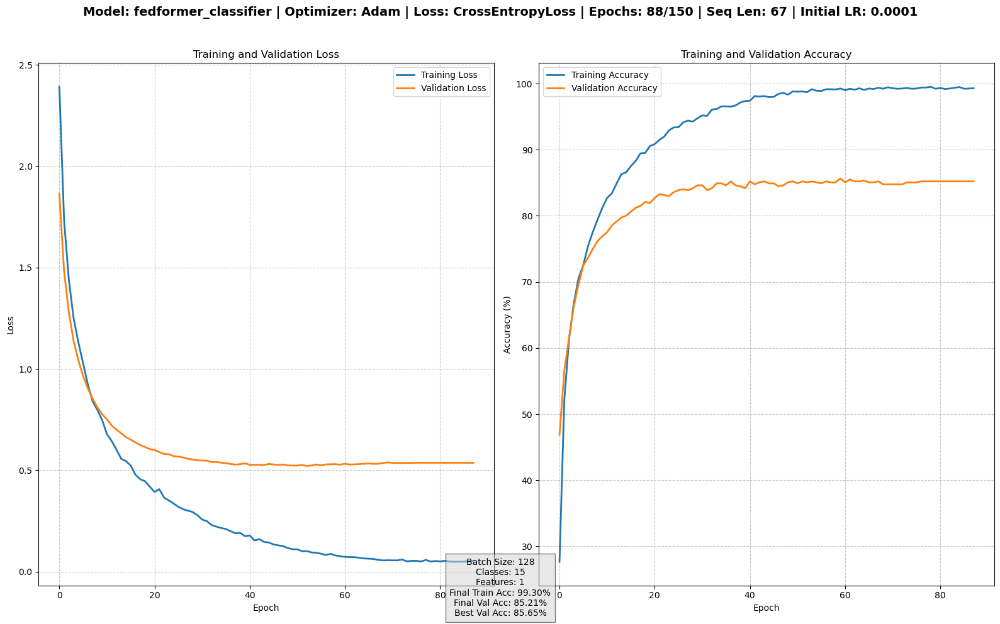

Val Accuracy: 85.21%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_67_confusion_matrix.png


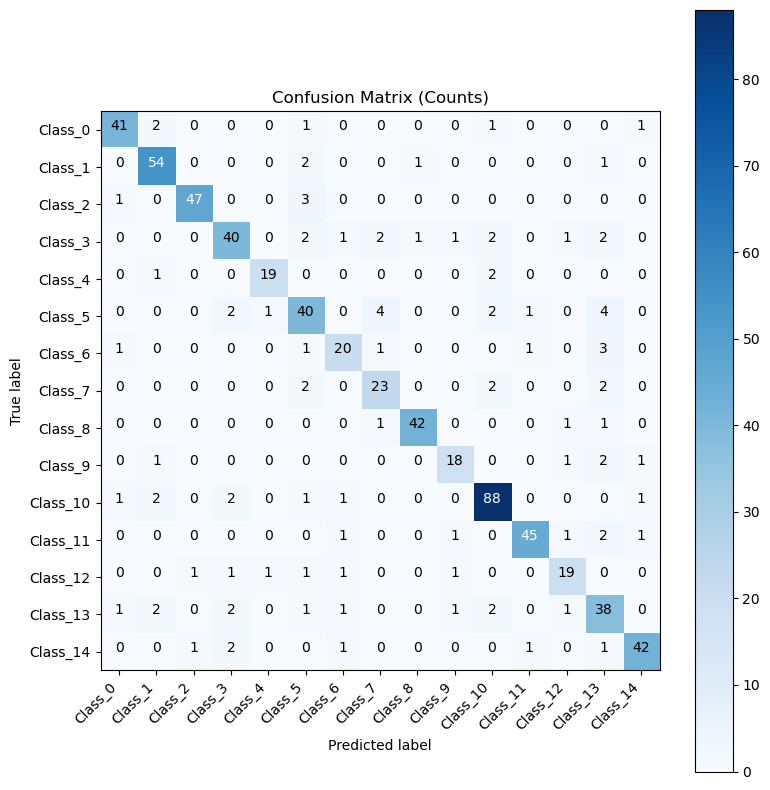

Successfully saved: checkpoints/UTMobile/fedformer_classifier_67_confusion_matrix_percent.png


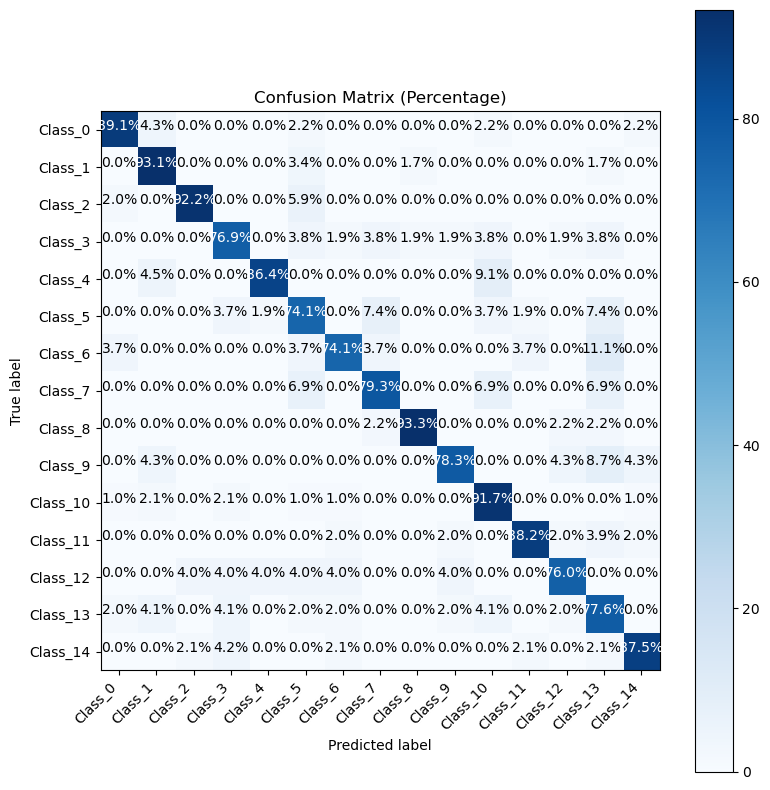


Evaluation Complete!
Total evaluation time: 0:00:00.462434
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5]
 fourier enhanced cross attention used!
modes_q=6, index_q=[0, 1, 2, 3, 4, 5]
modes_kv=13, index_kv=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:02<06:20,  2.55s/it, train_loss=2.4743, train_acc=22.66%, val_loss=2.0954, val_acc=42.46%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 2.4743, Accuracy: 22.66%
Validation Loss: 2.0954, Accuracy: 42.46%
Current LR: 1.00e-04
Epoch time: 0:00:02.552903
----------------------------------------


Training:   1%|▏         | 2/150 [00:05<06:33,  2.66s/it, train_loss=2.0463, train_acc=42.69%, val_loss=1.7402, val_acc=49.85%, time=0:00:02]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/fedformer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 2.0463, Accuracy: 42.69%
Validation Loss: 1.7402, Accuracy: 49.85%
Current LR: 1.00e-04
Epoch time: 0:00:02.725305
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 89/150
Training Loss: 0.2715, Accuracy: 93.22%
Validation Loss: 0.5159, Accuracy: 84.76%
Current LR: 1.00e-07
Epoch time: 0:00:02.682167
----------------------------------------


Training:  60%|██████    | 90/150 [04:00<02:40,  2.67s/it, train_loss=0.2555, train_acc=93.67%, val_loss=0.5159, val_acc=84.76%, time=0:00:02]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 90/150
Training Loss: 0.2555, Accuracy: 93.67%
Validation Loss: 0.5159, Accuracy: 84.76%
Current LR: 1.00e-07
Epoch time: 0:00:02.678661
----------------------------------------


Training:  60%|██████    | 90/150 [04:03<02:42,  2.70s/it, train_loss=0.2643, train_acc=93.63%, val_loss=0.5159, val_acc=84.76%, time=0:00:02]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 91/150
Training Loss: 0.2643, Accuracy: 93.63%
Validation Loss: 0.5159, Accuracy: 84.76%
Current LR: 1.00e-07
Epoch time: 0:00:02.624426
----------------------------------------
Early stopping triggered after 91 epochs

Training Complete!
Total training time: 0:04:03.356310

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/fedformer_classifier_e91_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc85.1.png
Successfully saved metrics plot


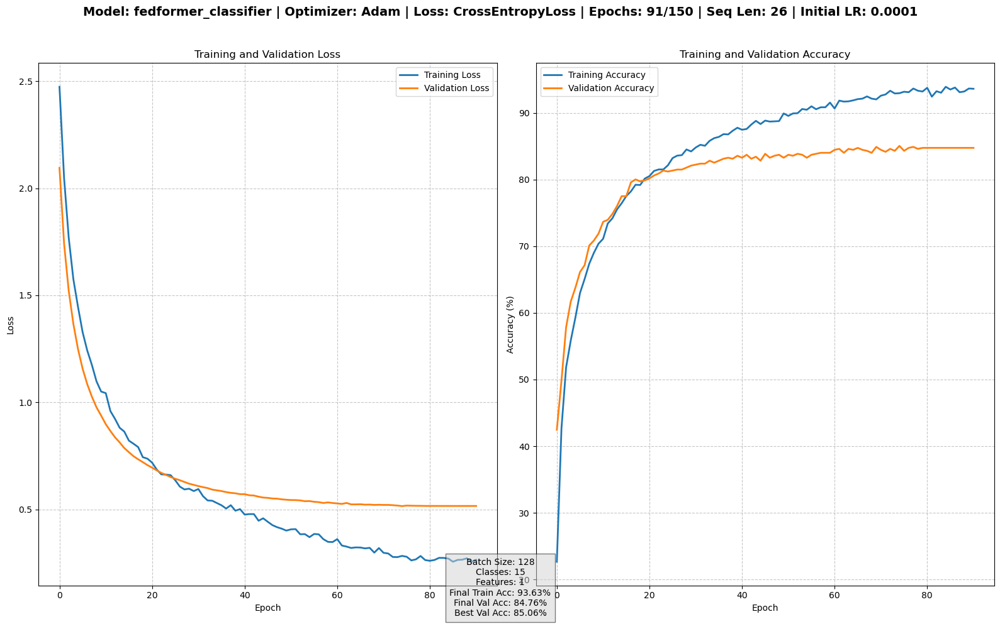

Val Accuracy: 84.76%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/fedformer_classifier_26_confusion_matrix.png


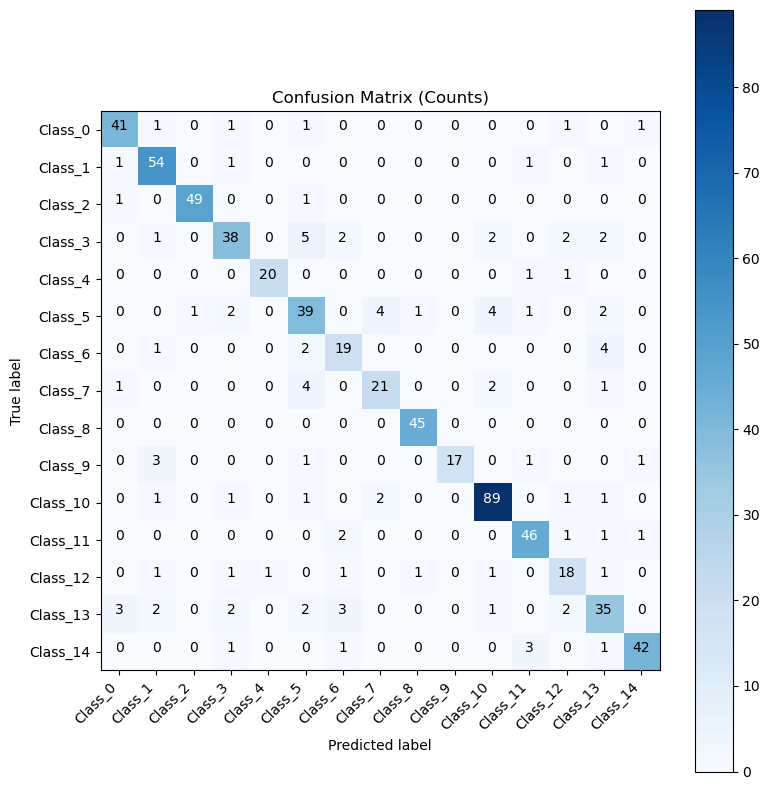

Successfully saved: checkpoints/UTMobile/fedformer_classifier_26_confusion_matrix_percent.png


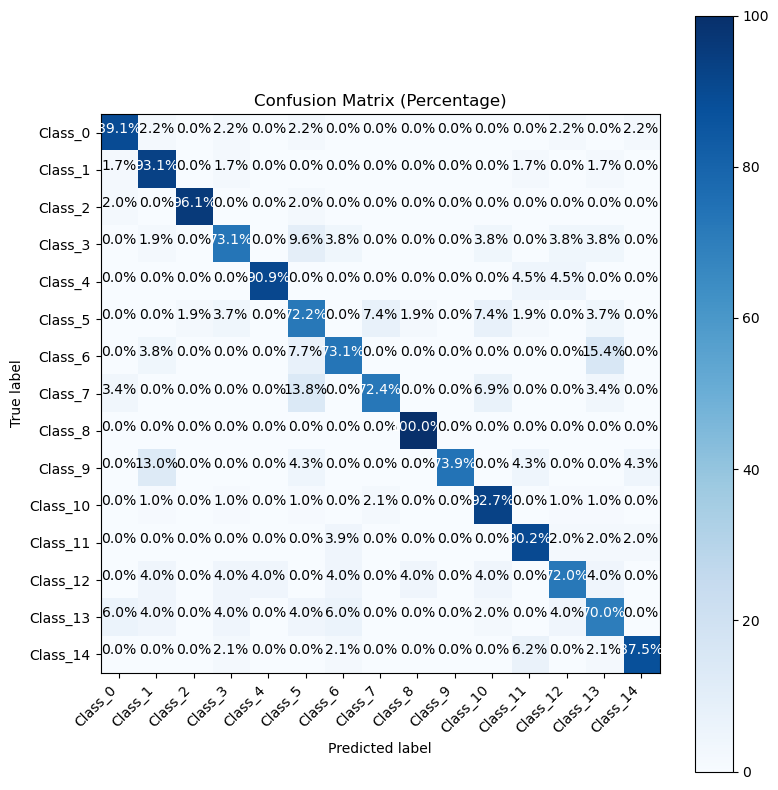


Evaluation Complete!
Total evaluation time: 0:00:00.370921

Evaluating TIMEMIXER model across datasets...

Processing dataset: 10_5_14classes_501
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:22,  1.36s/it, train_loss=4.8512, train_acc=40.21%, val_loss=2.9041, val_acc=60.21%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 4.8512, Accuracy: 40.21%
Validation Loss: 2.9041, Accuracy: 60.21%
Current LR: 1.00e-04
Epoch time: 0:00:01.357059
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:26,  1.40s/it, train_loss=1.5457, train_acc=73.42%, val_loss=2.2930, val_acc=68.05%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_501_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 1.5457, Accuracy: 73.42%
Validation Loss: 2.2930, Accuracy: 68.05%
Current LR: 1.00e-04
Epoch time: 0:00:01.423196
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 35/150
Training Loss: 0.0201, Accuracy: 99.30%
Validation Loss: 3.0111, Accuracy: 78.85%
Current LR: 1.00e-07
Epoch time: 0:00:01.434853
----------------------------------------


Training:  24%|██▍       | 36/150 [00:51<02:41,  1.42s/it, train_loss=0.0224, train_acc=99.33%, val_loss=3.0110, val_acc=78.85%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 36/150
Training Loss: 0.0224, Accuracy: 99.33%
Validation Loss: 3.0110, Accuracy: 78.85%
Current LR: 1.00e-07
Epoch time: 0:00:01.395440
----------------------------------------


Training:  24%|██▍       | 36/150 [00:52<02:46,  1.46s/it, train_loss=0.0197, train_acc=99.37%, val_loss=3.0112, val_acc=78.85%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 37/150
Training Loss: 0.0197, Accuracy: 99.37%
Validation Loss: 3.0112, Accuracy: 78.85%
Current LR: 1.00e-07
Epoch time: 0:00:01.413858
----------------------------------------
Early stopping triggered after 37 epochs

Training Complete!
Total training time: 0:00:52.650555

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e37_optAdam_lr0.0001_lossCrossEntropyLoss_seq501_acc79.3.png
Successfully saved metrics plot


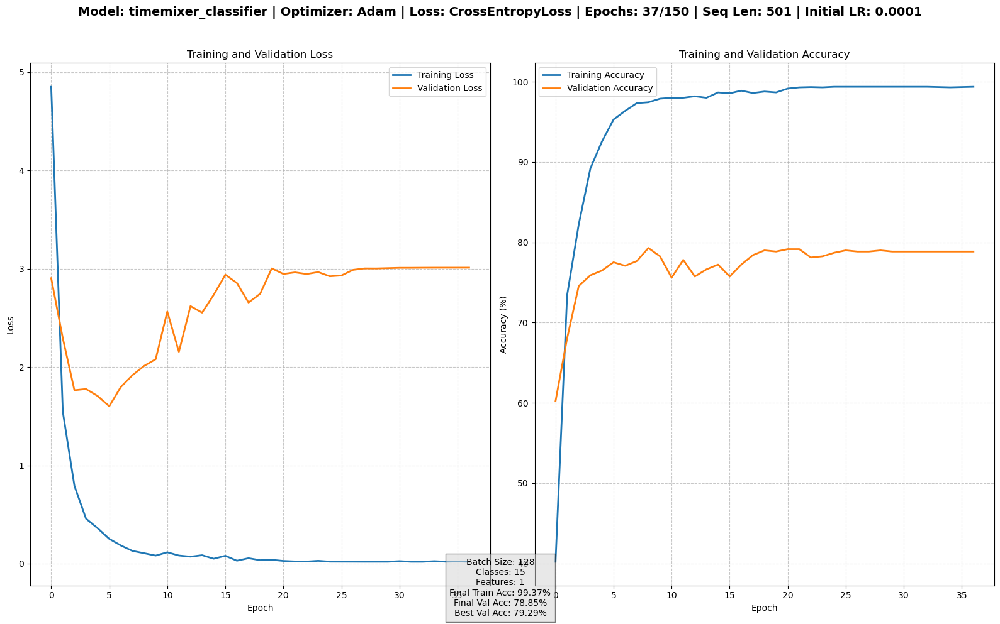

Val Accuracy: 78.85%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_501_confusion_matrix.png


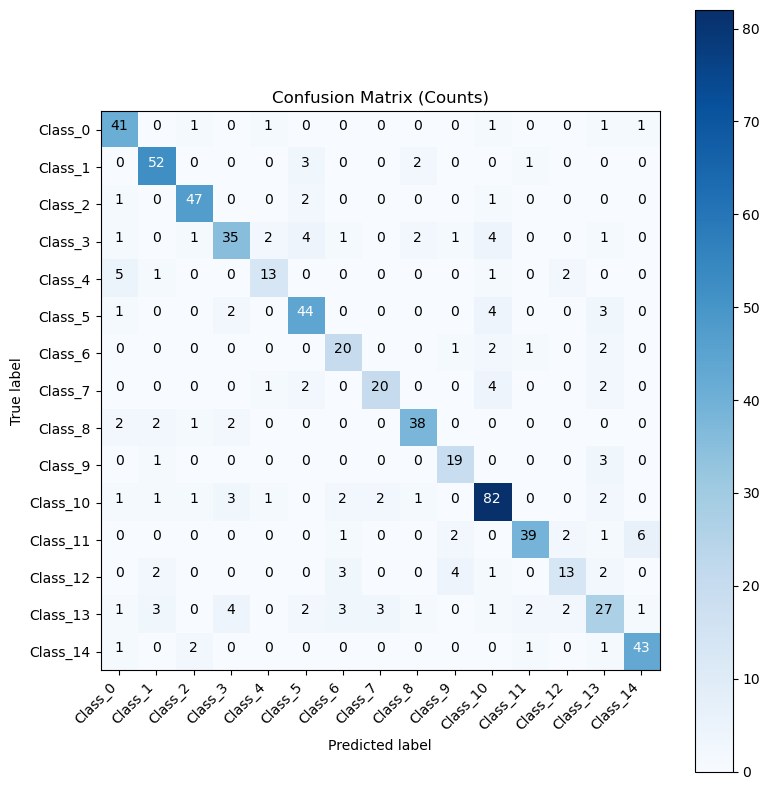

Successfully saved: checkpoints/UTMobile/timemixer_classifier_501_confusion_matrix_percent.png


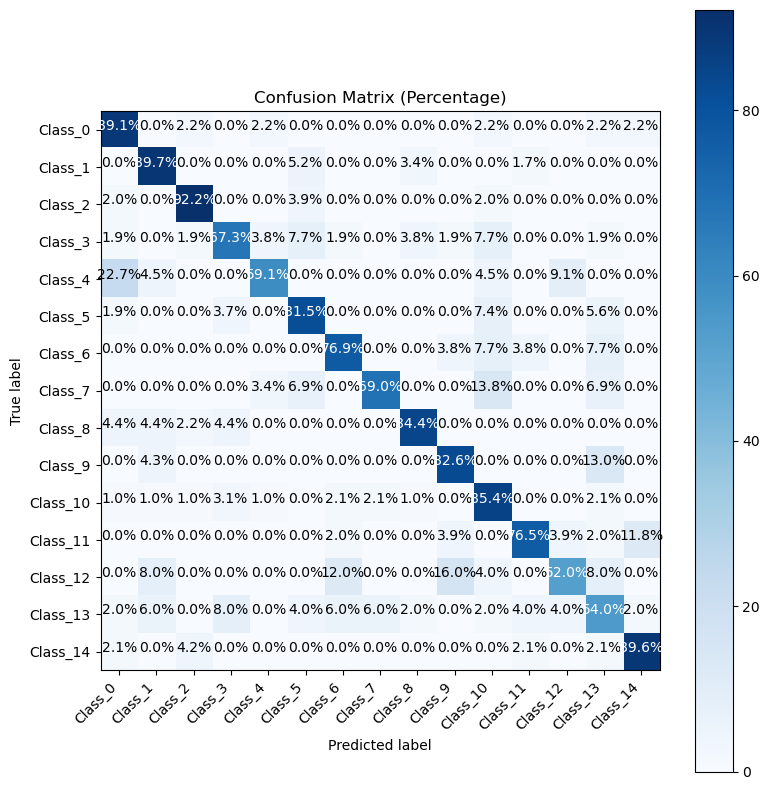


Evaluation Complete!
Total evaluation time: 0:00:00.327053

Processing dataset: 20_5_14classes_251
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:13,  1.30s/it, train_loss=6.1444, train_acc=34.76%, val_loss=3.3125, val_acc=57.40%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 6.1444, Accuracy: 34.76%
Validation Loss: 3.3125, Accuracy: 57.40%
Current LR: 1.00e-04
Epoch time: 0:00:01.296838
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:18,  1.34s/it, train_loss=2.3886, train_acc=64.83%, val_loss=2.1783, val_acc=68.20%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_251_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 2.3886, Accuracy: 64.83%
Validation Loss: 2.1783, Accuracy: 68.20%
Current LR: 1.00e-04
Epoch time: 0:00:01.370933
----------------------------------------


...

ReduceLROnPlateau counter: 3 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 44/150
Training Loss: 0.0211, Accuracy: 99.33%
Validation Loss: 2.0078, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.280340
----------------------------------------


Training:  30%|███       | 45/150 [01:01<02:17,  1.31s/it, train_loss=0.0208, train_acc=99.33%, val_loss=2.0080, val_acc=82.40%, time=0:00:01]

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 45/150
Training Loss: 0.0208, Accuracy: 99.33%
Validation Loss: 2.0080, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.331367
----------------------------------------


Training:  30%|███       | 45/150 [01:02<02:25,  1.39s/it, train_loss=0.0205, train_acc=99.30%, val_loss=2.0082, val_acc=82.40%, time=0:00:01]


ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 46/150
Training Loss: 0.0205, Accuracy: 99.30%
Validation Loss: 2.0082, Accuracy: 82.40%
Current LR: 1.00e-07
Epoch time: 0:00:01.387192
----------------------------------------
Early stopping triggered after 46 epochs

Training Complete!
Total training time: 0:01:02.426801

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e46_optAdam_lr0.0001_lossCrossEntropyLoss_seq251_acc83.1.png
Successfully saved metrics plot


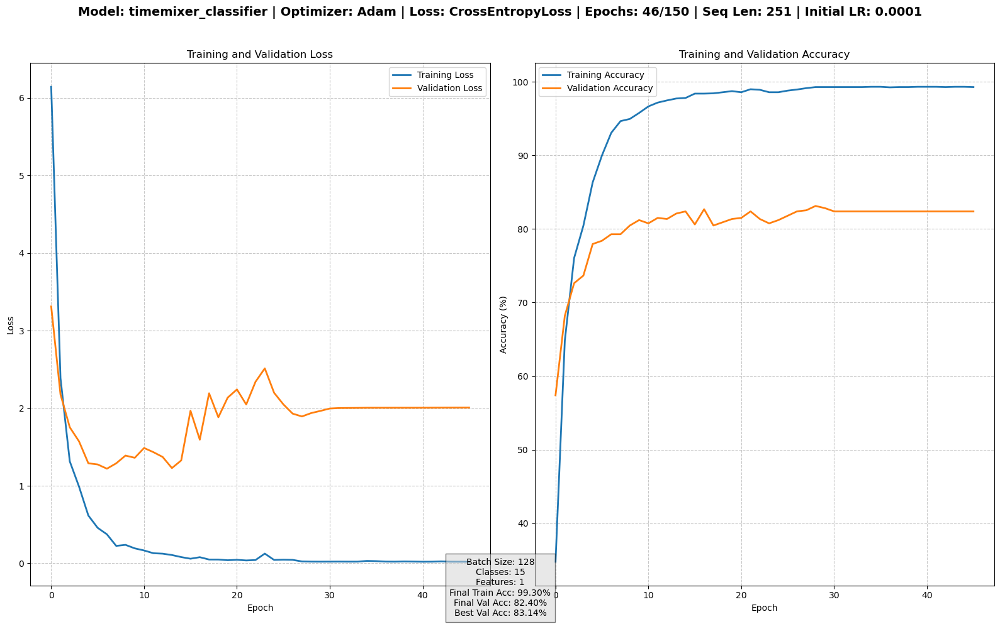

Val Accuracy: 82.40%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_251_confusion_matrix.png


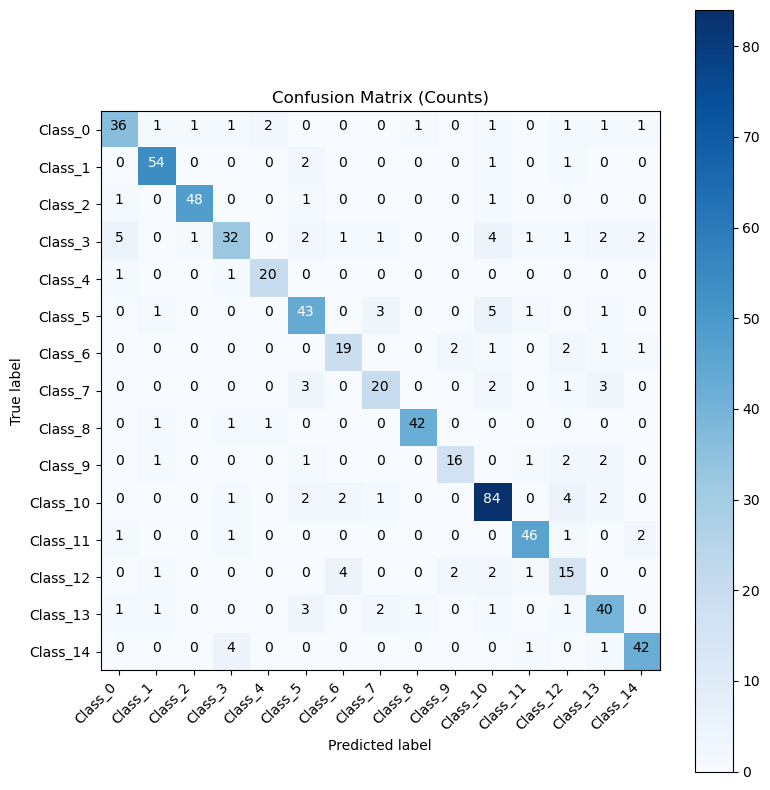

Successfully saved: checkpoints/UTMobile/timemixer_classifier_251_confusion_matrix_percent.png


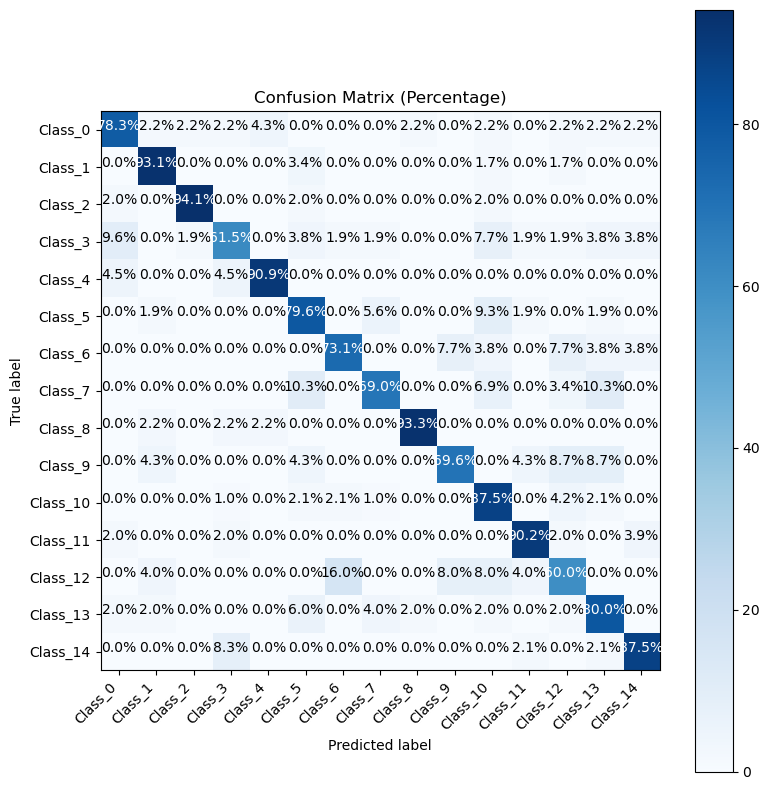


Evaluation Complete!
Total evaluation time: 0:00:00.287040

Processing dataset: 30_5_14classes_167
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:06,  1.25s/it, train_loss=9.1975, train_acc=29.41%, val_loss=4.3784, val_acc=50.00%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 9.1975, Accuracy: 29.41%
Validation Loss: 4.3784, Accuracy: 50.00%
Current LR: 1.00e-04
Epoch time: 0:00:01.251747
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:09,  1.28s/it, train_loss=3.6891, train_acc=57.07%, val_loss=2.7242, val_acc=63.76%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_167_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 3.6891, Accuracy: 57.07%
Validation Loss: 2.7242, Accuracy: 63.76%
Current LR: 1.00e-04
Epoch time: 0:00:01.302846
----------------------------------------


...

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 47/150
Training Loss: 0.0329, Accuracy: 99.30%
Validation Loss: 2.5097, Accuracy: 82.10%
Current LR: 1.00e-07
Epoch time: 0:00:01.368386
----------------------------------------


Training:  32%|███▏      | 48/150 [01:02<02:16,  1.34s/it, train_loss=0.0247, train_acc=99.26%, val_loss=2.5096, val_acc=82.10%, time=0:00:01]

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 48/150
Training Loss: 0.0247, Accuracy: 99.26%
Validation Loss: 2.5096, Accuracy: 82.10%
Current LR: 1.00e-07
Epoch time: 0:00:01.329696
----------------------------------------


Training:  32%|███▏      | 48/150 [01:04<02:16,  1.34s/it, train_loss=0.0247, train_acc=99.26%, val_loss=2.5097, val_acc=82.10%, time=0:00:01]


ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 49/150
Training Loss: 0.0247, Accuracy: 99.26%
Validation Loss: 2.5097, Accuracy: 82.10%
Current LR: 1.00e-07
Epoch time: 0:00:01.303585
----------------------------------------
Early stopping triggered after 49 epochs

Training Complete!
Total training time: 0:01:04.310735

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e49_optAdam_lr0.0001_lossCrossEntropyLoss_seq167_acc82.5.png
Successfully saved metrics plot


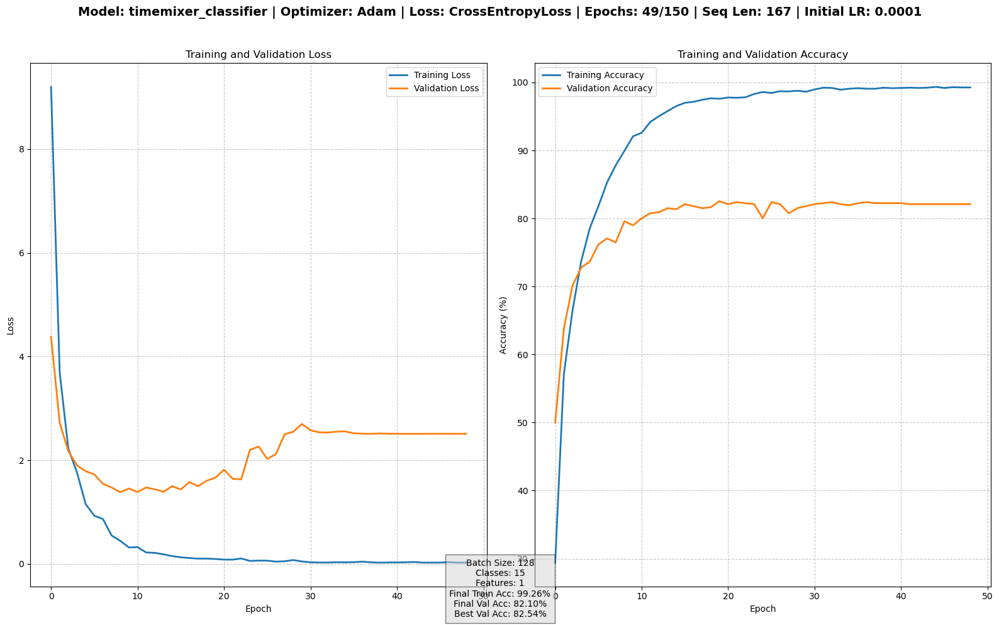

Val Accuracy: 82.10%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_167_confusion_matrix.png


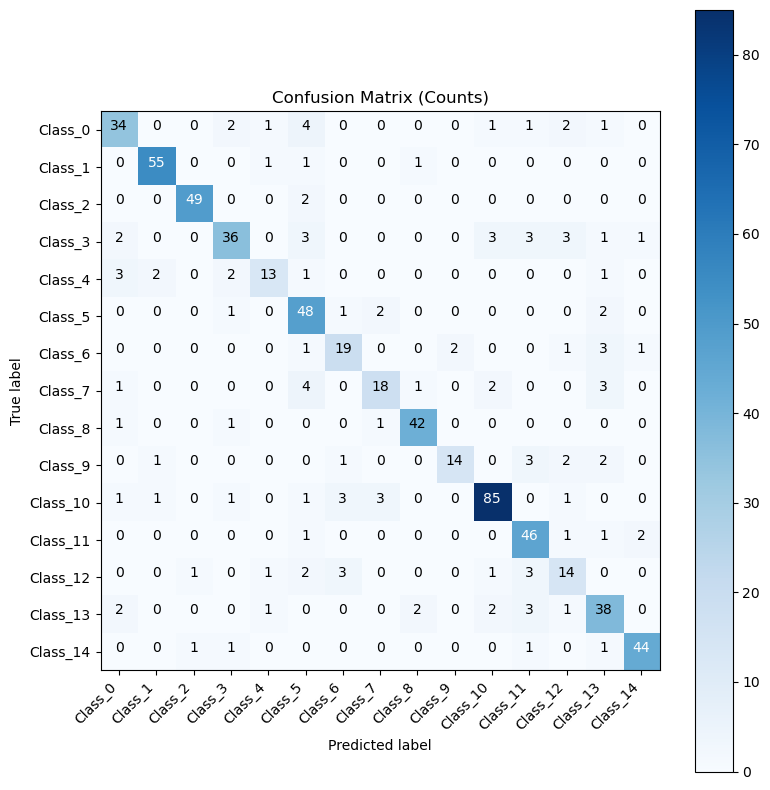

Successfully saved: checkpoints/UTMobile/timemixer_classifier_167_confusion_matrix_percent.png


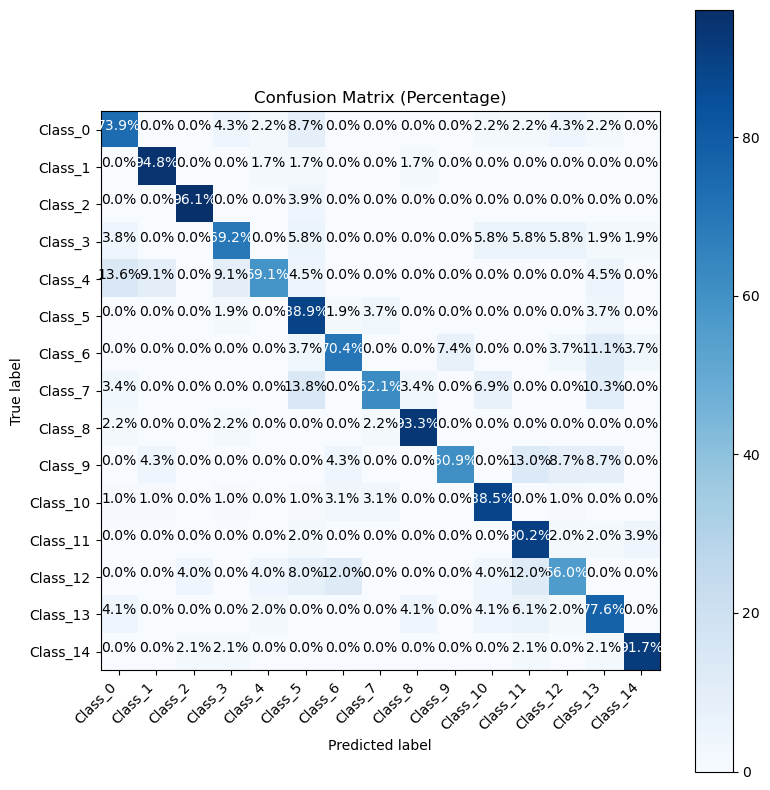


Evaluation Complete!
Total evaluation time: 0:00:00.283187

Processing dataset: 40_5_14classes_126
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:20,  1.35s/it, train_loss=10.3964, train_acc=29.69%, val_loss=5.4726, val_acc=48.37%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 10.3964, Accuracy: 29.69%
Validation Loss: 5.4726, Accuracy: 48.37%
Current LR: 1.00e-04
Epoch time: 0:00:01.345681
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:17,  1.34s/it, train_loss=4.6807, train_acc=53.28%, val_loss=3.6002, val_acc=59.02%, time=0:00:01] 

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_126_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 4.6807, Accuracy: 53.28%
Validation Loss: 3.6002, Accuracy: 59.02%
Current LR: 1.00e-04
Epoch time: 0:00:01.326894
----------------------------------------


...

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 41/150
Training Loss: 0.0406, Accuracy: 98.93%
Validation Loss: 1.7697, Accuracy: 83.73%
Current LR: 1.00e-07
Epoch time: 0:00:01.366145
----------------------------------------


Training:  28%|██▊       | 42/150 [00:55<02:26,  1.35s/it, train_loss=0.0386, train_acc=99.04%, val_loss=1.7698, val_acc=83.73%, time=0:00:01]

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 42/150
Training Loss: 0.0386, Accuracy: 99.04%
Validation Loss: 1.7698, Accuracy: 83.73%
Current LR: 1.00e-07
Epoch time: 0:00:01.363952
----------------------------------------


Training:  28%|██▊       | 42/150 [00:57<02:27,  1.37s/it, train_loss=0.0419, train_acc=98.82%, val_loss=1.7695, val_acc=83.73%, time=0:00:01]


ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 43/150
Training Loss: 0.0419, Accuracy: 98.82%
Validation Loss: 1.7695, Accuracy: 83.73%
Current LR: 1.00e-07
Epoch time: 0:00:01.362078
----------------------------------------
Early stopping triggered after 43 epochs

Training Complete!
Total training time: 0:00:57.365371

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e43_optAdam_lr0.0001_lossCrossEntropyLoss_seq126_acc84.8.png
Successfully saved metrics plot


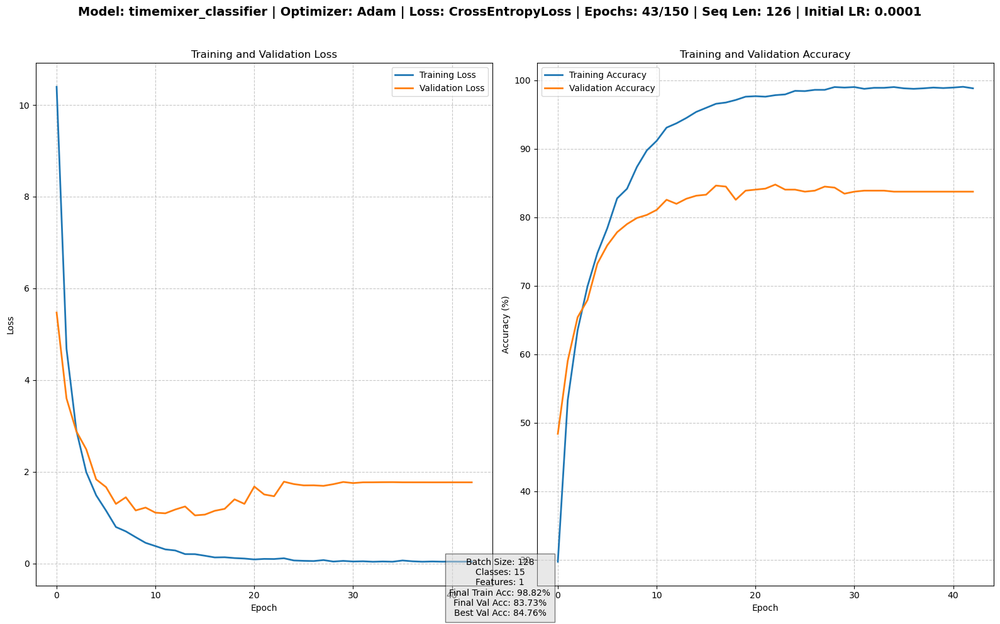

Val Accuracy: 83.73%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_126_confusion_matrix.png


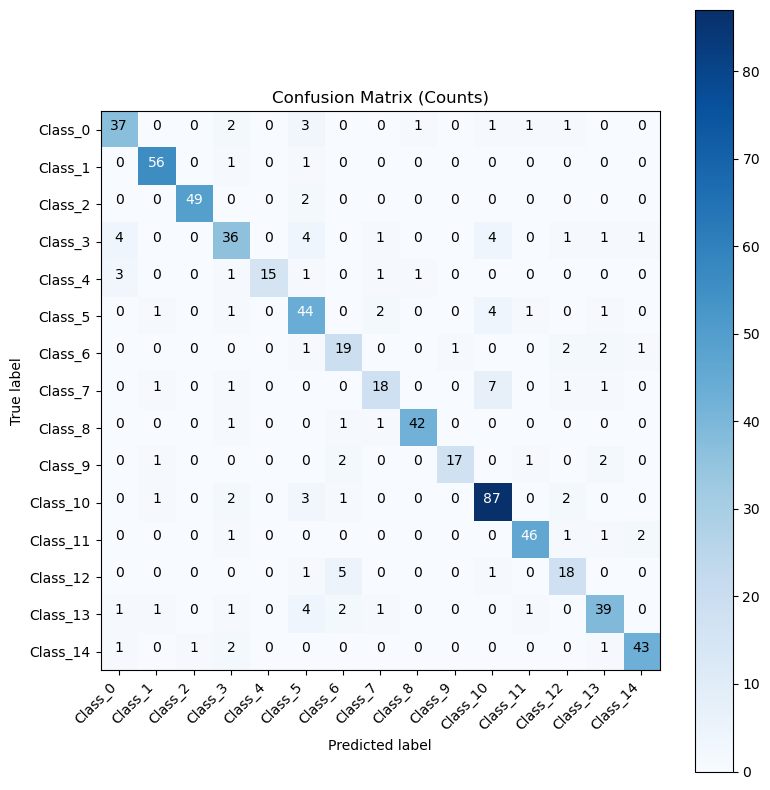

Successfully saved: checkpoints/UTMobile/timemixer_classifier_126_confusion_matrix_percent.png


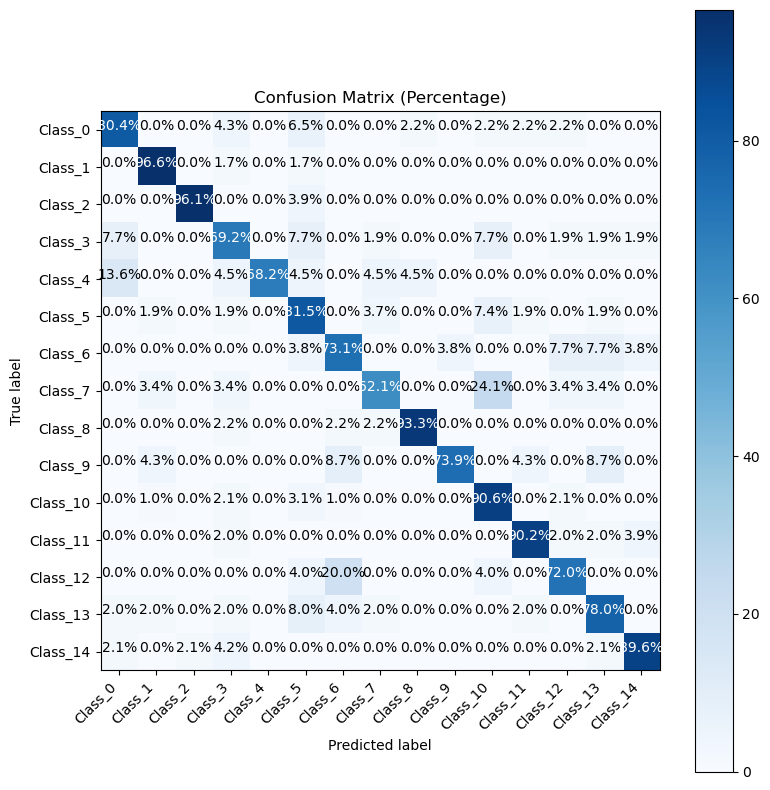


Evaluation Complete!
Total evaluation time: 0:00:00.288482

Processing dataset: 75_5_14classes_67
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:28,  1.40s/it, train_loss=19.4230, train_acc=19.00%, val_loss=8.4354, val_acc=36.24%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 19.4230, Accuracy: 19.00%
Validation Loss: 8.4354, Accuracy: 36.24%
Current LR: 1.00e-04
Epoch time: 0:00:01.395363
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:21,  1.36s/it, train_loss=8.8201, train_acc=43.15%, val_loss=5.0979, val_acc=54.44%, time=0:00:01] 

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_67_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 8.8201, Accuracy: 43.15%
Validation Loss: 5.0979, Accuracy: 54.44%
Current LR: 1.00e-04
Epoch time: 0:00:01.334636
----------------------------------------


...

ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 59/150
Training Loss: 0.0678, Accuracy: 98.37%
Validation Loss: 1.5529, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:01.325640
----------------------------------------


Training:  40%|████      | 60/150 [01:19<01:58,  1.32s/it, train_loss=0.0583, train_acc=98.37%, val_loss=1.5528, val_acc=86.54%, time=0:00:01]

ReduceLROnPlateau counter: 7 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 60/150
Training Loss: 0.0583, Accuracy: 98.37%
Validation Loss: 1.5528, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:01.321160
----------------------------------------


Training:  40%|████      | 60/150 [01:20<02:00,  1.34s/it, train_loss=0.0621, train_acc=98.30%, val_loss=1.5527, val_acc=86.54%, time=0:00:01]


ReduceLROnPlateau counter: 8 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 61/150
Training Loss: 0.0621, Accuracy: 98.30%
Validation Loss: 1.5527, Accuracy: 86.54%
Current LR: 1.00e-07
Epoch time: 0:00:01.298046
----------------------------------------
Early stopping triggered after 61 epochs

Training Complete!
Total training time: 0:01:20.525730

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e61_optAdam_lr0.0001_lossCrossEntropyLoss_seq67_acc86.8.png
Successfully saved metrics plot


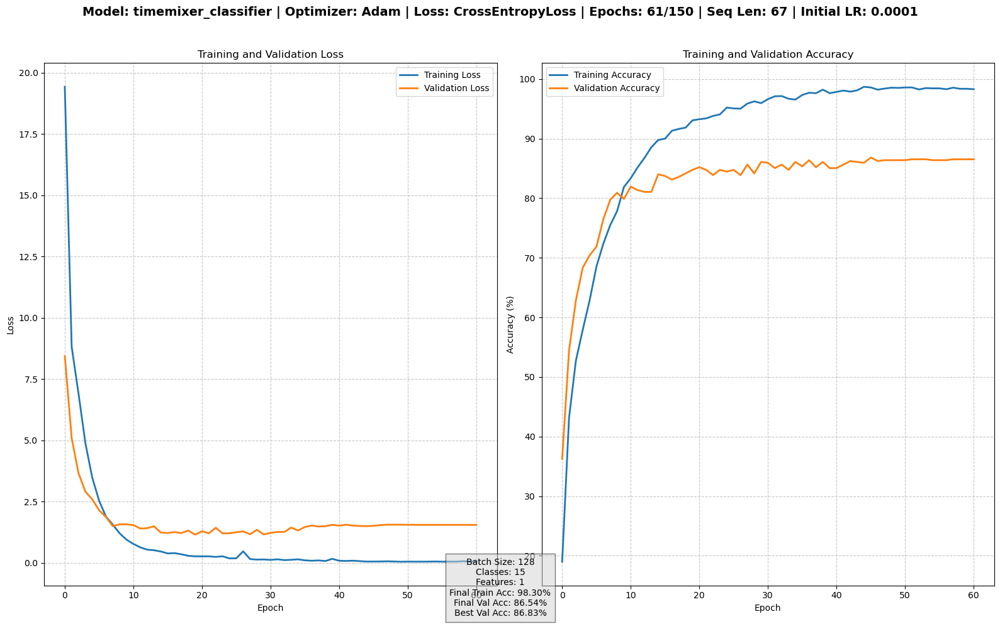

Val Accuracy: 86.39%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_67_confusion_matrix.png


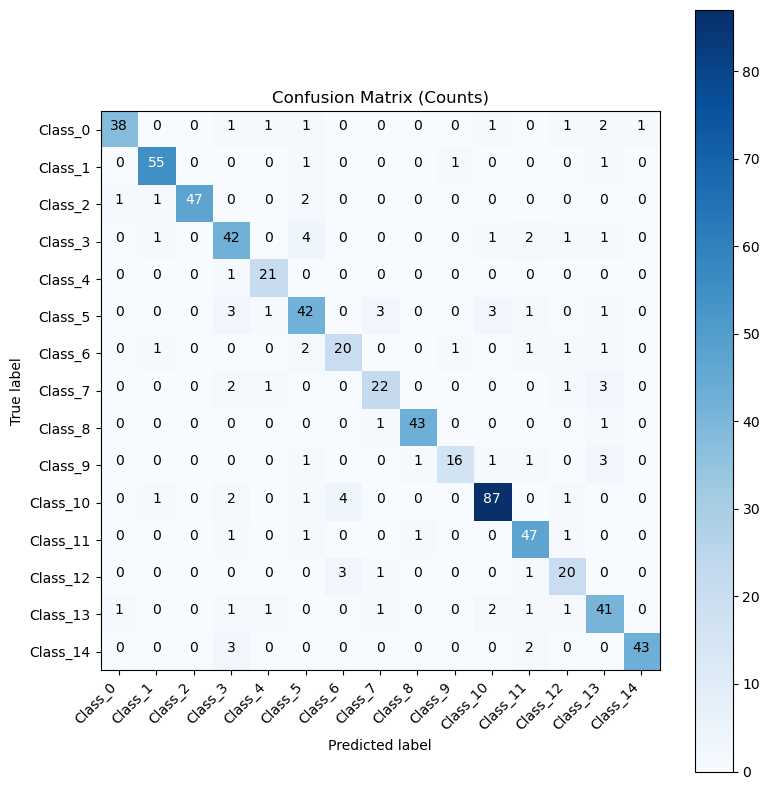

Successfully saved: checkpoints/UTMobile/timemixer_classifier_67_confusion_matrix_percent.png


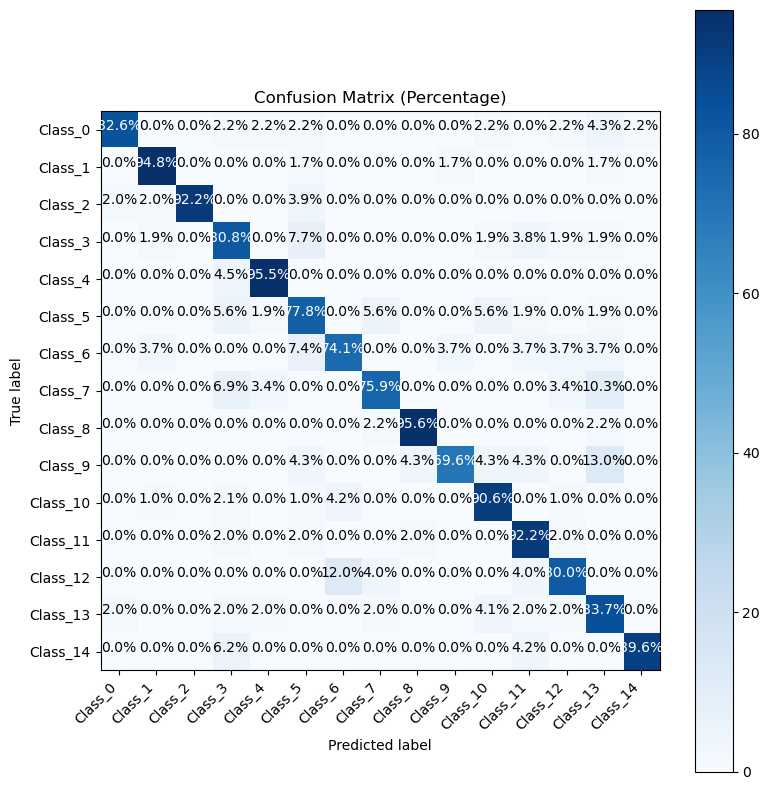


Evaluation Complete!
Total evaluation time: 0:00:00.280082

Processing dataset: 200_5_14classes_26
Using CrossEntropyLoss
Using Adam optimizer


Training:   1%|          | 1/150 [00:01<03:20,  1.35s/it, train_loss=41.5167, train_acc=12.96%, val_loss=17.7140, val_acc=27.37%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 1/150
Training Loss: 41.5167, Accuracy: 12.96%
Validation Loss: 17.7140, Accuracy: 27.37%
Current LR: 1.00e-04
Epoch time: 0:00:01.346980
----------------------------------------


Training:   1%|▏         | 2/150 [00:02<03:23,  1.37s/it, train_loss=18.6434, train_acc=27.14%, val_loss=10.2361, val_acc=40.98%, time=0:00:01]

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/UTMobile/timemixer_classifier_26_best.pth
Successfully saved checkpoint
Epoch 2/150
Training Loss: 18.6434, Accuracy: 27.14%
Validation Loss: 10.2361, Accuracy: 40.98%
Current LR: 1.00e-04
Epoch time: 0:00:01.388135
----------------------------------------


...

ReduceLROnPlateau counter: 4 out of 3
EarlyStopping counter: 3 out of 5 (LR at minimum: 1.00e-07)
Epoch 56/150
Training Loss: 0.2979, Accuracy: 92.37%
Validation Loss: 0.8661, Accuracy: 87.43%
Current LR: 1.00e-07
Epoch time: 0:00:01.302467
----------------------------------------


Training:  38%|███▊      | 57/150 [01:17<02:04,  1.34s/it, train_loss=0.3151, train_acc=92.15%, val_loss=0.8660, val_acc=87.43%, time=0:00:01]

ReduceLROnPlateau counter: 5 out of 3
EarlyStopping counter: 4 out of 5 (LR at minimum: 1.00e-07)
Epoch 57/150
Training Loss: 0.3151, Accuracy: 92.15%
Validation Loss: 0.8660, Accuracy: 87.43%
Current LR: 1.00e-07
Epoch time: 0:00:01.363386
----------------------------------------


Training:  38%|███▊      | 57/150 [01:18<02:08,  1.38s/it, train_loss=0.2838, train_acc=91.82%, val_loss=0.8660, val_acc=87.43%, time=0:00:01]


ReduceLROnPlateau counter: 6 out of 3
EarlyStopping counter: 5 out of 5 (LR at minimum: 1.00e-07)
Restoring model to best weights
Epoch 58/150
Training Loss: 0.2838, Accuracy: 91.82%
Validation Loss: 0.8660, Accuracy: 87.43%
Current LR: 1.00e-07
Epoch time: 0:00:01.382093
----------------------------------------
Early stopping triggered after 58 epochs

Training Complete!
Total training time: 0:01:18.630059

Plotting Training Metrics...
Saving metrics plot to: checkpoints/UTMobile/timemixer_classifier_e58_optAdam_lr0.0001_lossCrossEntropyLoss_seq26_acc88.0.png
Successfully saved metrics plot


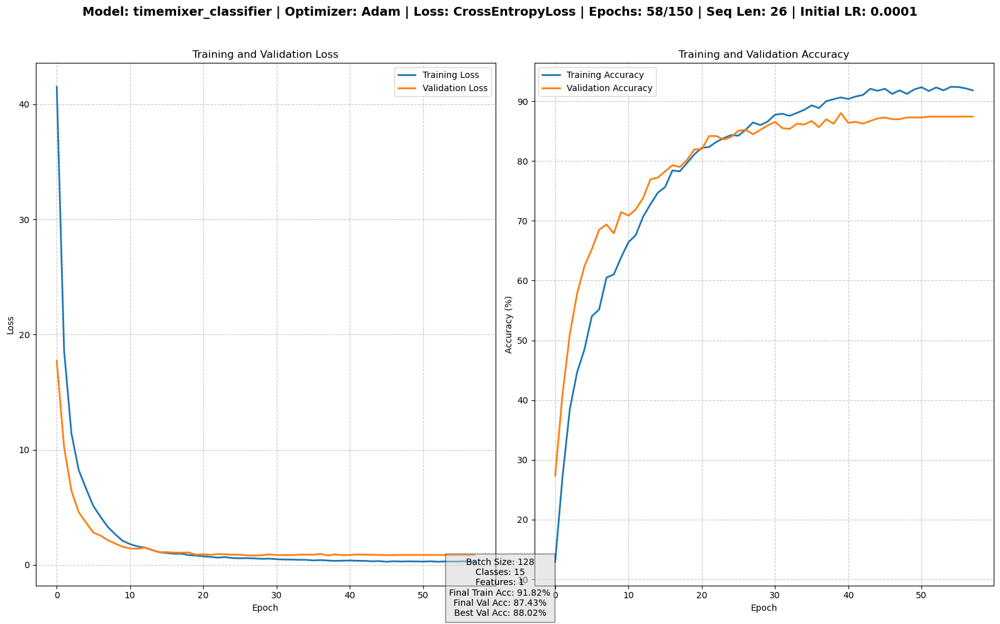

Val Accuracy: 87.43%

Creating confusion matrices...
Successfully saved: checkpoints/UTMobile/timemixer_classifier_26_confusion_matrix.png


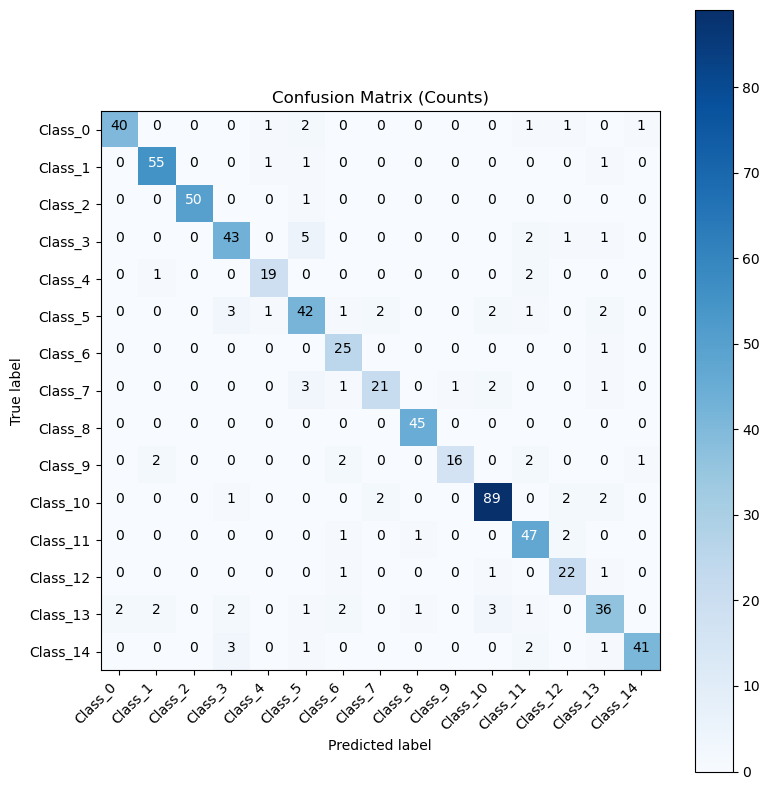

Successfully saved: checkpoints/UTMobile/timemixer_classifier_26_confusion_matrix_percent.png


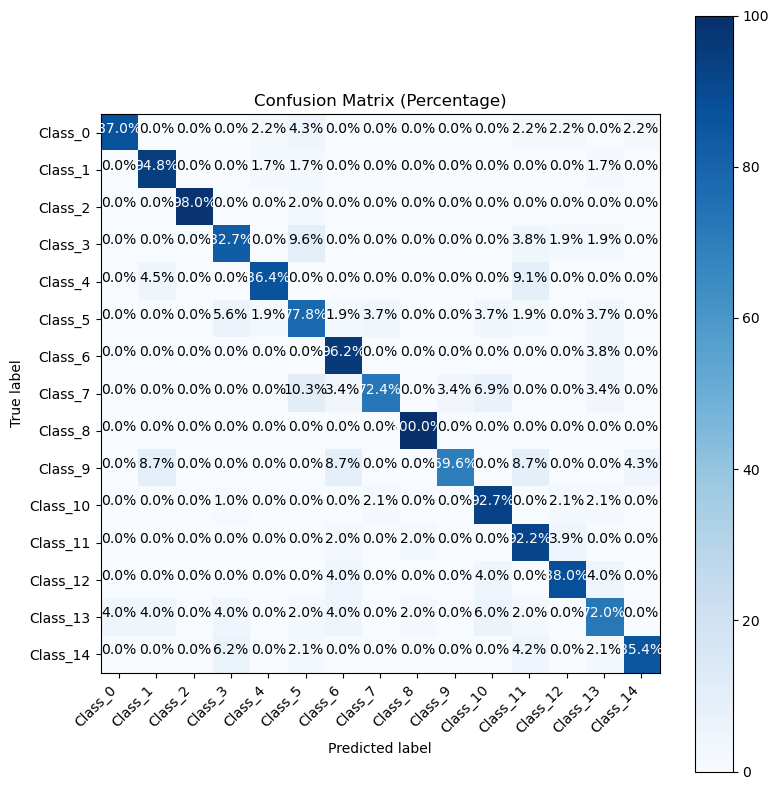


Evaluation Complete!
Total evaluation time: 0:00:00.285052

Results saved to:
Detailed: results/UTMobile/UTMobile_model_Adam_optimizer_CrossEntropyLoss_comparison_detailed_for_packet_amount_20250406_175135.csv


In [20]:
model_types=['nst','informer','timesnet','autoformer','fedformer','timemixer']
# model_types=['nst']
# model_types=['informer','timesnet']
# model_types=['autoformer']
results = evaluate_models_on_datasets(datasets_dict=datasets_dict,
                                      model_types=model_types,
                                      use_class_weights=False)